# 0. Contexto del proyecto
- **Objetivo:** Clasificación multiclase de las etapas del sueño (`Sleep_Stage`: W, N1, N2, N3, R) a partir de señales fisiológicas de Polisomnografía (PSG) y del wearable Empatica E4.
- **Frecuencia de muestreo:** 100 Hz (mediciones cada 10 ms). Un epoch estándar equivale a 30 segundos (3000 muestras).
- **Formato de archivos:** Archivos individuales por paciente con nomenclatura `SXXX_PSG_df.csv` (ej. `S005_PSG_df.csv`, donde `005` es el ID del participante).
- **Esquema de columnas (32 variables):**
  - *Temporal:* `TIMESTAMP`
  - *EEG / EOG / EMG / ECG (PSG):* `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4`, `CHIN`, `E1`, `E2`, `ECG`, `LAT`, `RAT`
  - *Respiratorias y Oximetría (PSG):* `SNORE`, `PTAF`, `FLOW`, `THORAX`, `ABDOMEN`, `SAO2`
  - *Wearable (Empatica E4):* `BVP`, `ACC_X`, `ACC_Y`, `ACC_Z`, `TEMP`, `EDA`, `HR`, `IBI`
  - *Eventos Clínicos (Apneas):* `Obstructive_Apnea`, `Central_Apnea`, `Hypopnea`, `Multiple_Events`
  - *Target:* `Sleep_Stage`
- **Fuente:** DREAMT 2.2.0, disponible en PhysioNet. La cantidad de archivos de pacientes depende de los datos disponibles en el entorno de ejecución.
- **Anotaciones:** las etapas de sueño fueron anotadas por especialistas cada 30 segundos. Las anotaciones de apnea se conservan en el origen, pero no se incluyen como predictores.

## 0.1. Librerías y configuración
Todas las importaciones se reúnen aquí para evitar repeticiones en las secciones siguientes.

In [95]:
import os
import json
import re
import gc
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Configuración inicial de visualización y advertencias
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Carga de datos
Se localizan los CSV y se carga un paciente completo para el análisis exploratorio. El procesamiento de varios pacientes se configura por separado en la sección 3.1.

In [96]:
# 1.1. Detección automática de entorno y listado de archivos
def get_dataset_files(local_data_dir: str = "./data") -> list[Path]:
    """
    Detecta el entorno de ejecución (Kaggle vs Local) y localiza recursivamente
    todos los archivos que coincidan con 'S*_PSG_df.csv'.
    """
    is_kaggle = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle/input').exists()
    
    if is_kaggle:
        print("[Entorno detectado] Kaggle Kernel")
        search_root = Path('/kaggle/input')
        files = sorted(list(search_root.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    else:
        print("[Entorno detectado] Entorno Local")
        local_path = Path(local_data_dir)
        if not local_path.exists():
            local_path = Path(".")
        files = sorted(list(local_path.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    
    print(f"Total archivos PSG encontrados: {len(files)}")
    return files

def extract_patient_id(file_path: Path | str) -> int:
    """
    Extrae el identificador numérico de paciente desde el nombre de archivo (ej. 'S005_PSG_df.csv' -> 5).
    """
    filename = Path(file_path).name
    match = re.search(r'S(\d+)_PSG_df\.csv', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    digits = re.search(r'\d+', filename)
    return int(digits.group(0)) if digits else -1

data_files = get_dataset_files()
if data_files:
    print("Ejemplo de archivos detectados:", [f.name for f in data_files[:5]])

# Función temporal compartida por el EDA y el ETL.
def definir_epochs(df):
    """
    Identifica la alineación a partir de cambios entre etapas válidas.
    Conserva los fragmentos incompletos, marcándolos por separado.
    No modifica el DataFrame recibido.
    """
    columnas_requeridas = {"TIMESTAMP", "Sleep_Stage"}
    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

    if len(df) < 3000:
        raise ValueError("El registro contiene menos de 30 segundos.")

    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce")

    if not np.isfinite(tiempos).all():
        raise ValueError("Hay timestamps faltantes o inválidos.")

    diferencias = tiempos.diff().iloc[1:]
    if not np.isclose(
        diferencias, 0.01, atol=1e-6, rtol=0
    ).all():
        raise ValueError("El registro no es continuo a 100 Hz.")

    etapas = df["Sleep_Stage"]
    anterior = etapas.shift()
    validas = {"W", "N1", "N2", "N3", "R"}

    cambios = (
        etapas.isin(validas)
        & anterior.isin(validas)
        & etapas.ne(anterior)
    )

    posiciones = np.flatnonzero(cambios.to_numpy())
    restos = np.unique(posiciones % 3000)

    if len(restos) == 0:
        raise ValueError(
            "Sin cambios entre etapas válidas: alineación no determinada."
        )

    if len(restos) > 1:
        raise ValueError(
            f"Alineación inconsistente: desplazamientos {restos.tolist()}."
        )

    desplazamiento = int(restos[0])
    cantidad_completos = (len(df) - desplazamiento) // 3000

    epoch = (np.arange(len(df)) - desplazamiento) // 3000
    completo = (epoch >= 0) & (epoch < cantidad_completos)

    resumen = {
        "filas_originales": len(df),
        "desplazamiento": desplazamiento,
        "epochs_completos": cantidad_completos,
        "filas_fragmento_inicial": desplazamiento,
        "filas_fragmento_final":
            (len(df) - desplazamiento) % 3000
    }

    return epoch, completo, resumen

[Entorno detectado] Entorno Local
Total archivos PSG encontrados: 18
Ejemplo de archivos detectados: ['S002_PSG_df.csv', 'S003_PSG_df.csv', 'S004_PSG_df.csv', 'S005_PSG_df.csv', 'S006_PSG_df.csv']


In [97]:
# 1.2. Carga de muestra a 100 Hz (sin reducción) para EDA
if len(data_files) > 0:
    sample_file = data_files[0]
    
    # Extraer el ID entero del archivo (ej. 'S005_PSG_df.csv' -> 5)
    patient_id_int = extract_patient_id(sample_file)
    
    print(f"Cargando archivo de muestra: {sample_file.name} (Patient ID: {patient_id_int})")
    
    # Cargar archivo completo a 100 Hz
    df_sample_eda = pd.read_csv(sample_file)
    
    # Agregar el patient_id como primera columna
    if 'patient_id' not in df_sample_eda.columns:
        df_sample_eda.insert(0, 'patient_id', patient_id_int)
    
    print(f"Muestra cargada exitosamente: {df_sample_eda.shape[0]} filas, {df_sample_eda.shape[1]} columnas.")
else:
    print("No se encontraron archivos .csv para cargar.")

Cargando archivo de muestra: S002_PSG_df.csv (Patient ID: 2)
Muestra cargada exitosamente: 1958400 filas, 33 columnas.


# 2. Análisis de datos Exploratorio
En esta sección realizaremos el EDA sobre el DataFrame de muestra de un único paciente (`df_sample_eda`, muestreado a 100 Hz).

### Guía rápida de variables originales

Esta tabla identifica qué mide cada columna del CSV antes de interpretar sus distribuciones. **Señal medida** no equivale a **predictor aprobado**: `Sleep_Stage` es el objetivo y las apneas son anotaciones clínicas, no magnitudes continuas.

| Origen | Variable | Significado |
| :--- | :--- | :--- |
| Registro | `TIMESTAMP` | Tiempo transcurrido desde el inicio del registro, en segundos; fue desplazado para preservar privacidad. |
| PSG: EEG | `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4` | Actividad eléctrica cerebral entre los electrodos indicados. F: frontal; C: central; O: occipital; Fp: frontopolar; T: temporal. El guion identifica una derivación, no una operación del ETL. |
| PSG: ojos | `E1`, `E2` | Movimientos oculares (EOG); útiles para reconocer REM. |
| PSG: músculos | `CHIN` | Actividad muscular del mentón (EMG); informa sobre el tono muscular. |
| PSG: corazón | `ECG` | Actividad eléctrica cardíaca; es distinta de la frecuencia cardíaca `HR`. |
| PSG: piernas | `LAT`, `RAT` | Actividad muscular de las piernas izquierda y derecha, respectivamente. |
| PSG: respiración | `SNORE` | Señal de ronquido. |
| PSG: respiración | `PTAF`, `FLOW` | Flujo de aire estimado con sensores de presión y temperatura, respectivamente. |
| PSG: respiración | `THORAX`, `ABDOMEN` | Esfuerzo respiratorio medido en tórax y abdomen; no son los acelerómetros de muñeca. |
| PSG: oximetría | `SAO2` | Saturación de oxígeno. **Confirmar escala del CSV** antes de convertir o fijar rangos: los gráficos muestran valores cercanos a 0,9, mientras la documentación la expresa como porcentaje. |
| Wearable: pulso | `BVP` | Onda óptica de pulso sanguíneo (PPG); no es `HR`. |
| Wearable: movimiento | `ACC_X`, `ACC_Y`, `ACC_Z` | Aceleración de la muñeca en tres ejes. |
| Wearable: piel | `TEMP` | Temperatura de la piel; no temperatura corporal central. |
| Wearable: piel | `EDA` | Actividad electrodérmica o conductancia de la piel. |
| Wearable: derivada | `HR` | Frecuencia cardíaca estimada a partir de `BVP`. |
| Wearable: derivada | `IBI` | Intervalo entre latidos estimado a partir de `BVP`. Confirmar la unidad efectiva antes de aplicar umbrales. |
| Etiqueta | `Sleep_Stage` | Etapa anotada mediante PSG cada 30 segundos: `W`, `N1`, `N2`, `N3` o `R`. **Variable objetivo**. |
| Evento clínico | `Obstructive_Apnea` | Indicador de apnea obstructiva; anotación de evento, no intensidad de apnea. |
| Evento clínico | `Central_Apnea` | Indicador de apnea central; anotación de evento, no intensidad de apnea. |
| Evento clínico | `Hypopnea` | Indicador de reducción parcial de la respiración. |
| Evento clínico | `Multiple_Events` | Indicador de eventos respiratorios múltiples; confirmar la combinación exacta en `Metadata.txt`. No interpretarlo como conteo. |

Fuente para las familias de señales, las etiquetas y el muestreo: [DREAMT 2.2.0, PhysioNet](https://physionet.org/content/dreamt/2.2.0/). Los nombres de electrodos se interpretan según la nomenclatura EEG; la documentación resumida no detalla `Fp1-O2`, por lo que conviene contrastarlo con los metadatos del archivo utilizado.


## 2.1 Dimensiones y Tipos de Datos

In [98]:
# 2.1. Dimensiones y tipos de datos de hasta tres pacientes

sns.set_theme(style="whitegrid")

# Conservar variables utilizadas en las siguientes secciones.
patient_id = df_sample_eda["patient_id"].iloc[0]
total_filas = len(df_sample_eda)
total_columnas = df_sample_eda.shape[1]

pacientes_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_eda = [
    nombre for nombre in pacientes_preferidos
    if nombre in nombres_disponibles
]
nombres_eda += [
    p.name for p in data_files if p.name not in nombres_eda
][:max(0, 3 - len(nombres_eda))]

print("Pacientes elegidos para la muestra exploratoria:", nombres_eda)

resumen_estructura = []
tipos_por_archivo = {}
columnas_por_archivo = {}

for nombre in nombres_eda:
    coincidencias = [p for p in data_files if p.name == nombre]

    if len(coincidencias) != 1:
        raise ValueError(
            f"{nombre}: se esperaba un archivo; "
            f"se encontraron {len(coincidencias)}."
        )

    ruta = coincidencias[0]
    print(f"Revisando estructura: {nombre}")

    # Columnas originales del CSV; no incluye patient_id agregado.
    columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
    columnas_por_archivo[nombre] = columnas

    tipos_observados = {col: set() for col in columnas}
    filas = 0

    # Reutilizar el paciente ya cargado cuando corresponda.
    if ruta == sample_file:
        filas = len(df_sample_eda)

        for col in columnas:
            tipos_observados[col].add(str(df_sample_eda[col].dtype))

    else:
        # Recorrer el registro completo sin conservar todos los bloques.
        with pd.read_csv(
            ruta, chunksize=200_000, low_memory=False
        ) as lector:
            for bloque in lector:
                filas += len(bloque)

                for col in columnas:
                    tipos_observados[col].add(str(bloque[col].dtype))

    tipos_por_archivo[nombre] = {
        col: " / ".join(sorted(tipos))
        for col, tipos in tipos_observados.items()
    }

    resumen_estructura.append({
        "archivo": nombre,
        "patient_id": extract_patient_id(ruta),
        "filas": filas,
        "columnas_csv": len(columnas),
        # Duración equivalente suponiendo continuidad a 100 Hz.
        "duracion_equivalente_horas": filas / (100 * 3600),
    })

# Comparación de dimensiones.
resumen_estructura = pd.DataFrame(resumen_estructura)

print("\nDIMENSIONES DE LOS REGISTROS COMPLETOS")
display(resumen_estructura.round({"duracion_equivalente_horas": 3}))

# Comparación de tipos inferidos por pandas.
comparacion_tipos = pd.DataFrame(tipos_por_archivo)
comparacion_tipos.index.name = "columna"

print("\nTIPOS OBSERVADOS POR COLUMNA")
display(comparacion_tipos)

# Comparación de nombres de columnas contra el primer archivo.
referencia = nombres_eda[0]
columnas_referencia = set(columnas_por_archivo[referencia])

print(f"\nCOMPARACIÓN DE COLUMNAS CONTRA {referencia}")

for nombre in nombres_eda[1:]:
    columnas_actuales = set(columnas_por_archivo[nombre])

    faltantes = sorted(columnas_referencia - columnas_actuales)
    adicionales = sorted(columnas_actuales - columnas_referencia)

    print(f"\n{nombre}")
    print("Columnas faltantes:", faltantes or "Ninguna")
    print("Columnas adicionales:", adicionales or "Ninguna")

# Señalar diferencias de tipos para revisión, sin corregirlas.
diferencias_tipos = comparacion_tipos.loc[
    comparacion_tipos.nunique(axis=1, dropna=False) > 1
]

print("\nDIFERENCIAS DE TIPOS ENTRE PACIENTES")

if diferencias_tipos.empty:
    print("No se observaron diferencias.")
else:
    display(diferencias_tipos)

print(
    "\nNota: diferencias como int64/float64 u object/float64 "
    "requieren interpretación; no demuestran por sí solas un error. "
    "Una columna de anotaciones completamente nula puede inferirse "
    "como float64, mientras otra con texto se infiere como object."
)

Pacientes elegidos para la muestra exploratoria: ['S002_PSG_df.csv', 'S004_PSG_df.csv', 'S006_PSG_df.csv']
Revisando estructura: S002_PSG_df.csv
Revisando estructura: S004_PSG_df.csv
Revisando estructura: S006_PSG_df.csv

DIMENSIONES DE LOS REGISTROS COMPLETOS


,archivo,patient_id,filas,columnas_csv,duracion_equivalente_horas
0,S002_PSG_df.csv,2,1958400,32,5.440
1,S004_PSG_df.csv,4,2413100,32,6.703
2,S006_PSG_df.csv,6,2403000,32,6.675



TIPOS OBSERVADOS POR COLUMNA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
columna,,,
TIMESTAMP,float64,float64,float64
C4-M1,float64,float64,float64
F4-M1,float64,float64,float64
O2-M1,float64,float64,float64
Fp1-O2,float64,float64,float64
T3 - CZ,float64,float64,float64
CZ - T4,float64,float64,float64
CHIN,float64,float64,float64
E1,float64,float64,float64



COMPARACIÓN DE COLUMNAS CONTRA S002_PSG_df.csv

S004_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

S006_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

DIFERENCIAS DE TIPOS ENTRE PACIENTES
No se observaron diferencias.

Nota: diferencias como int64/float64 u object/float64 requieren interpretación; no demuestran por sí solas un error. Una columna de anotaciones completamente nula puede inferirse como float64, mientras otra con texto se infiere como object.


## 2.2 Análisis de Variables Categóricas

In [99]:
# 2.2. Revisión de etiquetas de sueño en la muestra exploratoria

etapas_validas = ["W", "N1", "N2", "N3", "R"]

conteos_por_paciente = {}
resumen_etiquetas = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando etiquetas: {nombre}")

    conteos = pd.Series(dtype="int64")
    total = 0
    nulas = 0
    invalidas = 0
    valores_invalidos = set()

    # Reutilizar el paciente muestra; para los demás, leer solo el target.
    if ruta == sample_file:
        bloques = [df_sample_eda[["Sleep_Stage"]]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=["Sleep_Stage"],
            chunksize=200_000
        )

    for bloque in bloques:
        etiquetas = bloque["Sleep_Stage"]
        total += len(etiquetas)
        nulas += int(etiquetas.isna().sum())

        mascara_invalida = (
            etiquetas.notna()
            & ~etiquetas.isin(etapas_validas)
        )
        invalidas += int(mascara_invalida.sum())
        valores_invalidos.update(
            etiquetas.loc[mascara_invalida].astype(str).unique()
        )

        conteos = conteos.add(
            etiquetas.value_counts(dropna=True),
            fill_value=0
        ).astype("int64")

    conteos_por_paciente[nombre] = (
        conteos.reindex(etapas_validas, fill_value=0)
    )

    resumen_etiquetas.append({
        "archivo": nombre,
        "muestras": total,
        "etiquetas_nulas": nulas,
        "etiquetas_invalidas": invalidas,
        "valores_invalidos": sorted(valores_invalidos),
    })

# Frecuencias de las cinco etapas válidas.
frecuencias_etapas = pd.DataFrame(conteos_por_paciente)
frecuencias_etapas.index.name = "Sleep_Stage"

# Porcentaje respecto a todas las muestras de cada paciente.
resumen_etiquetas = pd.DataFrame(resumen_etiquetas)
totales = resumen_etiquetas.set_index("archivo")["muestras"]

porcentajes_etapas = (
    frecuencias_etapas.div(totales, axis="columns") * 100
)

print("\nCANTIDAD DE MUESTRAS POR ETAPA")
display(frecuencias_etapas)

print("\nPORCENTAJE DE MUESTRAS POR ETAPA")
display(porcentajes_etapas.round(2))

print("\nCONTROL DE ETIQUETAS")
display(resumen_etiquetas)

print(
    "\nNo se modificaron etiquetas. "
    "Los porcentajes pueden sumar menos de 100 % "
    "si existen etiquetas nulas o inválidas."
)

Revisando etiquetas: S002_PSG_df.csv
Revisando etiquetas: S004_PSG_df.csv
Revisando etiquetas: S006_PSG_df.csv

CANTIDAD DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,524400,649100,630000
N1,192000,489000,369000
N2,1002000,1272000,870000
N3,0,3000,534000
R,240000,0,0



PORCENTAJE DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,26.78,26.90,26.22
N1,9.80,20.26,15.36
N2,51.16,52.71,36.20
N3,0.00,0.12,22.22
R,12.25,0.00,0.00



CONTROL DE ETIQUETAS


,archivo,muestras,etiquetas_nulas,etiquetas_invalidas,valores_invalidos
0,S002_PSG_df.csv,1958400,0,0,[]
1,S004_PSG_df.csv,2413100,0,0,[]
2,S006_PSG_df.csv,2403000,0,0,[]



No se modificaron etiquetas. Los porcentajes pueden sumar menos de 100 % si existen etiquetas nulas o inválidas.


### 2.2.1. Frecuencia de las etapas

`Sleep_Stage` es categórica. Su distribución se describe con **frecuencias y porcentajes**, no con formas normal, uniforme o exponencial; esas formas corresponden a variables numéricas. Se comparan los tres pacientes de la muestra exploratoria y luego su conjunto. El gráfico conjunto pondera más a quien tiene más muestras. Las etiquetas nulas o inválidas ya se informan arriba y no aparecen como una etapa válida.


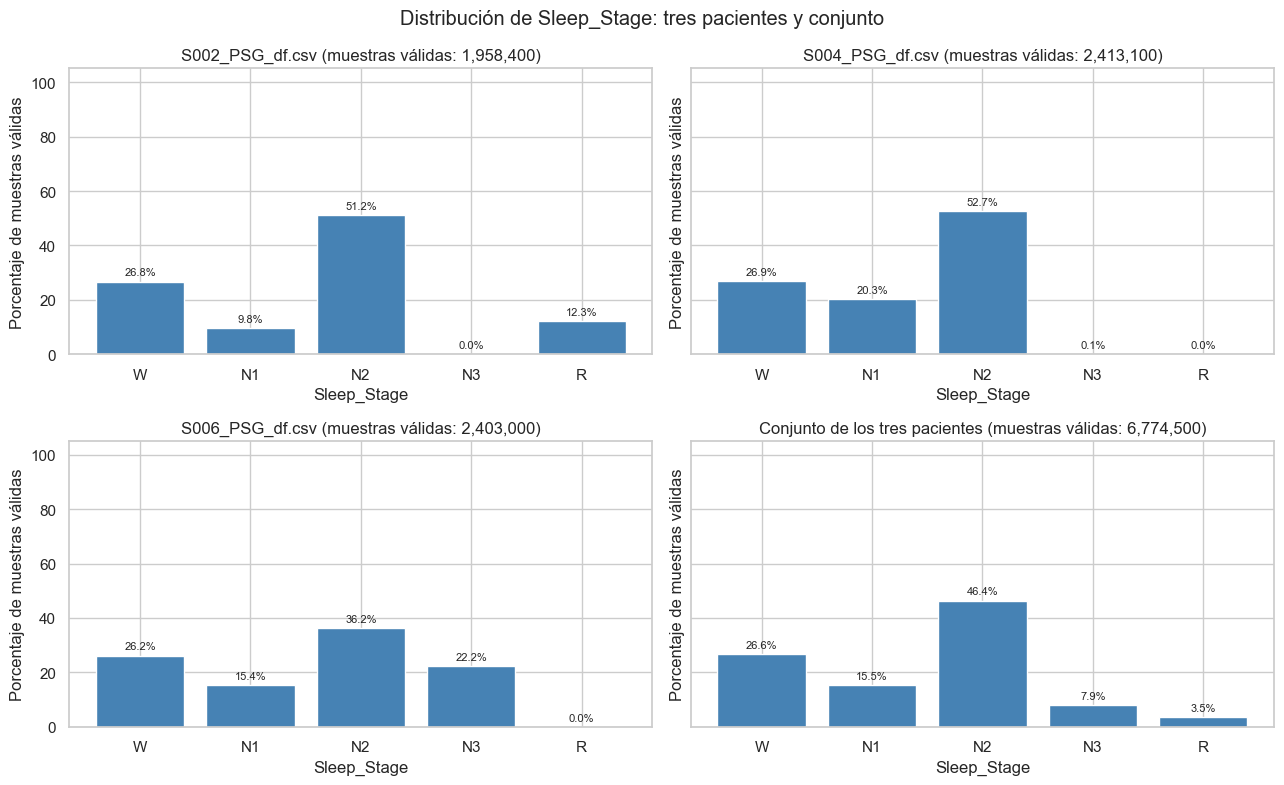

In [100]:
# Proporción de etapas válidas por paciente y en los tres registros juntos.
series_distribucion = [
    (nombre, frecuencias_etapas[nombre]) for nombre in nombres_eda
]
series_distribucion.append((
    "Conjunto de los tres pacientes",
    frecuencias_etapas.sum(axis=1),
))

fig, ejes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for eje, (titulo, conteos) in zip(ejes.flat, series_distribucion):
    conteos = conteos.reindex(etapas_validas, fill_value=0)
    total_validas = int(conteos.sum())
    porcentajes = (
        conteos / total_validas * 100
        if total_validas else conteos.astype(float)
    )
    barras = eje.bar(etapas_validas, porcentajes, color="steelblue")
    eje.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=8)
    eje.set_title(f"{titulo} (muestras válidas: {total_validas:,})")
    eje.set_xlabel("Sleep_Stage")
    eje.set_ylabel("Porcentaje de muestras válidas")
    eje.set_ylim(0, 105)

for eje in list(ejes.flat)[len(series_distribucion):]:
    eje.axis("off")

fig.suptitle("Distribución de Sleep_Stage: tres pacientes y conjunto")
plt.tight_layout()
plt.show()


### 2.2.2. Señales frente a Sleep_Stage

Cada observación resume un epoch completo de 30 segundos con una sola etapa válida. Se muestra **una figura por señal y un panel por paciente**, con la misma escala vertical dentro de cada figura; así no se superponen cajas de personas diferentes. Los puntos atípicos se ocultan solo en estos gráficos para leer mejor el centro: la tabla inferior conserva mínimo, máximo y recuento de atípicos por paciente y etapa. No se eliminan datos.

- BVP_std: dispersión de amplitud de la señal óptica del pulso; también puede subir por movimiento o contacto del sensor. No equivale a variabilidad de frecuencia cardíaca.
- E1_std y E2_std: dispersión de los canales de movimientos oculares del PSG; la diferencia entre etapas es una hipótesis descriptiva, no una prueba de REM.
- SNORE_std: variación de la señal de ronquido; también puede reflejar ruido o escala del canal.
- TEMP_mean: temperatura media del wearable en el epoch, una señal más lenta; las diferencias entre personas o momentos de la noche pueden dominar la comparación por etapa.

La línea de cada caja es la mediana, la caja abarca el 50 % central y los bigotes llegan hasta observaciones dentro de 1,5 × IQR. No representan necesariamente el mínimo y el máximo. Las cajas son exploratorias: se requiere controlar cantidad de epochs, pacientes y calidad de señal antes de atribuirles utilidad predictiva.


S002_PSG_df.csv: 652 epochs completos con etapa válida
S004_PSG_df.csv: 804 epochs completos con etapa válida
S006_PSG_df.csv: 801 epochs completos con etapa válida


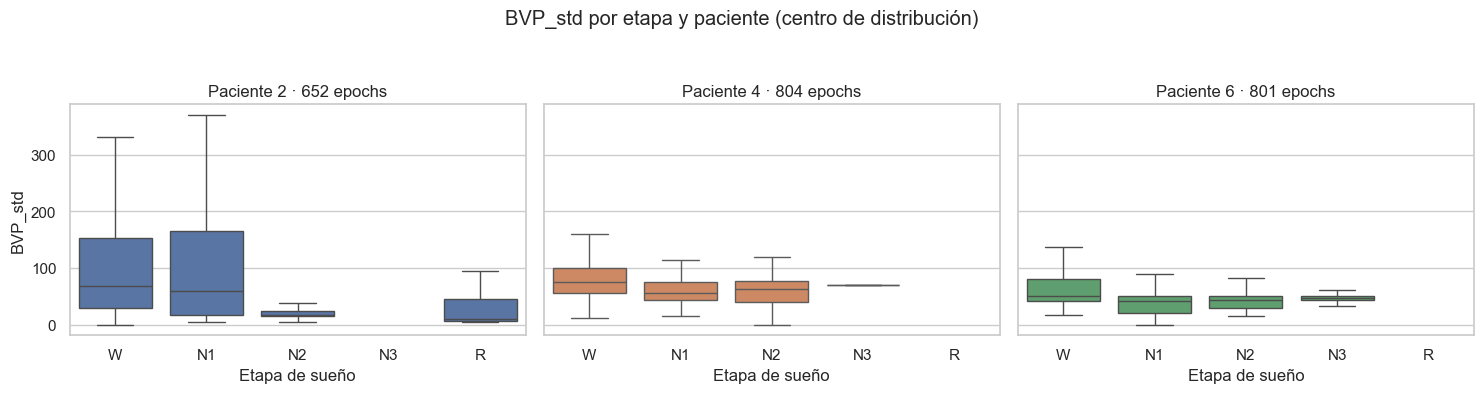

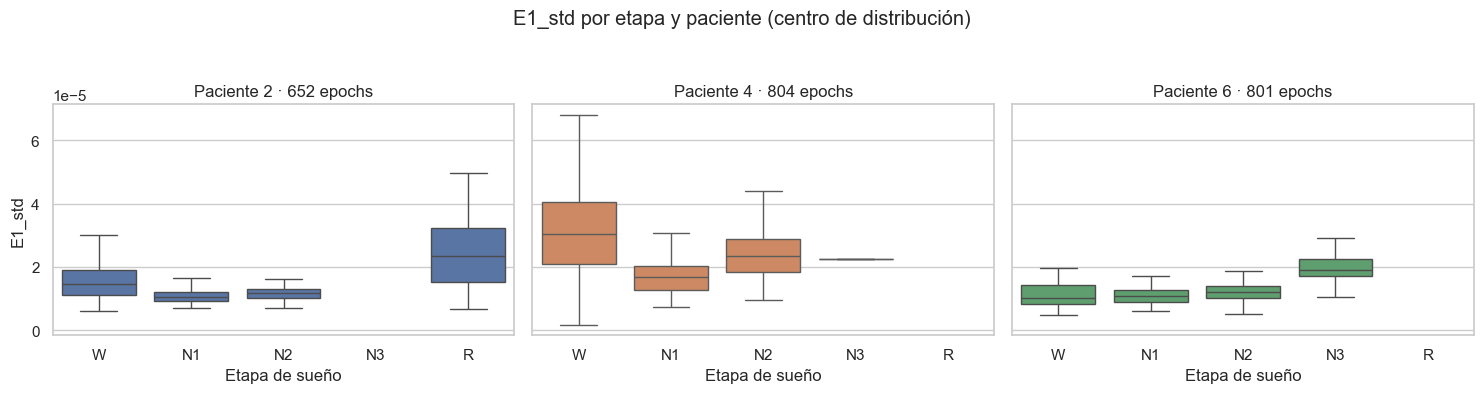

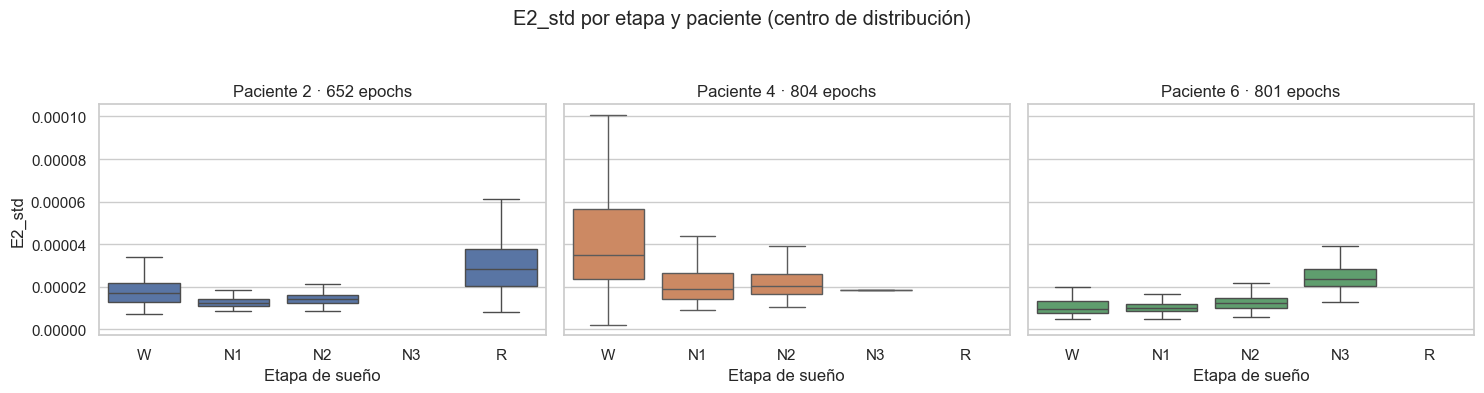

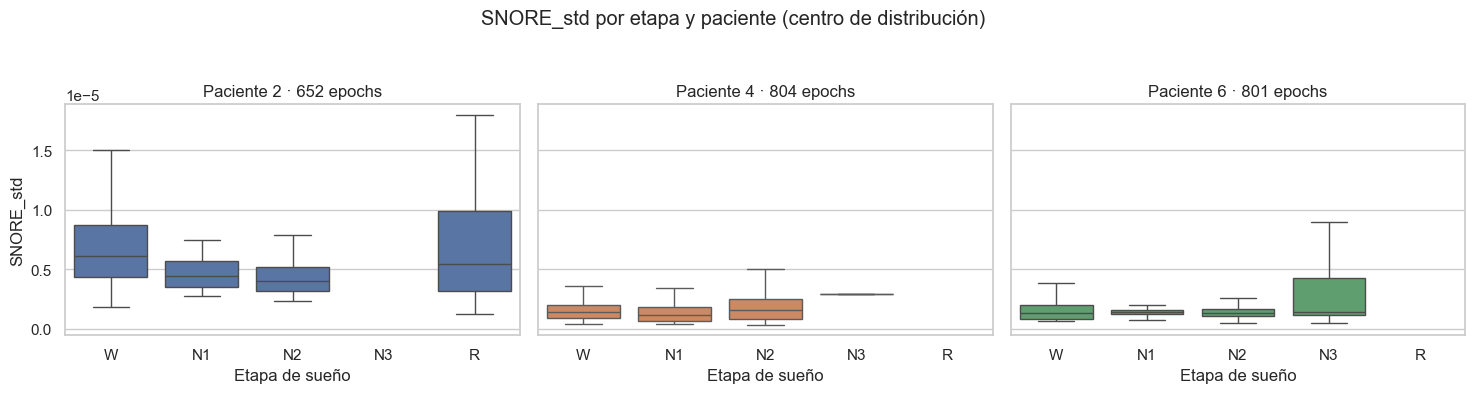

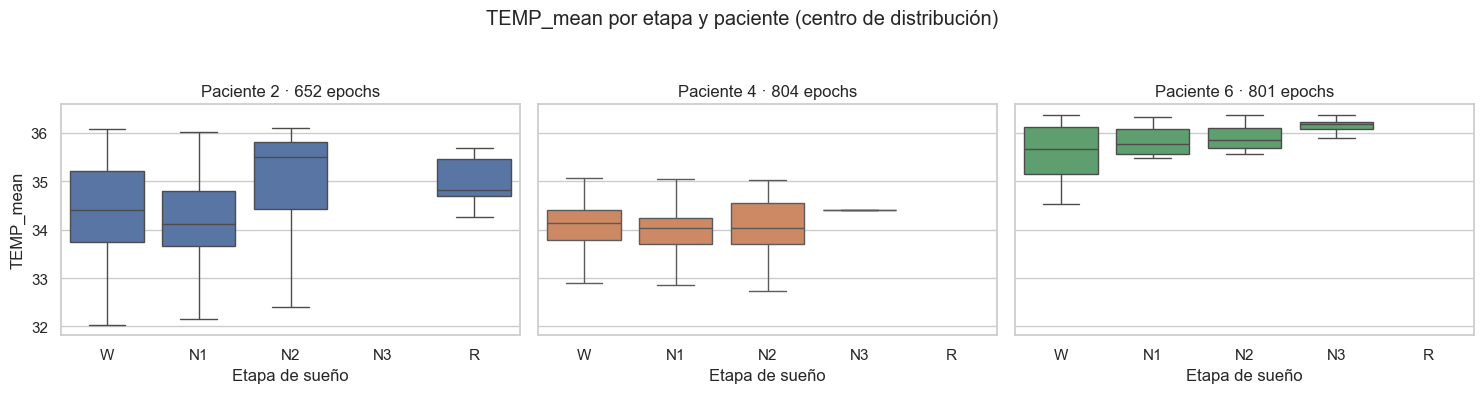

Los atípicos no aparecen como puntos en las figuras, pero permanecen en los datos y se resumen abajo por paciente y etapa.
MÍNIMOS, MÁXIMOS Y ATÍPICOS POR PACIENTE Y ETAPA


,patient_id,Sleep_Stage,caracteristica,epochs,mínimo,máximo,atípicos_IQR
0,2,N1,BVP_std,64,4.936,369.812,0
1,2,N1,E1_std,64,0.000,0.000,6
2,2,N1,E2_std,64,0.000,0.000,5
3,2,N1,SNORE_std,64,0.000,0.000,6
4,2,N1,TEMP_mean,64,32.162,36.020,0
5,2,N2,BVP_std,334,5.585,281.246,62
6,2,N2,E1_std,334,0.000,0.000,10
7,2,N2,E2_std,334,0.000,0.000,4
8,2,N2,SNORE_std,334,0.000,0.000,13
9,2,N2,TEMP_mean,334,32.077,36.105,4


In [101]:
# Resúmenes por epoch, alineados con las etiquetas del estudio.
senales_boxplot = ["BVP", "E1", "E2", "SNORE", "TEMP"]
columnas_necesarias = ["TIMESTAMP", "Sleep_Stage", *senales_boxplot]
caracteristicas_por_paciente = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    faltantes = set(columnas_necesarias) - set(columnas_por_archivo[nombre])
    if faltantes:
        raise ValueError(f"{nombre}: faltan columnas {sorted(faltantes)}")

    # Reutilizar la muestra cargada; leer solo siete columnas en los demás casos.
    datos = (
        df_sample_eda[columnas_necesarias]
        if ruta == sample_file
        else pd.read_csv(ruta, usecols=columnas_necesarias)
    )
    epoch_ids, completos, _ = definir_epochs(datos)
    datos_epoch = datos.loc[completos].copy()
    datos_epoch["epoch"] = epoch_ids[completos]

    grupos = datos_epoch.groupby("epoch", sort=True)
    etapas = grupos["Sleep_Stage"].first()
    puras = grupos["Sleep_Stage"].nunique(dropna=False).eq(1)
    tamano_valido = grupos.size().eq(3000)
    epochs_validos = puras & tamano_valido & etapas.isin(etapas_validas)

    resumen = pd.DataFrame({
        "Sleep_Stage": etapas.loc[epochs_validos],
    })
    for senal in senales_boxplot:
        valores = pd.to_numeric(datos_epoch[senal], errors="coerce")
        valores = valores.where(np.isfinite(valores))
        if senal == "TEMP":
            agregado = valores.groupby(datos_epoch["epoch"]).mean()
        else:
            agregado = valores.groupby(datos_epoch["epoch"]).std()
        resumen[f"{senal}_{'mean' if senal == 'TEMP' else 'std'}"] = (
            agregado.reindex(resumen.index)
        )

    resumen["patient_id"] = extract_patient_id(ruta)
    caracteristicas_por_paciente.append(resumen.reset_index())
    print(f"{nombre}: {len(resumen)} epochs completos con etapa válida")
    del datos_epoch, datos

if not caracteristicas_por_paciente:
    raise ValueError("No hay pacientes para comparar señales.")

caracteristicas_eda_22 = pd.concat(
    caracteristicas_por_paciente, ignore_index=True
)
columnas_boxplot = [
    "BVP_std", "E1_std", "E2_std", "SNORE_std", "TEMP_mean"
]

pacientes_grafico = sorted(caracteristicas_eda_22["patient_id"].unique())
colores_pacientes = sns.color_palette(n_colors=len(pacientes_grafico))

for columna in columnas_boxplot:
    fig, ejes = plt.subplots(
        1, len(pacientes_grafico),
        figsize=(5 * len(pacientes_grafico), 4),
        sharey=True, squeeze=False,
    )
    for eje, paciente, color in zip(
        ejes[0], pacientes_grafico, colores_pacientes
    ):
        datos_paciente = caracteristicas_eda_22.loc[
            caracteristicas_eda_22["patient_id"].eq(paciente)
        ]
        datos_validos = datos_paciente.loc[
            datos_paciente[columna].notna()
        ]
        if datos_validos.empty:
            eje.text(0.5, 0.5, "Sin epochs válidos",
                     ha="center", va="center", transform=eje.transAxes)
        else:
            sns.boxplot(
                data=datos_validos,
                x="Sleep_Stage", y=columna,
                order=etapas_validas, showfliers=False,
                whis=1.5, color=color, ax=eje,
            )
        eje.set_title(f"Paciente {paciente} · {len(datos_validos)} epochs")
        eje.set_xlabel("Etapa de sueño")
        eje.set_ylabel(columna if eje is ejes[0, 0] else "")

    fig.suptitle(f"{columna} por etapa y paciente (centro de distribución)")
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

print(
    "Los atípicos no aparecen como puntos en las figuras, pero permanecen "
    "en los datos y se resumen abajo por paciente y etapa."
)

# Mínimos y máximos reales; atípicos calculados dentro de cada paciente y etapa.
filas_extremos = []
for (paciente, etapa), grupo in caracteristicas_eda_22.groupby(
    ["patient_id", "Sleep_Stage"], observed=True
):
    for columna in columnas_boxplot:
        valores = grupo[columna].dropna()
        if valores.empty:
            continue
        q1, q3 = valores.quantile([0.25, 0.75])
        rango = q3 - q1
        atipicos = (valores.lt(q1 - 1.5 * rango)
                    | valores.gt(q3 + 1.5 * rango))
        filas_extremos.append({
            "patient_id": paciente,
            "Sleep_Stage": etapa,
            "caracteristica": columna,
            "epochs": len(valores),
            "mínimo": valores.min(),
            "máximo": valores.max(),
            "atípicos_IQR": int(atipicos.sum()),
        })

resumen_extremos_22 = pd.DataFrame(filas_extremos)
print("MÍNIMOS, MÁXIMOS Y ATÍPICOS POR PACIENTE Y ETAPA")
display(resumen_extremos_22.round(3))


## 2.3 Auditoría de Valores Nulos

In [102]:
# 2.3. Auditoría de faltantes y valores numéricos inválidos

# Columnas originales, excluyendo tiempo, objetivo y anotaciones.
columnas_excluidas = {
    "TIMESTAMP",
    "Sleep_Stage",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
}

resultados_calidad = []
resumen_calidad = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Auditando señales: {nombre}")

    columnas_csv = pd.read_csv(ruta, nrows=0).columns.tolist()
    señales = [
        col for col in columnas_csv
        if col not in columnas_excluidas
    ]

    conteos = {
        col: {"nulos": 0, "infinitos": 0, "no_numericos": 0}
        for col in señales
    }
    filas = 0

    # Reutilizar el paciente muestra ya cargado.
    if ruta == sample_file:
        bloques = [df_sample_eda[señales]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=señales,
            chunksize=200_000,
            low_memory=False,
        )

    for bloque in bloques:
        filas += len(bloque)

        for col in señales:
            original = bloque[col]
            numerico = pd.to_numeric(original, errors="coerce")

            conteos[col]["nulos"] += int(original.isna().sum())

            # Valores presentes que no pueden convertirse a números.
            conteos[col]["no_numericos"] += int(
                (original.notna() & numerico.isna()).sum()
            )

            conteos[col]["infinitos"] += int(
                numerico.isin([np.inf, -np.inf]).sum()
            )

    for col, conteo in conteos.items():
        resultados_calidad.append({
            "archivo": nombre,
            "señal": col,
            "muestras": filas,
            **conteo,
            "nulos_pct": (
                100 * conteo["nulos"] / filas if filas else np.nan
            ),
        })

    resumen_calidad.append({
        "archivo": nombre,
        "muestras": filas,
        "señales_revisadas": len(señales),
        # Son celdas afectadas; no filas distintas.
        "celdas_nulas": sum(c["nulos"] for c in conteos.values()),
        "celdas_infinitas": sum(
            c["infinitos"] for c in conteos.values()
        ),
        "celdas_no_numericas": sum(
            c["no_numericos"] for c in conteos.values()
        ),
    })

auditoria_señales = pd.DataFrame(resultados_calidad)
resumen_calidad = pd.DataFrame(resumen_calidad)

print("\nRESUMEN DE CALIDAD POR PACIENTE")
display(resumen_calidad)

problemas_calidad = auditoria_señales.loc[
    auditoria_señales[
        ["nulos", "infinitos", "no_numericos"]
    ].sum(axis=1) > 0
]

print("\nSEÑALES CON FALTANTES O VALORES INVÁLIDOS")

if problemas_calidad.empty:
    print(
        "No se encontraron nulos, infinitos ni valores "
        "no numéricos en las señales revisadas."
    )
else:
    display(problemas_calidad.round({"nulos_pct": 4}))

print(
    "\nNo se modificaron valores. "
    "Esta auditoría no detecta extremos, señales congeladas "
    "ni todos los posibles artefactos."
)

Auditando señales: S002_PSG_df.csv
Auditando señales: S004_PSG_df.csv
Auditando señales: S006_PSG_df.csv

RESUMEN DE CALIDAD POR PACIENTE


,archivo,muestras,señales_revisadas,celdas_nulas,celdas_infinitas,celdas_no_numericas
0,S002_PSG_df.csv,1958400,26,0,0,0
1,S004_PSG_df.csv,2413100,26,0,0,0
2,S006_PSG_df.csv,2403000,26,0,0,0



SEÑALES CON FALTANTES O VALORES INVÁLIDOS
No se encontraron nulos, infinitos ni valores no numéricos en las señales revisadas.

No se modificaron valores. Esta auditoría no detecta extremos, señales congeladas ni todos los posibles artefactos.


### 2.3.1. Distribución e inspección de extremos

Se calculan estadísticas descriptivas de HR, TEMP, EDA y SAO2 y se grafica su evolución hasta 30 segundos antes y después de sus mínimos y máximos.

El objetivo es identificar valores que requieran revisión antes de definir reglas de limpieza. Un extremo no implica necesariamente un error.

Este análisis utiliza únicamente el paciente muestra y no modifica los datos. Cada gráfico puede corresponder a un momento distinto y tiene su propia escala vertical.

Paciente revisado: 2

DISTRIBUCIÓN DE LAS SEÑALES


,count,mean,std,min,1%,25%,50%,75%,99%,max
HR,1958400.0,67.190774,7.728017,54.520000,57.920000,62.920000,65.180000,68.720000,101.520000,132.480000
TEMP,1958400.0,34.786420,0.971332,32.000000,32.150000,34.090000,34.840000,35.660000,36.070000,36.150000
EDA,1958400.0,0.231192,0.267470,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764
SAO2,1958400.0,0.911538,0.028327,0.808540,0.839901,0.889745,0.919749,0.929654,0.959701,0.971339


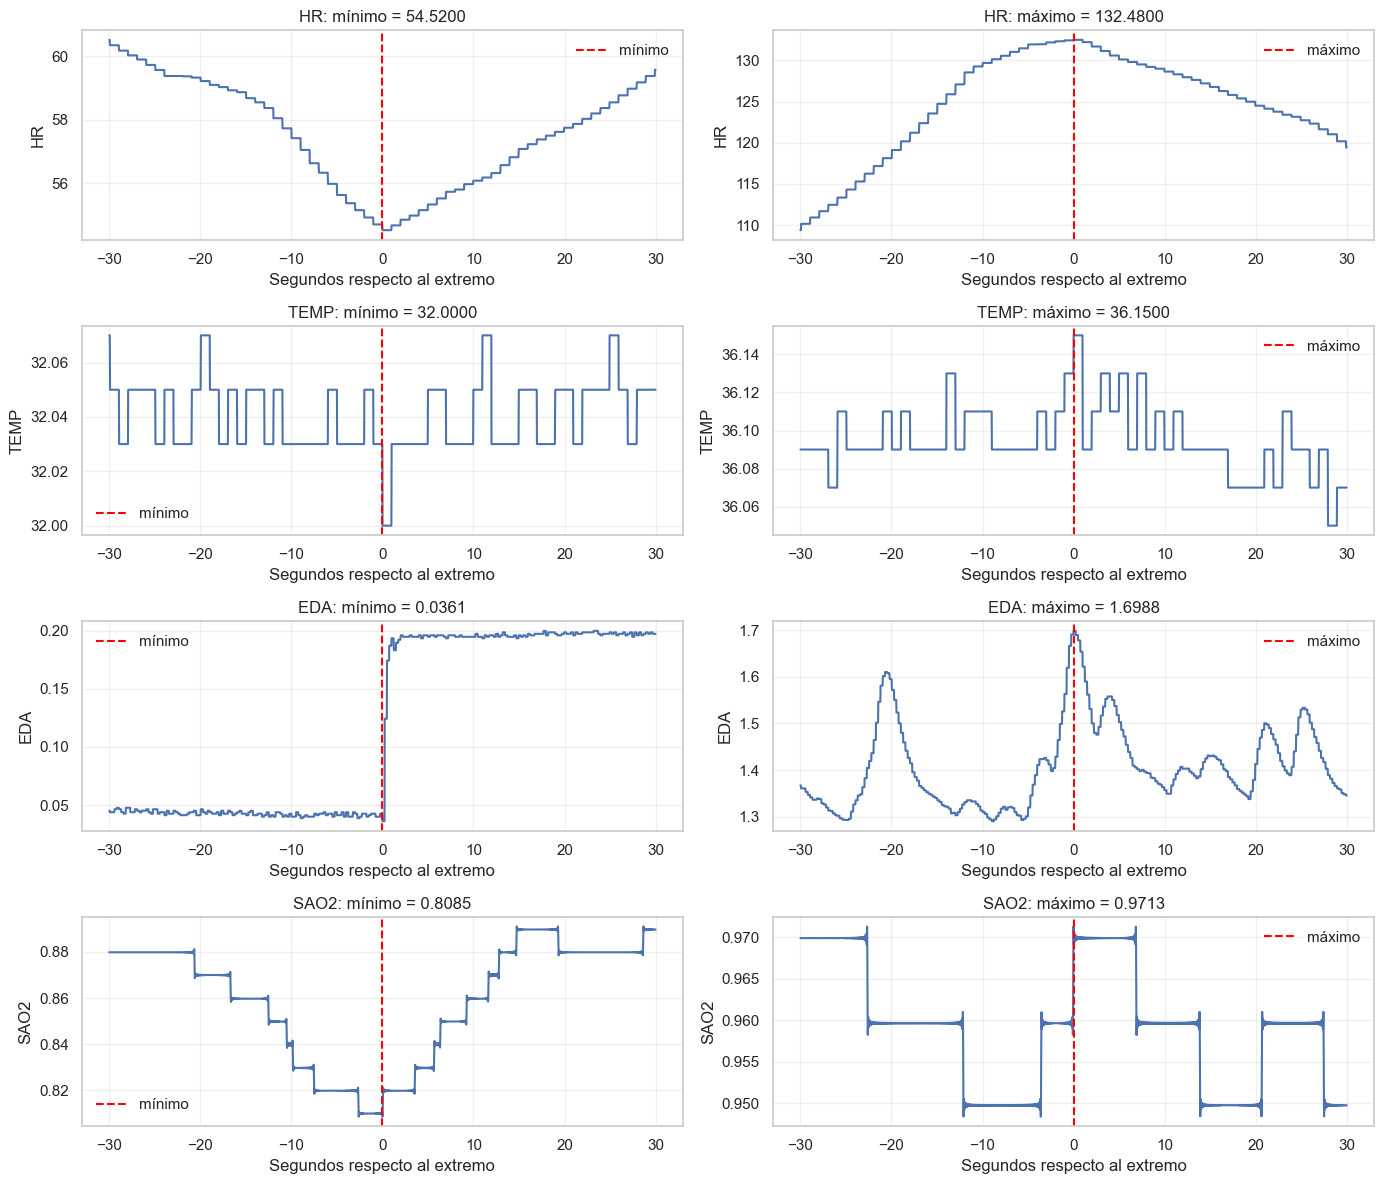


Los extremos y percentiles son descriptivos. No determinan automáticamente qué valores son errores. Cada gráfico tiene su propia escala vertical.


In [103]:
# 2.3.1. Distribución e inspección temporal de extremos

columnas_revision = ["HR", "TEMP", "EDA", "SAO2"]

# Serie numérica auxiliar; los datos originales se conservan.
valores_revision = (
    df_sample_eda[columnas_revision]
    .apply(pd.to_numeric, errors="coerce")
)

print("Paciente revisado:", extract_patient_id(sample_file))

print("\nDISTRIBUCIÓN DE LAS SEÑALES")
display(
    valores_revision
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

# Inspeccionar el mínimo y el máximo de cada señal.
# Cada gráfico puede corresponder a un momento distinto.
fig, axes = plt.subplots(
    len(columnas_revision), 2,
    figsize=(14, 3 * len(columnas_revision)),
    squeeze=False,
)

timestamps = pd.to_numeric(
    df_sample_eda["TIMESTAMP"], errors="coerce"
).reset_index(drop=True)

for fila, columna in enumerate(columnas_revision):
    valores = valores_revision[columna].reset_index(drop=True)
    finitos = valores.where(np.isfinite(valores))

    for j, extremo in enumerate(["mínimo", "máximo"]):
        ax = axes[fila, j]

        if finitos.notna().sum() == 0:
            ax.set_title(f"{columna}: sin valores finitos")
            ax.axis("off")
            continue

        # Si el extremo se repite, seleccionar su primera aparición.
        posicion = (
            finitos.idxmin()
            if extremo == "mínimo"
            else finitos.idxmax()
        )

        # Hasta 30 segundos antes y después, a 100 Hz.
        inicio = max(0, posicion - 3000)
        fin = min(len(valores), posicion + 3001)

        tiempo_relativo = (
            timestamps.iloc[inicio:fin] - timestamps.iloc[posicion]
        )

        ax.plot(
            tiempo_relativo,
            valores.iloc[inicio:fin].to_numpy(),
        )
        ax.axvline(
            0, color="red", linestyle="--", label=extremo
        )

        ax.set_title(
            f"{columna}: {extremo} = {valores.iloc[posicion]:.4f}"
        )
        ax.set_xlabel("Segundos respecto al extremo")
        ax.set_ylabel(columna)
        ax.grid(alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

print(
    "\nLos extremos y percentiles son descriptivos. "
    "No determinan automáticamente qué valores son errores. "
    "Cada gráfico tiene su propia escala vertical."
)

## 2.4 Preparación de epochs alineados del paciente muestra

In [104]:
# 2.4. Preparación de epochs alineados del paciente muestra

# Trabajar sobre una copia; conservar el registro original.
temp_df = df_sample_eda.reset_index(drop=True).copy()

# Validar continuidad e inferir alineación.
epoch_ids, completos, auditoria_muestra = definir_epochs(temp_df)

temp_df["epoch"] = epoch_ids

# Seleccionar únicamente ventanas completas de 3000 muestras.
temp_df = temp_df.loc[completos].copy()

# Verificar el tamaño de todas las ventanas seleccionadas.
muestras_por_epoch = temp_df.groupby("epoch").size()

if not muestras_por_epoch.eq(3000).all():
    raise ValueError("Hay epochs que no contienen 3000 muestras.")

# Comprobar que todas las filas originales estén contabilizadas.
filas_contabilizadas = (
    auditoria_muestra["filas_fragmento_inicial"]
    + auditoria_muestra["epochs_completos"] * 3000
    + auditoria_muestra["filas_fragmento_final"]
)

if filas_contabilizadas != len(df_sample_eda):
    raise ValueError("La auditoría no contabiliza todas las filas.")

print("Paciente:", extract_patient_id(sample_file))
print("\nAUDITORÍA TEMPORAL")
display(pd.DataFrame([auditoria_muestra]))

print("Filas seleccionadas:", len(temp_df))
print("Muestras por epoch: 3000")
print("Duración por epoch: 30 segundos")
print("Registro original conservado:", len(df_sample_eda), "filas")

# Preparar estadísticas exploratorias para la sección 2.5.
# En esta sección todavía no se calculan.
sensores_cols = ["HR", "TEMP", "EDA", "BVP", "SAO2"]

agg_dict = {
    col: ("std" if col == "BVP" else "mean")
    for col in sensores_cols
    if col in temp_df.columns
}

Paciente: 2

AUDITORÍA TEMPORAL


,filas_originales,desplazamiento,epochs_completos,filas_fragmento_inicial,filas_fragmento_final
0,1958400,2400,652,2400,0


Filas seleccionadas: 1956000
Muestras por epoch: 3000
Duración por epoch: 30 segundos
Registro original conservado: 1958400 filas


## 2.5 Variación y Evolución del Estado del Sueño a través de los Epochs

El hipnograma relaciona **tiempo desde el inicio del CSV** (eje horizontal) y **etapa anotada** (eje vertical) del paciente muestra. Cada bloque ocupa un epoch completo de 30 segundos. Los epochs con etiquetas mezcladas, faltantes o inválidas se muestran en «Revisar»; no se les asigna automáticamente la etapa más frecuente. La separación entre bloques no demuestra una transición fisiológica instantánea: representa la resolución de las anotaciones. La matriz anterior cuenta cambios entre epochs consecutivos y puros.

Orden visual solicitado, de arriba hacia abajo: W, N1, N2, N3 y R. REM se ubica al final para facilitar la lectura, pero **no es un nivel de profundidad mayor que N3**; las etapas son categorías.


Paciente: 2
Epochs completos: 652
Epochs puros: 652
Epochs con varias etapas válidas: 0
Epochs con empate de moda: 0
Pureza mínima: 1.0

EPOCHS PARA REVISIÓN
Todas las ventanas contienen una única etapa válida.

TRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS


Etapa actual,W,N1,N2,N3,R
Etapa anterior,,,,,
W,102,31,26,0,14
N1,26,14,23,0,1
N2,29,19,284,0,2
N3,0,0,0,0,0
R,17,0,0,0,63


Pares contabilizados: 651


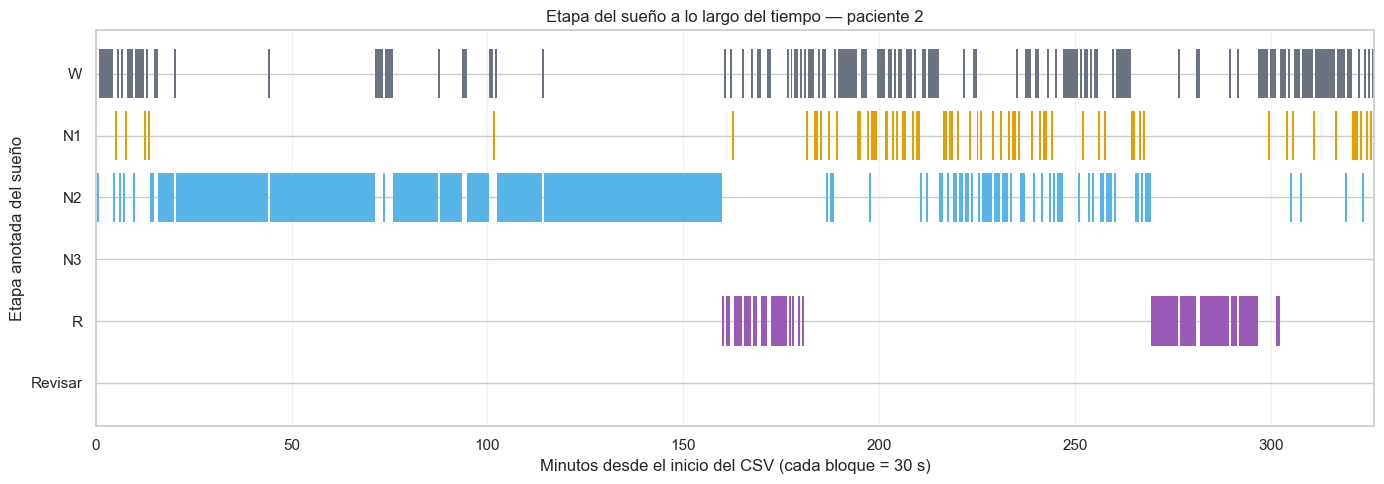

In [105]:
# 2.5. Evolución y transiciones del sueño

etapas_validas = ["W", "N1", "N2", "N3", "R"]


def process_epoch(group):
    res = {}

    res["tiempo_min"] = (
        group["TIMESTAMP"].iloc[0]
        - df_sample_eda["TIMESTAMP"].iloc[0]
    ) / 60

    etapas = group["Sleep_Stage"]
    etiquetas = etapas.where(etapas.isin(etapas_validas))
    modas = etiquetas.mode()

    res["stage_inicio"] = etapas.iloc[0]
    res["stage_fin"] = etapas.iloc[-1]

    # No elegir arbitrariamente una etapa cuando hay empate.
    res["empate_moda"] = len(modas) > 1
    res["stage_moda"] = (
        modas.iloc[0] if len(modas) == 1 else np.nan
    )

    res["etiquetas_nulas"] = int(etapas.isna().sum())
    res["etiquetas_invalidas"] = int(
        (etapas.notna() & ~etapas.isin(etapas_validas)).sum()
    )

    res["hubo_transicion_interna"] = (
        etiquetas.nunique(dropna=True) > 1
    )

    conteos = etiquetas.value_counts()
    res["porcentaje_pureza"] = (
        conteos.max() / len(group) if not conteos.empty else 0.0
    )

    # Estadísticas exploratorias configuradas en 2.4.
    for col, operacion in agg_dict.items():
        if operacion == "mean":
            res[f"{col}_mean"] = group[col].mean()
        elif operacion == "std":
            res[f"{col}_std"] = group[col].std()

    return pd.Series(res)


# Resumir cada ventana completa.
# La iteración explícita conserva la columna epoch en el grupo.
resultados = []

for epoch_id, group in temp_df.groupby("epoch", sort=True):
    resultado = process_epoch(group)
    resultado["epoch"] = epoch_id
    resultados.append(resultado)

df_sample_epochs = (
    pd.DataFrame(resultados)
    .sort_values("epoch")
    .reset_index(drop=True)
)

# Un epoch puro debe tener todas sus muestras en una etapa válida.
mascara_puros = df_sample_epochs["porcentaje_pureza"].eq(1.0)

print("Paciente:", extract_patient_id(sample_file))
print("Epochs completos:", len(df_sample_epochs))
print("Epochs puros:", int(mascara_puros.sum()))
print(
    "Epochs con varias etapas válidas:",
    int(df_sample_epochs["hubo_transicion_interna"].sum()),
)
print(
    "Epochs con empate de moda:",
    int(df_sample_epochs["empate_moda"].sum()),
)
print(
    "Pureza mínima:",
    df_sample_epochs["porcentaje_pureza"].min(),
)

# Mostrar cualquier ventana que necesite revisión.
epochs_revision = df_sample_epochs.loc[
    ~mascara_puros,
    [
        "epoch", "tiempo_min", "stage_inicio", "stage_fin",
        "stage_moda", "porcentaje_pureza", "empate_moda",
        "etiquetas_nulas", "etiquetas_invalidas",
    ],
]

print("\nEPOCHS PARA REVISIÓN")
if epochs_revision.empty:
    print("Todas las ventanas contienen una única etapa válida.")
else:
    display(epochs_revision)

# Relacionar cada epoch con el anterior, sin saltar ventanas.
df_sample_epochs["stage_moda_prev"] = (
    df_sample_epochs["stage_moda"].shift(1)
)

consecutivos = df_sample_epochs["epoch"].diff().eq(1)

# Usar únicamente pares de epochs consecutivos y puros.
pares_validos = (
    consecutivos
    & mascara_puros
    & mascara_puros.shift(1, fill_value=False)
)

transition_matrix = pd.crosstab(
    df_sample_epochs.loc[pares_validos, "stage_moda_prev"],
    df_sample_epochs.loc[pares_validos, "stage_moda"],
    rownames=["Etapa anterior"],
    colnames=["Etapa actual"],
).reindex(
    index=etapas_validas,
    columns=etapas_validas,
    fill_value=0,
)

print("\nTRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS")
display(transition_matrix)
print("Pares contabilizados:", int(pares_validos.sum()))

# Cada rectángulo representa el intervalo completo de un epoch (0,5 min).
stage_mapping = {"W": 4, "N1": 3, "N2": 2, "N3": 1, "R": 0}
colores_etapas = {
    "W": "#6b7280", "R": "#9b59b6", "N1": "#e69f00",
    "N2": "#56b4e9", "N3": "#0072b2",
}
duracion_epoch_min = 0.5
validos_grafico = (
    mascara_puros & df_sample_epochs["stage_moda"].isin(etapas_validas)
)

fig, ax = plt.subplots(figsize=(14, 5))
for etapa, nivel in stage_mapping.items():
    seleccion = validos_grafico & df_sample_epochs["stage_moda"].eq(etapa)
    ax.barh(
        nivel, duracion_epoch_min,
        left=df_sample_epochs.loc[seleccion, "tiempo_min"],
        height=0.8, color=colores_etapas[etapa], linewidth=0,
    )

# Mostrar ventanas no puras sin convertir la moda en una etiqueta definitiva.
revisables = ~validos_grafico
if revisables.any():
    ax.barh(
        -1, duracion_epoch_min,
        left=df_sample_epochs.loc[revisables, "tiempo_min"],
        height=0.8, color="#bdbdbd", linewidth=0,
    )

ax.set_yticks(
    [-1, 0, 1, 2, 3, 4],
    labels=["Revisar", "R", "N3", "N2", "N1", "W"],
)
ax.set_xlim(
    0, df_sample_epochs["tiempo_min"].max() + duracion_epoch_min
)
ax.set_ylim(-1.7, 4.7)
ax.set_xlabel("Minutos desde el inicio del CSV (cada bloque = 30 s)")
ax.set_ylabel("Etapa anotada del sueño")
ax.set_title(
    f"Etapa del sueño a lo largo del tiempo — paciente "
    f"{extract_patient_id(sample_file)}"
)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# 2.6. Auditoría general de los pacientes disponibles

Se revisan todos los registros para detectar diferencias de estructura, problemas temporales, etiquetas inválidas y valores faltantes o no numéricos en las señales.

También se registran rangos, ceros en SAO2 y tramos exactamente constantes. Estos casos requieren interpretación: no se consideran errores automáticamente.

Los archivos se procesan por bloques y los resultados se guardan en CSV. En ejecuciones posteriores se reutilizan si coinciden las fuentes, los parámetros y la versión de las reglas; para repetir la lectura completa, activar `FORZAR_RECALCULO_AUDITORIA`. No se modifican los datos originales.

In [106]:
# 2.6. Auditoría general por bloques

TAMANO_BLOQUE = 200_000

# Criterio exploratorio para listar tramos constantes.
# No es un umbral de limpieza ni demuestra un fallo del sensor.
SEGUNDOS_CONSTANTES_REVISION = 30

archivos_auditar = list(data_files)

if not archivos_auditar:
    raise ValueError("No hay archivos para auditar.")

nombres = [p.name for p in archivos_auditar]
if len(nombres) != len(set(nombres)):
    raise ValueError(
        "Hay nombres de archivo duplicados. Revisar data_files."
    )

print("Archivos encontrados:", len(archivos_auditar))

# S002 se utiliza únicamente como referencia de columnas.
referencia = next(
    (p for p in archivos_auditar if p.name == "S002_PSG_df.csv"),
    archivos_auditar[0],
)
columnas_referencia = pd.read_csv(referencia, nrows=0).columns.tolist()

excluidas = {
    "TIMESTAMP", "Sleep_Stage", "patient_id",
    "Obstructive_Apnea", "Central_Apnea",
    "Hypopnea", "Multiple_Events",
}
senales_referencia = [
    c for c in columnas_referencia if c not in excluidas
]
etapas_validas = ["W", "N1", "N2", "N3", "R"]

# Evitar releer todos los CSV de 100 Hz si la auditoría sigue vigente.
FORZAR_RECALCULO_AUDITORIA = False
AUDITORIA_CACHE_VERSION = 1  # Incrementar si cambia la lógica de auditoría.
carpeta_salida = Path("/kaggle/working/auditoria")
rutas_auditoria = {
    "pacientes": carpeta_salida / "auditoria_pacientes.csv",
    "senales": carpeta_salida / "auditoria_senales.csv",
    "casos": carpeta_salida / "casos_revision.csv",
}
ruta_manifiesto_auditoria = carpeta_salida / "manifest_auditoria_v1.json"
firma_auditoria = {
    "version": AUDITORIA_CACHE_VERSION,
    "tamano_bloque": TAMANO_BLOQUE,
    "segundos_constantes_revision": SEGUNDOS_CONSTANTES_REVISION,
    "columnas_referencia": columnas_referencia,
    "senales_referencia": senales_referencia,
    "etapas_validas": etapas_validas,
    "fuentes": [
        {
            "archivo": ruta.name, "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(archivos_auditar, key=lambda p: p.name)
    ],
}
cache_auditoria_valida = False
if (not FORZAR_RECALCULO_AUDITORIA
        and ruta_manifiesto_auditoria.exists()
        and all(ruta.exists() for ruta in rutas_auditoria.values())):
    try:
        with ruta_manifiesto_auditoria.open(encoding="utf-8") as archivo:
            manifiesto_auditoria = json.load(archivo)
        if manifiesto_auditoria.get("firma") != firma_auditoria:
            raise ValueError("Las fuentes o reglas de auditoría cambiaron")
        pacientes_cache = pd.read_csv(rutas_auditoria["pacientes"], low_memory=False)
        senales_cache = pd.read_csv(rutas_auditoria["senales"], low_memory=False)
        casos_cache = pd.read_csv(rutas_auditoria["casos"], low_memory=False)
        if manifiesto_auditoria.get("filas") != {
            "pacientes": len(pacientes_cache),
            "senales": len(senales_cache),
            "casos": len(casos_cache),
        }:
            raise ValueError("Las tablas no coinciden con el manifiesto")
        if (len(pacientes_cache) != len(archivos_auditar)
            or pacientes_cache["archivo"].duplicated().any()
            or set(pacientes_cache["archivo"]) != set(nombres)
            or not pacientes_cache["estado_lectura"].eq("Completa").all()):
            raise ValueError("La auditoría de pacientes está incompleta")
        if not {"archivo", "señal", "nulos", "no_numericos", "infinitos"}.issubset(senales_cache.columns):
            raise ValueError("Faltan columnas en la auditoría de señales")
        if not {"archivo", "señal", "motivo"}.issubset(casos_cache.columns):
            raise ValueError("Faltan columnas en los casos de revisión")
        if (not set(senales_cache["archivo"]).issubset(nombres)
            or not set(casos_cache["archivo"]).issubset(nombres)):
            raise ValueError("Las tablas contienen archivos ajenos a las fuentes")
        cache_auditoria_valida = True
        print("Auditoría cargada desde CSV existente:", carpeta_salida)
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché de auditoría no utilizable ({error}); se recalculará.")

if not cache_auditoria_valida:
    carpeta_salida.mkdir(parents=True, exist_ok=True)
    ruta_manifiesto_auditoria.unlink(missing_ok=True)
    print("Se auditarán los CSV originales por bloques.")


def nuevo_tramo():
    return {
        "cola": 0,
        "mayor": 0,
        "inicio": None,
    }


def actualizar_tramo(mascara, estado, fila_inicio):
    """Mayor tramo True, incluyendo continuidad entre bloques."""
    mascara = np.asarray(mascara, dtype=bool)

    if len(mascara) == 0:
        return

    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    if len(inicios) == 0:
        estado["cola"] = 0
        return

    largos = finales - inicios
    posiciones = fila_inicio + inicios

    if inicios[0] == 0:
        largos[0] += estado["cola"]
        posiciones[0] -= estado["cola"]

    mayor = int(np.argmax(largos))

    if largos[mayor] > estado["mayor"]:
        estado["mayor"] = int(largos[mayor])
        estado["inicio"] = int(posiciones[mayor])

    estado["cola"] = (
        int(largos[-1]) if mascara[-1] else 0
    )


resultados_pacientes = []
resultados_senales = []
casos_revision = []

for numero, ruta in enumerate(archivos_auditar if not cache_auditoria_valida else [], start=1):
    print(
        f"[{numero}/{len(archivos_auditar)}] {ruta.name}",
        flush=True,
    )

    try:
        columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
        columnas_faltantes = sorted(
            set(columnas_referencia) - set(columnas)
        )
        columnas_adicionales = sorted(
            set(columnas) - set(columnas_referencia)
        )

        requeridas = {"TIMESTAMP", "Sleep_Stage"}
        if not requeridas.issubset(columnas):
            raise ValueError("Falta TIMESTAMP o Sleep_Stage.")

        senales = [
            c for c in senales_referencia if c in columnas
        ]

        controles = {
            c: {
                "nulos": 0,
                "no_numericos": 0,
                "infinitos": 0,
                "minimo": np.inf,
                "maximo": -np.inf,
                "tipos": set(),
                "anterior": np.nan,
                "constante": nuevo_tramo(),
            }
            for c in senales
        }

        filas = 0
        timestamp_anterior = None
        etapa_anterior = None
        timestamp_inicio = None
        timestamp_final = None

        timestamps_invalidos = 0
        intervalos_irregulares = 0
        intervalos_no_crecientes = 0

        etiquetas_nulas = 0
        etiquetas_invalidas = 0
        valores_invalidos = set()
        conteos_etapas = {e: 0 for e in etapas_validas}

        restos = set()
        cambios_etapa = 0
        ceros_sao2 = 0
        sao2_fuera_0_1 = 0
        tramo_ceros = nuevo_tramo()

        columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales

        with pd.read_csv(
            ruta,
            usecols=columnas_leer,
            chunksize=TAMANO_BLOQUE,
            low_memory=False,
        ) as lector:

            for bloque in lector:
                fila_inicio = filas
                cantidad = len(bloque)

                # 1. Tiempo: incluir el límite entre bloques.
                t = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy(dtype=float)

                if timestamp_inicio is None:
                    timestamp_inicio = t[0]
                timestamp_final = t[-1]

                timestamps_invalidos += int(
                    (~np.isfinite(t)).sum()
                )

                tiempos_comparar = (
                    np.r_[timestamp_anterior, t]
                    if timestamp_anterior is not None
                    else t
                )

                diferencias = np.diff(tiempos_comparar)
                pares_finitos = (
                    np.isfinite(tiempos_comparar[:-1])
                    & np.isfinite(tiempos_comparar[1:])
                )

                intervalos_irregulares += int(
                    (
                        pares_finitos
                        & ~np.isclose(
                            diferencias, 0.01,
                            atol=1e-6, rtol=0,
                        )
                    ).sum()
                )
                intervalos_no_crecientes += int(
                    (pares_finitos & (diferencias <= 0)).sum()
                )
                timestamp_anterior = t[-1]

                # 2. Etiquetas y alineación.
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = etapa_anterior

                invalidas = (
                    etapas.notna()
                    & ~etapas.isin(etapas_validas)
                )

                etiquetas_nulas += int(etapas.isna().sum())
                etiquetas_invalidas += int(invalidas.sum())
                valores_invalidos.update(
                    etapas.loc[invalidas].astype(str).unique()
                )

                conteos = etapas.value_counts()
                for etapa in etapas_validas:
                    conteos_etapas[etapa] += int(
                        conteos.get(etapa, 0)
                    )

                cambios = (
                    etapas.isin(etapas_validas)
                    & anteriores.isin(etapas_validas)
                    & etapas.ne(anteriores)
                )

                posiciones = (
                    np.flatnonzero(cambios.to_numpy())
                    + fila_inicio
                )

                cambios_etapa += len(posiciones)
                restos.update((posiciones % 3000).tolist())
                etapa_anterior = etapas.iloc[-1]

                # 3. Calidad y rangos de cada señal.
                for col in senales:
                    control = controles[col]
                    original = bloque[col]
                    control["tipos"].add(str(original.dtype))

                    numerico = pd.to_numeric(
                        original, errors="coerce"
                    )
                    valores = numerico.to_numpy(dtype=float)
                    finitos = np.isfinite(valores)

                    control["nulos"] += int(original.isna().sum())
                    control["no_numericos"] += int(
                        (original.notna() & numerico.isna()).sum()
                    )
                    control["infinitos"] += int(
                        np.isinf(valores).sum()
                    )

                    if finitos.any():
                        control["minimo"] = min(
                            control["minimo"],
                            float(valores[finitos].min()),
                        )
                        control["maximo"] = max(
                            control["maximo"],
                            float(valores[finitos].max()),
                        )

                    # Igualdad exacta con la muestra anterior.
                    anteriores_valores = np.r_[
                        control["anterior"], valores[:-1]
                    ]
                    iguales = (
                        finitos
                        & np.isfinite(anteriores_valores)
                        & (valores == anteriores_valores)
                    )

                    actualizar_tramo(
                        iguales, control["constante"], fila_inicio
                    )
                    control["anterior"] = valores[-1]

                    if col == "SAO2":
                        ceros = finitos & (valores == 0)
                        ceros_sao2 += int(ceros.sum())

                        sao2_fuera_0_1 += int(
                            (
                                finitos
                                & ((valores < 0) | (valores > 1))
                            ).sum()
                        )

                        actualizar_tramo(
                            ceros, tramo_ceros, fila_inicio
                        )

                filas += cantidad

        # 4. Determinar si puede inferirse una alineación.
        continuo = (
            timestamps_invalidos == 0
            and intervalos_irregulares == 0
            and filas > 0
        )

        desplazamiento = np.nan
        epochs_completos = np.nan
        fragmento_inicial = np.nan
        fragmento_final = np.nan

        if not continuo:
            estado_alineacion = "Revisar tiempo"
        elif len(restos) == 0:
            estado_alineacion = "Sin cambios: no determinada"
        elif len(restos) > 1:
            estado_alineacion = "Desplazamientos inconsistentes"
        else:
            estado_alineacion = "Alineación candidata consistente"
            desplazamiento = int(next(iter(restos)))
            epochs_completos = (filas - desplazamiento) // 3000
            fragmento_inicial = desplazamiento
            fragmento_final = (filas - desplazamiento) % 3000

        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Completa",
            "filas": filas,
            "columnas_csv": len(columnas),
            "columnas_faltantes": columnas_faltantes,
            "columnas_adicionales": columnas_adicionales,
            "timestamp_inicio": timestamp_inicio,
            "timestamp_final": timestamp_final,
            "timestamps_invalidos": timestamps_invalidos,
            "intervalos_irregulares": intervalos_irregulares,
            "intervalos_no_crecientes": intervalos_no_crecientes,
            "etiquetas_nulas": etiquetas_nulas,
            "etiquetas_invalidas": etiquetas_invalidas,
            "valores_invalidos": sorted(valores_invalidos),
            "cambios_etapa": cambios_etapa,
            "restos_3000": sorted(restos),
            "estado_alineacion": estado_alineacion,
            "desplazamiento": desplazamiento,
            "epochs_completos": epochs_completos,
            "fragmento_inicial": fragmento_inicial,
            "fragmento_final": fragmento_final,
            "ceros_sao2": ceros_sao2,
            # Revisar escala antes de considerar estos valores errores.
            "sao2_fuera_escala_0_1": sao2_fuera_0_1,
            **{f"muestras_{e}": conteos_etapas[e]
               for e in etapas_validas},
        })

        for col, control in controles.items():
            tramo = control["constante"]

            # N igualdades consecutivas representan N+1 muestras.
            muestras_constantes = (
                tramo["mayor"] + 1 if tramo["mayor"] else 0
            )
            inicio_constante = (
                tramo["inicio"] - 1
                if tramo["mayor"] else None
            )
            duracion_constante = (
                tramo["mayor"] / 100
            )

            resultados_senales.append({
                "archivo": ruta.name,
                "señal": col,
                "filas": filas,
                "tipos_observados": " / ".join(
                    sorted(control["tipos"])
                ),
                "nulos": control["nulos"],
                "no_numericos": control["no_numericos"],
                "infinitos": control["infinitos"],
                "minimo": (
                    control["minimo"]
                    if np.isfinite(control["minimo"]) else np.nan
                ),
                "maximo": (
                    control["maximo"]
                    if np.isfinite(control["maximo"]) else np.nan
                ),
                "mayor_tramo_constante_muestras": muestras_constantes,
                "inicio_tramo_constante_fila": inicio_constante,
                "duracion_constante_segundos_100hz":
                    duracion_constante,
            })

            if duracion_constante >= SEGUNDOS_CONSTANTES_REVISION:
                casos_revision.append({
                    "archivo": ruta.name,
                    "señal": col,
                    "motivo": "Mayor tramo exactamente constante",
                    "fila_inicio": inicio_constante,
                    "muestras": muestras_constantes,
                    "duracion_equivalente_segundos":
                        muestras_constantes / 100,
                })

        if tramo_ceros["mayor"] > 0:
            casos_revision.append({
                "archivo": ruta.name,
                "señal": "SAO2",
                "motivo": "Mayor tramo de ceros",
                "fila_inicio": tramo_ceros["inicio"],
                "muestras": tramo_ceros["mayor"],
                "duracion_equivalente_segundos":
                    tramo_ceros["mayor"] / 100,
            })

    except Exception as error:
        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Error",
            "error": str(error),
        })
        print("Error registrado:", error, flush=True)

    # Guardar avance después de cada paciente.
    pd.DataFrame(resultados_pacientes).to_csv(
        rutas_auditoria["pacientes"], index=False
    )
    pd.DataFrame(resultados_senales).to_csv(
        rutas_auditoria["senales"], index=False
    )
    pd.DataFrame(
        casos_revision,
        columns=[
            "archivo", "señal", "motivo", "fila_inicio",
            "muestras", "duracion_equivalente_segundos",
        ],
    ).to_csv(
        rutas_auditoria["casos"], index=False
    )

# Tablas disponibles para el análisis posterior.
if cache_auditoria_valida:
    auditoria_pacientes = pacientes_cache
    auditoria_senales = senales_cache
    casos_revision = casos_cache
else:
    auditoria_pacientes = pd.DataFrame(resultados_pacientes)
    auditoria_senales = pd.DataFrame(resultados_senales)
    casos_revision = pd.DataFrame(casos_revision)
    if auditoria_pacientes["estado_lectura"].eq("Completa").all():
        with ruta_manifiesto_auditoria.open("w", encoding="utf-8") as archivo:
            json.dump({
                "firma": firma_auditoria,
                "filas": {
                    "pacientes": len(auditoria_pacientes),
                    "senales": len(auditoria_senales),
                    "casos": len(casos_revision),
                },
            }, archivo, ensure_ascii=False, indent=2)
        print("Caché de auditoría guardada:", ruta_manifiesto_auditoria)
    else:
        print("Auditoría con errores de lectura; no se guardó manifiesto de caché.")

print("\nAUDITORÍA FINALIZADA")
print("Archivos registrados:", len(auditoria_pacientes))
print(
    "Lecturas completas:",
    auditoria_pacientes["estado_lectura"].eq("Completa").sum(),
)
print(
    "Errores de lectura:",
    auditoria_pacientes["estado_lectura"].eq("Error").sum(),
)

if "estado_alineacion" in auditoria_pacientes:
    print("\nESTADOS DE ALINEACIÓN")
    print(
        auditoria_pacientes["estado_alineacion"]
        .value_counts()
        .to_string()
    )

if not auditoria_senales.empty:
    print("\nCELDAS AFECTADAS EN SEÑALES")
    print(
        auditoria_senales[
            ["nulos", "no_numericos", "infinitos"]
        ].sum().to_string()
    )

print("\nCasos registrados para revisión:", len(casos_revision))
print("Resultados disponibles en:", carpeta_salida)

Archivos encontrados: 18
Se auditarán los CSV originales por bloques.
[1/18] S002_PSG_df.csv
[2/18] S003_PSG_df.csv
[3/18] S004_PSG_df.csv
[4/18] S005_PSG_df.csv
[5/18] S006_PSG_df.csv
[6/18] S007_PSG_df.csv
[7/18] S008_PSG_df.csv
[8/18] S009_PSG_df.csv
[9/18] S010_PSG_df.csv
[10/18] S016_PSG_df.csv
[11/18] S017_PSG_df.csv
[12/18] S019_PSG_df.csv
[13/18] S082_PSG_df.csv
[14/18] S083_PSG_df.csv
[15/18] S084_PSG_df.csv
[16/18] S086_PSG_df.csv
[17/18] S087_PSG_df.csv
[18/18] S088_PSG_df.csv
Caché de auditoría guardada: \kaggle\working\auditoria\manifest_auditoria_v1.json

AUDITORÍA FINALIZADA
Archivos registrados: 18
Lecturas completas: 18
Errores de lectura: 0

ESTADOS DE ALINEACIÓN
estado_alineacion
Alineación candidata consistente    18

CELDAS AFECTADAS EN SEÑALES
nulos           0
no_numericos    0
infinitos       0

Casos registrados para revisión: 153
Resultados disponibles en: \kaggle\working\auditoria


### 2.6.1. Revisión de alineación y etiquetas faltantes

Se localizan los cambios de etapa de S027 y S048 para investigar
sus desplazamientos inconsistentes.

También se identifican los tramos con etiquetas inválidas en
S027, S089, S095 y S096. La etiqueta `Missing` representa un
valor presente en el archivo, pero no una etapa válida del modelo.

No se eliminan filas ni se asignan desplazamientos automáticamente.
El objetivo es reunir evidencia antes de definir el tratamiento.

In [107]:
# 2.6.1. Inspección de alineación y etiquetas

pacientes_revision_preferidos = [
    "S027_PSG_df.csv",
    "S048_PSG_df.csv",
    "S089_PSG_df.csv",
    "S095_PSG_df.csv",
    "S096_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_etiquetas = [
    nombre for nombre in pacientes_revision_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_etiquetas:
    nombres_revision_etiquetas = [p.name for p in data_files[:2]]
    print("Casos históricos ausentes; se inspeccionan ejemplos disponibles.")

etapas_validas = ["W", "N1", "N2", "N3", "R"]
cambios_revision = []
tramos_etiquetas_revision = []


def registrar_tramos_invalidos(
    mascara, tiempos, fila_inicio, archivo, resultados
):
    """Registrar tramos contiguos, uniendo límites entre bloques."""
    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    for inicio, fin in zip(inicios, finales):
        fila_desde = int(fila_inicio + inicio)
        fila_hasta = int(fila_inicio + fin - 1)

        if (
            resultados
            and resultados[-1]["archivo"] == archivo
            and resultados[-1]["fila_final"] + 1 == fila_desde
        ):
            resultados[-1]["fila_final"] = fila_hasta
            resultados[-1]["timestamp_final"] = float(tiempos[fin - 1])
        else:
            resultados.append({
                "archivo": archivo,
                "fila_inicio": fila_desde,
                "fila_final": fila_hasta,
                "timestamp_inicio": float(tiempos[inicio]),
                "timestamp_final": float(tiempos[fin - 1]),
            })


for nombre in nombres_revision_etiquetas:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando: {nombre}", flush=True)

    fila_inicio = 0
    ultima_etapa = None

    with pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "Sleep_Stage"],
        chunksize=200_000,
    ) as lector:
        for bloque in lector:
            etapas = bloque["Sleep_Stage"].reset_index(drop=True)
            tiempos = pd.to_numeric(
                bloque["TIMESTAMP"], errors="coerce"
            ).to_numpy()

            anteriores = etapas.shift()
            if fila_inicio > 0:
                anteriores.iloc[0] = ultima_etapa

            # Registrar todo cambio, incluyendo entrada/salida de Missing.
            cambios = etapas.ne(anteriores).fillna(False)
            if fila_inicio == 0:
                cambios.iloc[0] = False

            posiciones = np.flatnonzero(cambios.to_numpy())

            for posicion in posiciones:
                anterior = anteriores.iloc[posicion]
                actual = etapas.iloc[posicion]
                fila_original = fila_inicio + int(posicion)

                entre_validas = (
                    anterior in etapas_validas
                    and actual in etapas_validas
                )

                cambios_revision.append({
                    "archivo": nombre,
                    "fila_original": fila_original,
                    "TIMESTAMP": tiempos[posicion],
                    "etapa_anterior": anterior,
                    "etapa_actual": actual,
                    "entre_etapas_validas": entre_validas,
                    "resto_3000": fila_original % 3000,
                })

            invalidas = ~etapas.isin(etapas_validas)
            registrar_tramos_invalidos(
                invalidas.to_numpy(),
                tiempos,
                fila_inicio,
                nombre,
                tramos_etiquetas_revision,
            )

            ultima_etapa = etapas.iloc[-1]
            fila_inicio += len(bloque)

cambios_revision = pd.DataFrame(
    cambios_revision,
    columns=[
        "archivo", "fila_original", "TIMESTAMP", "etapa_anterior",
        "etapa_actual", "entre_etapas_validas", "resto_3000",
    ],
)
tramos_etiquetas_revision = pd.DataFrame(
    tramos_etiquetas_revision,
    columns=[
        "archivo", "fila_inicio", "fila_final",
        "timestamp_inicio", "timestamp_final",
    ],
)

if not tramos_etiquetas_revision.empty:
    tramos_etiquetas_revision["muestras"] = (
        tramos_etiquetas_revision["fila_final"]
        - tramos_etiquetas_revision["fila_inicio"]
        + 1
    )
    tramos_etiquetas_revision["duracion_segundos_100hz"] = (
        tramos_etiquetas_revision["muestras"] / 100
    )

print("\nCAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO")
resumen_desplazamientos = (
    cambios_revision.loc[
        cambios_revision["entre_etapas_validas"]
    ]
    .groupby(["archivo", "resto_3000"])
    .agg(
        cambios=("fila_original", "size"),
        primera_fila=("fila_original", "min"),
        ultima_fila=("fila_original", "max"),
    )
    .reset_index()
)
display(resumen_desplazamientos)

print("\nTRAMOS CON ETIQUETAS NO VÁLIDAS")
if tramos_etiquetas_revision.empty:
    print("No se encontraron.")
else:
    display(tramos_etiquetas_revision)

# Mostrar evidencia de S027/S048 sin imprimir todos sus cambios.
for nombre in ["S027_PSG_df.csv", "S048_PSG_df.csv"]:
    if nombre not in nombres_revision_etiquetas:
        continue

    tabla = cambios_revision.loc[
        cambios_revision["archivo"].eq(nombre)
    ].copy()

    tabla["resto_anterior"] = tabla["resto_3000"].shift(1)

    # Cambios de resto y entradas/salidas de etiquetas inválidas.
    relevantes = (
        tabla["resto_3000"].ne(tabla["resto_anterior"])
        | ~tabla["entre_etapas_validas"]
    )

    # Incluir un cambio anterior y posterior como contexto.
    contexto = (
        relevantes
        | relevantes.shift(1, fill_value=False)
        | relevantes.shift(-1, fill_value=False)
    )

    print(f"\nCAMBIOS PARA INSPECCIÓN: {nombre}")
    display(tabla.loc[contexto].drop(columns="resto_anterior"))

carpeta_revision = Path("/kaggle/working/auditoria")
carpeta_revision.mkdir(parents=True, exist_ok=True)

cambios_revision.to_csv(
    carpeta_revision / "revision_cambios_etapas.csv",
    index=False,
)
tramos_etiquetas_revision.to_csv(
    carpeta_revision / "revision_tramos_etiquetas.csv",
    index=False,
)

print("\nNo se modificaron etiquetas ni posiciones.")

Casos históricos ausentes; se inspeccionan ejemplos disponibles.
Revisando: S002_PSG_df.csv
Revisando: S003_PSG_df.csv

CAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO


,archivo,resto_3000,cambios,primera_fila,ultima_fila
0,S002_PSG_df.csv,2400,189,2400,1955400
1,S003_PSG_df.csv,2400,73,2400,2318400



TRAMOS CON ETIQUETAS NO VÁLIDAS
No se encontraron.

No se modificaron etiquetas ni posiciones.


### 2.6.2. Revisión de rangos y comportamiento de SAO2

SAO2 es la saturación registrada por oximetría. Esta sección cuenta ceros y valores fuera de 0–1, muestra rangos por paciente y grafica ±30 segundos alrededor del mínimo, máximo y mayor cambio entre muestras. El número de pacientes afectados se calcula en la ejecución actual; una cifra de una cohorte anterior no se debe extrapolar a una muestra reducida.

**Interpretación:** el intervalo 0–1 solo es válido si la columna usa fracción; si usa porcentaje, la escala sería 0–100. Un valor alrededor de 12, una serie de ceros o un salto brusco pueden indicar escala distinta, ausencia codificada, pérdida de sensor o error, pero estos gráficos no identifican la causa por sí solos. Tampoco indican que deba corregirse Sleep_Stage.

**Decisión pendiente:** comprobar documentación y CSV original para cada paciente afectado, comparar la escala durante todo el registro y localizar tramos de ceros/saltos. Si se confirma una conversión uniforme de porcentaje a fracción, aplicarla de manera documentada; si un tramo es medición inválida, marcar solo SAO2 como faltante y recalcular su resumen por epoch. Si la causa sigue incierta, conservar el crudo y excluir provisionalmente SAO2 del conjunto de predictores, no eliminar el paciente. No dividir valores aislados por 100, no reemplazar ceros automáticamente y no imponer límites clínicos sin validar unidades e instrumento.


RESUMEN GENERAL DE SAO2
Pacientes con muestras fuera de 0–1: 15
Pacientes con ceros exactos: 0

DIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1


,archivo,filas,ceros_sao2,sao2_fuera_escala_0_1,minimo,maximo,fuera_0_1_pct
10,S017_PSG_df.csv,2311500,0,6265,-0.13635,1.13613,0.27104
8,S010_PSG_df.csv,2385100,0,6027,-0.14662,1.12484,0.25269
11,S019_PSG_df.csv,2074200,0,4290,-0.13228,1.10243,0.20683
17,S088_PSG_df.csv,2141200,0,4320,-0.12408,1.03417,0.20176
15,S086_PSG_df.csv,2302500,0,4582,-0.13231,1.10240,0.19900
7,S009_PSG_df.csv,2298400,0,2767,-0.13640,1.13608,0.12039
13,S083_PSG_df.csv,2193000,0,2593,-0.13239,1.10232,0.11824
4,S006_PSG_df.csv,2403000,0,2506,-0.13504,1.12485,0.10429
3,S005_PSG_df.csv,2191300,0,1894,-0.13362,1.11368,0.08643
5,S007_PSG_df.csv,2391000,0,2057,-0.12956,1.07950,0.08603



Inspeccionando SAO2: S004_PSG_df.csv


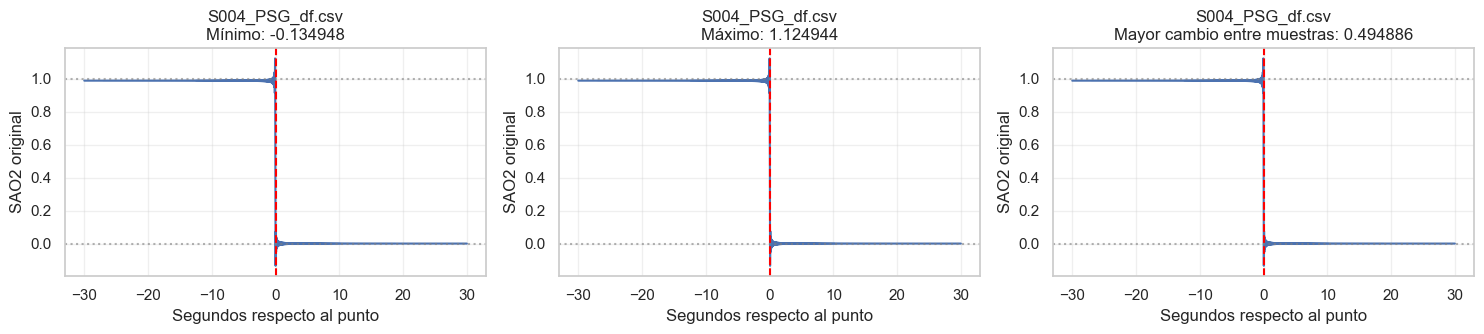


Inspeccionando SAO2: S006_PSG_df.csv


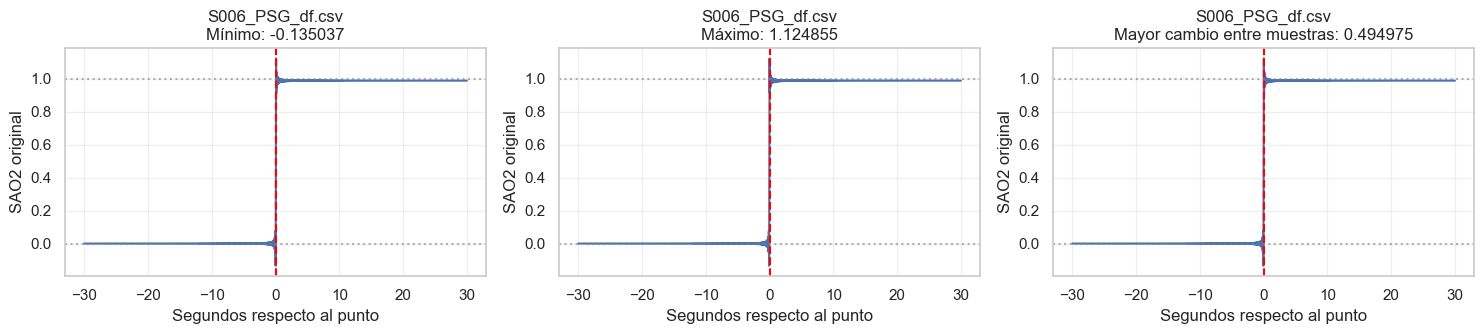


ESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS


,count,mean,std,min,1%,50%,99%,max,archivo,negativos,mayores_1,ceros_exactos
0,2413100.0,0.893009,0.079369,-0.134948,0.740000,0.899768,0.980061,1.124944,S004_PSG_df.csv,1458,19,0
1,2403000.0,0.961867,0.094311,-0.135037,0.919763,0.969924,0.989707,1.124855,S006_PSG_df.csv,2470,36,0



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,SAO2,SAO2_anterior
0,S004_PSG_df.csv,Mínimo,238270,9222.70,-0.134948,-0.118288
1,S004_PSG_df.csv,Máximo,238262,9222.62,1.124944,1.069550
2,S004_PSG_df.csv,Mayor cambio entre muestras,238266,9222.66,0.494886,0.772511
3,S006_PSG_df.csv,Mínimo,2006222,27262.22,-0.135037,-0.079650
4,S006_PSG_df.csv,Máximo,2006230,27262.30,1.124855,1.108188
5,S006_PSG_df.csv,Mayor cambio entre muestras,2006226,27262.26,0.494975,0.217356



No se modificaron valores. Los gráficos tienen escalas verticales independientes. Falta contrastar los casos con el procesamiento de origen.


In [108]:
# 2.6.2. Inspección de SAO2

carpeta_revision = Path("/kaggle/working/auditoria")

# Utilizar la auditoría guardada; no recorrer nuevamente todos los CSV.
auditoria_p = pd.read_csv(
    carpeta_revision / "auditoria_pacientes.csv"
)
auditoria_s = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_sao2 = auditoria_s.loc[
    auditoria_s["señal"].eq("SAO2"),
    ["archivo", "minimo", "maximo"],
]

resumen_sao2 = auditoria_p[
    ["archivo", "filas", "ceros_sao2", "sao2_fuera_escala_0_1"]
].merge(rangos_sao2, on="archivo", how="left")

resumen_sao2["fuera_0_1_pct"] = (
    100 * resumen_sao2["sao2_fuera_escala_0_1"]
    / resumen_sao2["filas"]
)

print("RESUMEN GENERAL DE SAO2")
print(
    "Pacientes con muestras fuera de 0–1:",
    int(resumen_sao2["sao2_fuera_escala_0_1"].gt(0).sum()),
)
print(
    "Pacientes con ceros exactos:",
    int(resumen_sao2["ceros_sao2"].gt(0).sum()),
)

# Mostrar los rangos más alejados del intervalo supuesto.
print("\nDIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1")
display(
    resumen_sao2.sort_values(
        "fuera_0_1_pct", ascending=False
    ).head(10).round(5)
)

pacientes_sao2_preferidos = [
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
    "S027_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_sao2 = [
    nombre for nombre in pacientes_sao2_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_sao2:
    nombres_revision_sao2 = [p.name for p in data_files[:3]]

estadisticas_sao2 = []
puntos_revision_sao2 = []

for nombre in nombres_revision_sao2:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando SAO2: {nombre}", flush=True)

    # Solo dos columnas; un paciente por vez.
    datos = pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "SAO2"],
    )

    valores = pd.to_numeric(datos["SAO2"], errors="coerce")
    tiempos = pd.to_numeric(datos["TIMESTAMP"], errors="coerce")
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        continue

    estadisticas = finitos.describe(
        percentiles=[0.01, 0.50, 0.99]
    ).to_dict()
    estadisticas["archivo"] = nombre
    estadisticas["negativos"] = int(finitos.lt(0).sum())
    estadisticas["mayores_1"] = int(finitos.gt(1).sum())
    estadisticas["ceros_exactos"] = int(finitos.eq(0).sum())
    estadisticas_sao2.append(estadisticas)

    # Diferencia absoluta entre muestras consecutivas.
    diferencias = finitos.diff().abs()

    posiciones = {
        "Mínimo": int(finitos.idxmin()),
        "Máximo": int(finitos.idxmax()),
    }

    if diferencias.notna().any():
        posiciones["Mayor cambio entre muestras"] = int(
            diferencias.idxmax()
        )

    fig, axes = plt.subplots(
        1, len(posiciones),
        figsize=(5 * len(posiciones), 3.5),
        squeeze=False,
    )

    for ax, (motivo, posicion) in zip(
        axes[0], posiciones.items()
    ):
        inicio = max(0, posicion - 3000)
        fin = min(len(datos), posicion + 3001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")

        # Referencias de escala; no son reglas de limpieza.
        ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
        ax.axhline(1, color="gray", linestyle=":", alpha=0.6)

        ax.set_title(
            f"{nombre}\n{motivo}: {valores.iloc[posicion]:.6f}"
        )
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("SAO2 original")
        ax.grid(alpha=0.3)

        puntos_revision_sao2.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "SAO2": valores.iloc[posicion],
            "SAO2_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
        })

    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos, diferencias

estadisticas_sao2 = pd.DataFrame(estadisticas_sao2)
puntos_revision_sao2 = pd.DataFrame(puntos_revision_sao2)

print("\nESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS")
display(estadisticas_sao2.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_sao2)

estadisticas_sao2.to_csv(
    carpeta_revision / "revision_estadisticas_sao2.csv",
    index=False,
)
puntos_revision_sao2.to_csv(
    carpeta_revision / "revision_puntos_sao2.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "Los gráficos tienen escalas verticales independientes. "
    "Falta contrastar los casos con el procesamiento de origen."
)

### 2.6.3. Revisión de señales constantes

Se identifican señales constantes durante todo el registro y tramos
prolongados sin cambios, utilizando los resultados de la auditoría general.

Se priorizan S097 y los pacientes con IBI constante. Una señal
numérica y sin nulos puede igualmente carecer de variación útil.

Los tramos constantes no se consideran errores automáticamente:
pueden relacionarse con el registro, el relleno o el procesamiento.
No se modifican ni eliminan señales en esta revisión.

In [109]:
# 2.6.3. Revisión de señales constantes

carpeta_revision = Path("/kaggle/working/auditoria")
auditoria_constantes = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

columnas_detalle = [
    "archivo",
    "señal",
    "filas",
    "minimo",
    "maximo",
    "mayor_tramo_constante_muestras",
    "inicio_tramo_constante_fila",
    "duracion_constante_segundos_100hz",
]

# Porcentaje del registro ocupado por su mayor tramo constante.
auditoria_constantes["mayor_tramo_constante_pct"] = (
    100
    * auditoria_constantes["mayor_tramo_constante_muestras"]
    / auditoria_constantes["filas"]
)

# Constancia en todas las muestras del registro.
constantes_completas = auditoria_constantes.loc[
    auditoria_constantes["mayor_tramo_constante_muestras"].eq(
        auditoria_constantes["filas"]
    )
    & auditoria_constantes["filas"].gt(0)
].copy()

print("SEÑALES CONSTANTES DURANTE TODO EL REGISTRO")
display(
    constantes_completas[
        columnas_detalle + ["mayor_tramo_constante_pct"]
    ].sort_values(["archivo", "señal"])
)

print("\nCANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE")
display(
    constantes_completas.groupby("archivo")
    .size()
    .rename("señales_constantes")
    .reset_index()
)

print("\nDETALLE DE S097")
display(
    auditoria_constantes.loc[
        auditoria_constantes["archivo"].eq("S097_PSG_df.csv"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ].sort_values("señal")
)

print("\nIBI: DIEZ MAYORES TRAMOS CONSTANTES")
display(
    auditoria_constantes.loc[
        auditoria_constantes["señal"].eq("IBI"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ]
    .sort_values("mayor_tramo_constante_pct", ascending=False)
    .head(10)
)

# Umbral exploratorio, no una regla de eliminación.
tramos_prolongados = auditoria_constantes.loc[
    auditoria_constantes[
        "duracion_constante_segundos_100hz"
    ].ge(30)
].copy()

print("\nTRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS")
display(
    tramos_prolongados.groupby("señal")
    .agg(
        pacientes=("archivo", "nunique"),
        mayor_duracion_segundos=(
            "duracion_constante_segundos_100hz", "max"
        ),
    )
    .reset_index()
    .sort_values("pacientes", ascending=False)
)

constantes_completas.to_csv(
    carpeta_revision / "revision_constantes_completas.csv",
    index=False,
)

print(
    "\nNo se modificaron señales. "
    "Una señal completamente constante tendrá desviación estándar "
    "cero en sus epochs, pero eso no explica la causa. "
    "La duración supone continuidad a 100 Hz, "
    "comprobada en la auditoría general."
)

SEÑALES CONSTANTES DURANTE TODO EL REGISTRO


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct



CANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE


,archivo,señales_constantes



DETALLE DE S097


...


IBI: DIEZ MAYORES TRAMOS CONSTANTES


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
285,S017_PSG_df.csv,IBI,2311500,1.031250,1.546875,2272963,38537.0,22729.62,98.332814
415,S086_PSG_df.csv,IBI,2302500,0.390625,1.625000,859552,1442948.0,8595.51,37.331249
25,S002_PSG_df.csv,IBI,1958400,0.531250,1.406250,521017,1437383.0,5210.16,26.604218
363,S083_PSG_df.csv,IBI,2193000,0.375000,1.562500,176074,2016926.0,1760.73,8.028910
311,S019_PSG_df.csv,IBI,2074200,0.515625,1.531250,124935,1949265.0,1249.34,6.023286
181,S008_PSG_df.csv,IBI,2231500,0.437500,1.546875,34829,1790892.0,348.28,1.560789
259,S016_PSG_df.csv,IBI,2250400,0.406250,1.484375,30377,741558.0,303.76,1.349849
155,S007_PSG_df.csv,IBI,2391000,0.359375,1.218750,30040,876712.0,300.39,1.256378
103,S005_PSG_df.csv,IBI,2191300,0.593750,1.218750,24596,478152.0,245.95,1.122439
337,S082_PSG_df.csv,IBI,1980700,0.546875,1.703125,20383,50938.0,203.82,1.029081



TRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS


,señal,pacientes,mayor_duracion_segundos
1,ACC_X,18,672.45
3,ACC_Z,18,402.71
2,ACC_Y,18,1065.00
16,IBI,18,22729.62
4,BVP,16,53.71
23,TEMP,16,61.67
15,HR,16,103.77
11,EDA,16,1479.75
0,ABDOMEN,1,60.28
8,E1,1,68.20



No se modificaron señales. Una señal completamente constante tendrá desviación estándar cero en sus epochs, pero eso no explica la causa. La duración supone continuidad a 100 Hz, comprobada en la auditoría general.


### 2.6.4. Revisión de diferencias en EDA

EDA mide conductancia de la piel (µS según la documentación del dataset). La auditoría general permite comparar los máximos de **todos los archivos disponibles**; un máximo no describe el nivel habitual ni la duración de un episodio. Solo en S002, S004 y S057 (si están disponibles) se inspecciona la trayectoria cruda, el entorno del máximo y del mayor cambio, ACC en ambos momentos y HR/TEMP alrededor del máximo. El máximo y el mayor cambio pueden ocurrir en instantes distintos: no deben interpretarse como un único evento. La vista completa toma un punto por segundo **solo para dibujar**; los cálculos y ventanas locales utilizan todas las muestras.

Un máximo alto o un salto rápido **no demuestra error**: puede reflejar una respuesta real, diferencias entre personas, movimiento, contacto deficiente, saturación o cambio de escala. Coincidencia con ACC aumenta la sospecha de artefacto, pero tampoco lo confirma. La desviación estándar por epoch de 3.3.1 responde otra pregunta: puede ser alta durante un tramo de variación sin contener el máximo global de EDA.

**Casos pendientes de revisión:** `S004_PSG_df.csv` presenta un máximo elevado y un cambio entre muestras que requieren comprobar continuidad y escala. `S057_PSG_df.csv` muestra una subida pronunciada seguida de un descenso prolongado; la ausencia de un cambio evidente en ACC alrededor del punto inspeccionado no descarta un problema de contacto. Son *marcas de revisión*, no errores confirmados ni motivos de exclusión.

Para S004 se añade una vista de los minutos 190–230, alrededor del inicio aparente de la elevación. EDA, movimiento, HR, TEMP y `Sleep_Stage` comparten el eje temporal. La línea en el minuto 210 es una **referencia visual**, no un cambio detectado automáticamente. Las medianas por segundo y la variabilidad de ACC por cinco segundos solo facilitan la visualización; no modifican las muestras ni los epochs.

**Cómo comprobar el patrón:** (1) comparar varios minutos antes, durante y después de cada episodio en la señal EDA completa; distinguir un pico aislado de un cambio sostenido de nivel; (2) contrastar en los mismos timestamps ACC, TEMP y HR, sin tomar la falta de movimiento como prueba de calidad; (3) buscar episodios semejantes en el mismo paciente y comparar su nivel basal y sus percentiles con otros pacientes, comprobando unidades y cobertura. EDA se midió originalmente a 4 Hz y se remuestreó a 100 Hz en DREAMT: filas consecutivas del CSV no son mediciones originales independientes. [Fuente del dataset](https://physionet.org/content/dreamt/2.2.0/).

**Decisión pendiente:** si se confirma una conversión errónea, corregirla desde la fuente y recalcular; si un tramo es claramente defectuoso, invalidar solo EDA en ese tramo y comprobar cuántas muestras válidas quedan por epoch. Si la variación es sostenida y fiable, conservarla. Si persiste la duda, mantener el dato marcado para análisis posterior. **No se recorta ni normaliza EDA por el solo hecho de ser extrema.**


DIEZ MAYORES MÁXIMOS DE EDA


,archivo,minimo,maximo,nulos,infinitos
75,S004_PSG_df.csv,0.102755,53.174881,0,0
335,S082_PSG_df.csv,0.141162,18.233290,0,0
309,S019_PSG_df.csv,0.000000,10.431508,0,0
205,S009_PSG_df.csv,0.036131,9.357702,0,0
413,S086_PSG_df.csv,0.000000,5.090880,0,0
231,S010_PSG_df.csv,0.000000,4.408996,0,0
127,S006_PSG_df.csv,0.379358,4.386958,0,0
49,S003_PSG_df.csv,0.000000,4.054035,0,0
361,S083_PSG_df.csv,0.259065,3.102791,0,0
257,S016_PSG_df.csv,0.000000,2.961862,0,0


Máximos EDA graficables: 18/18 archivos


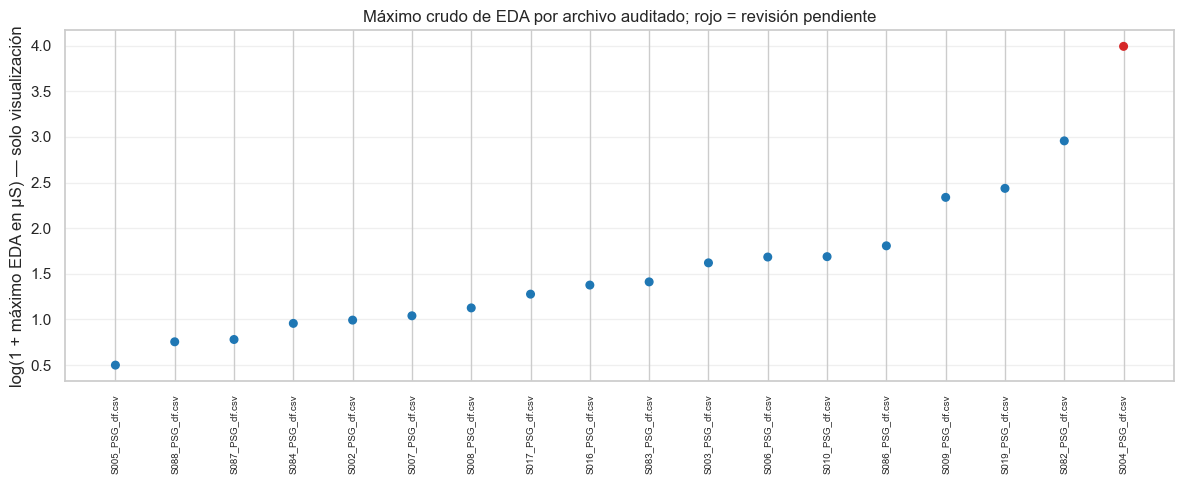


Inspeccionando EDA: S002_PSG_df.csv


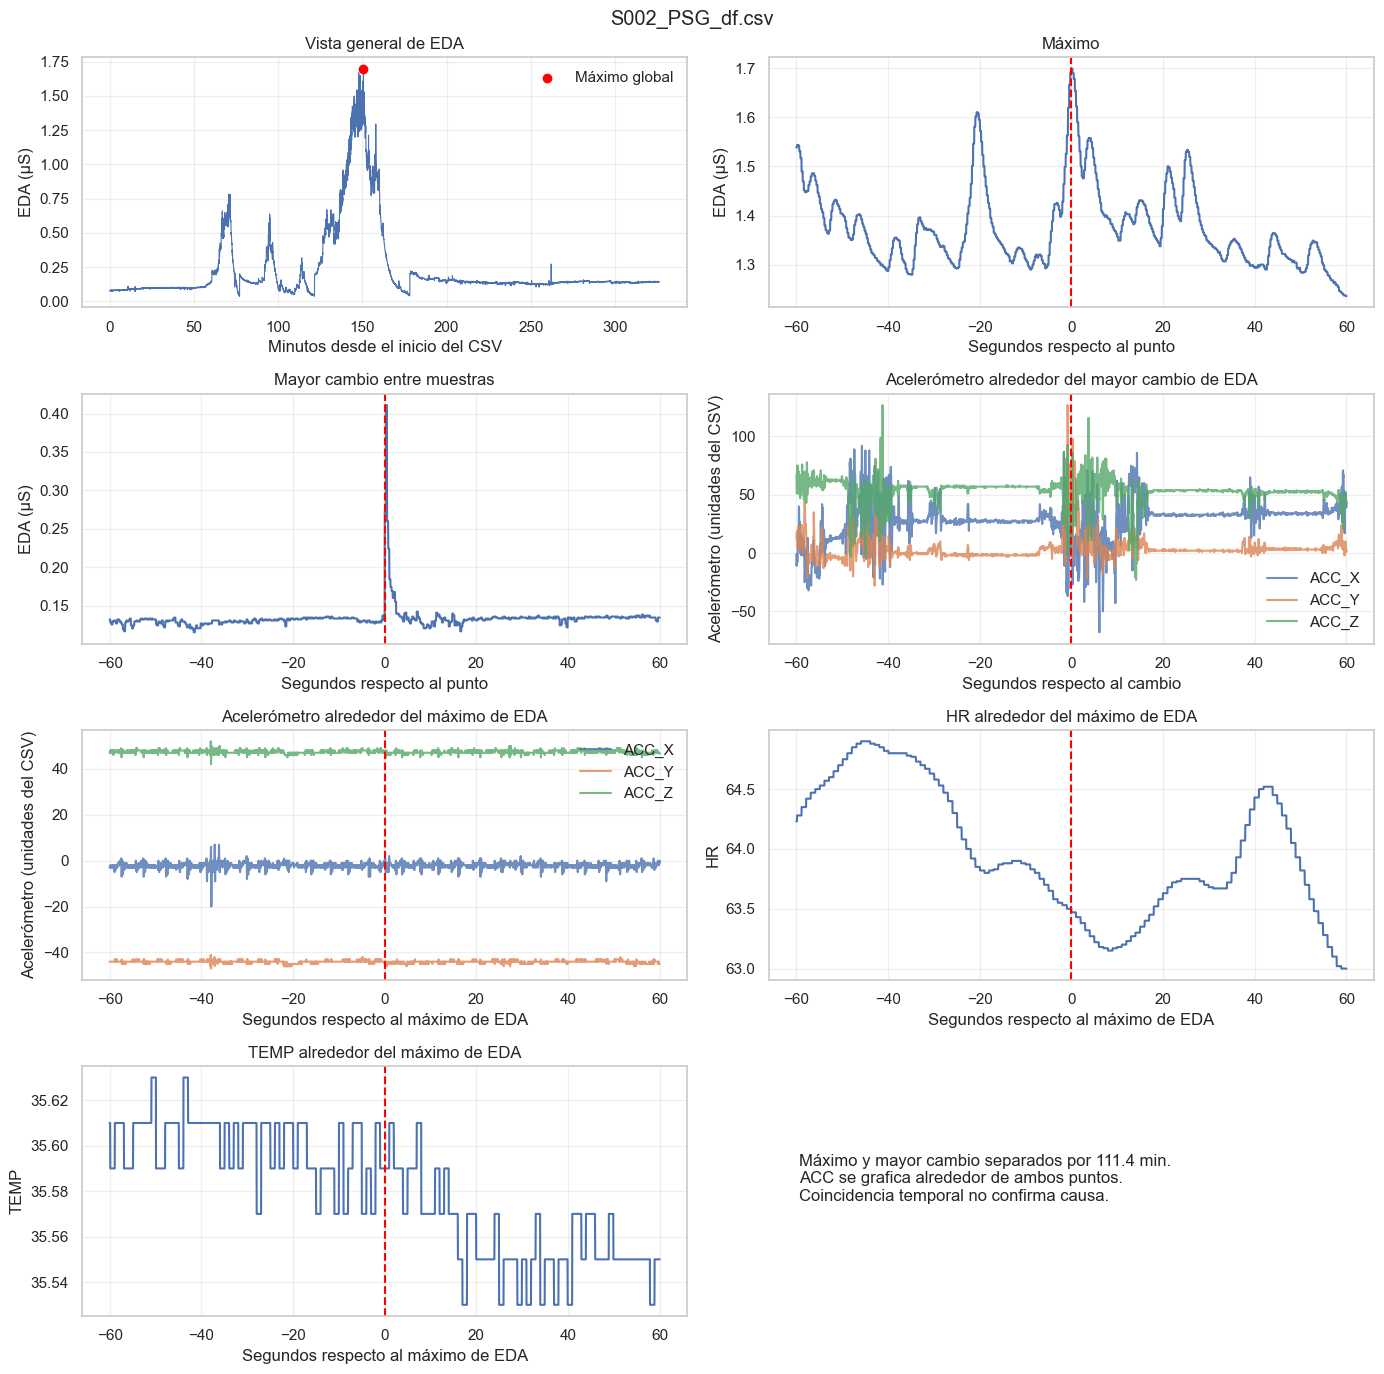


Inspeccionando EDA: S004_PSG_df.csv


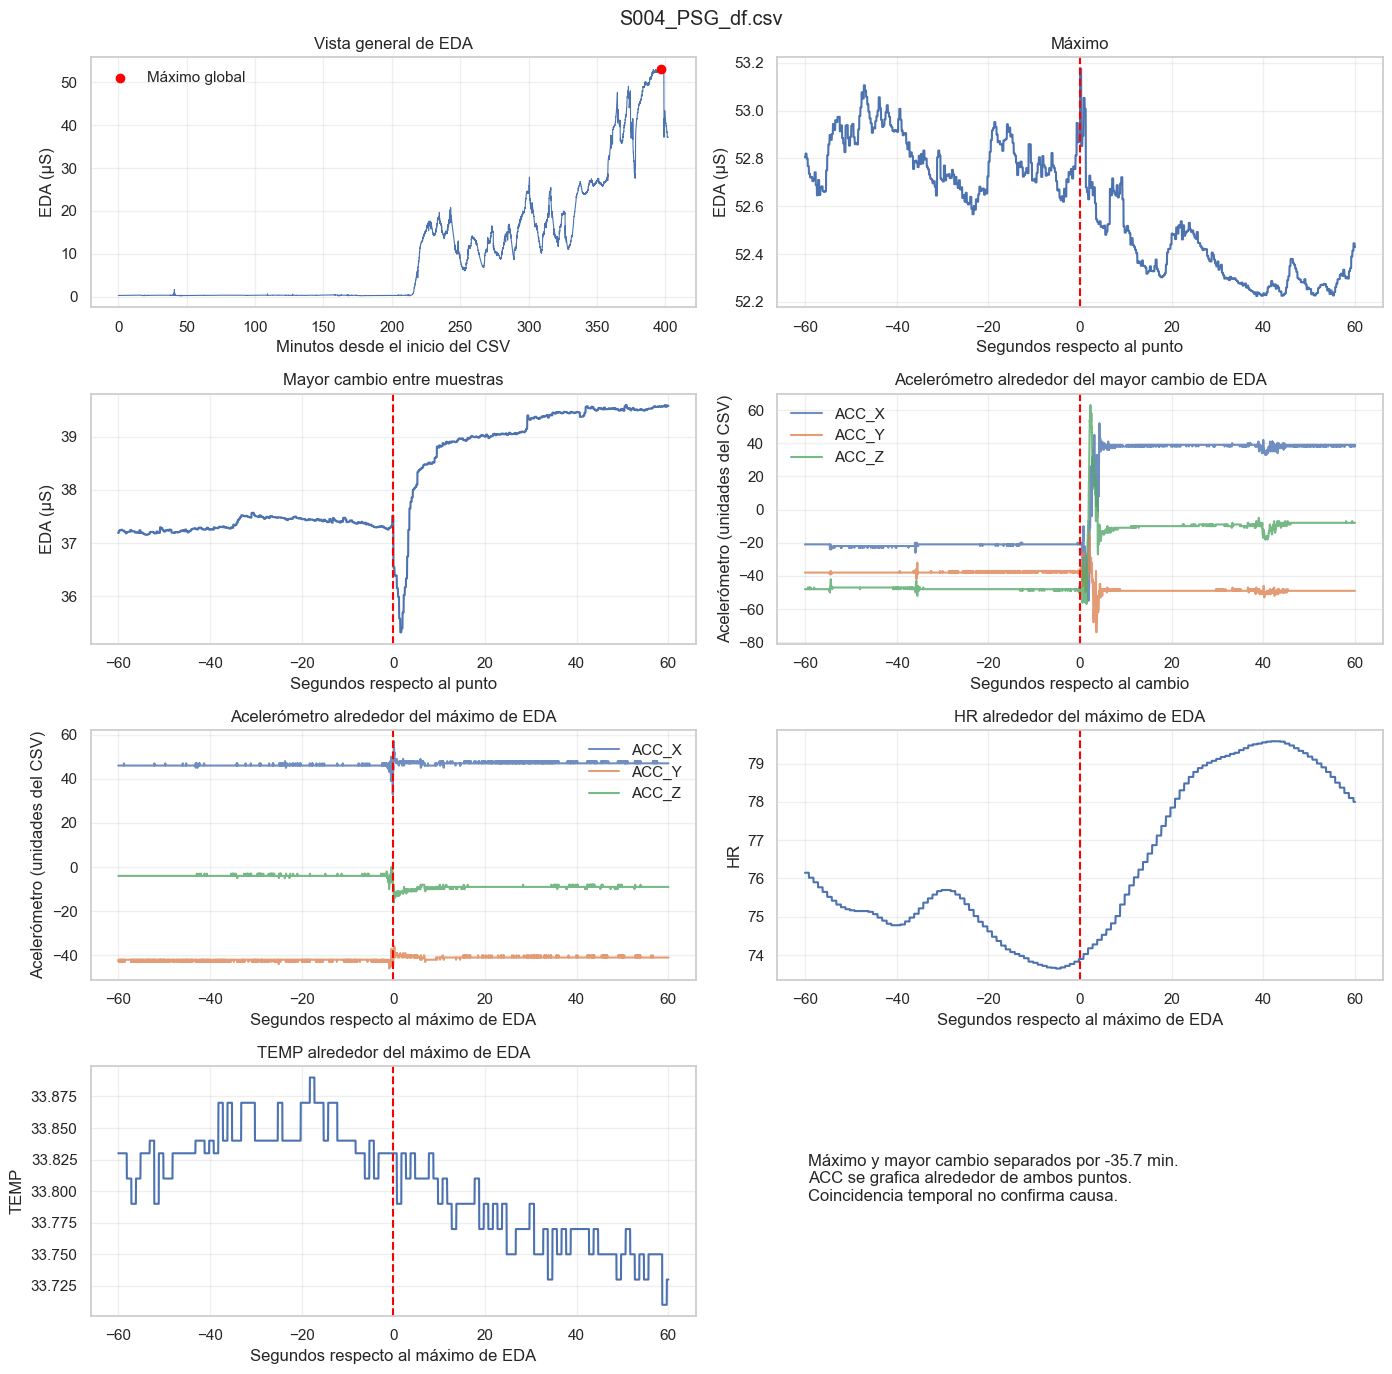

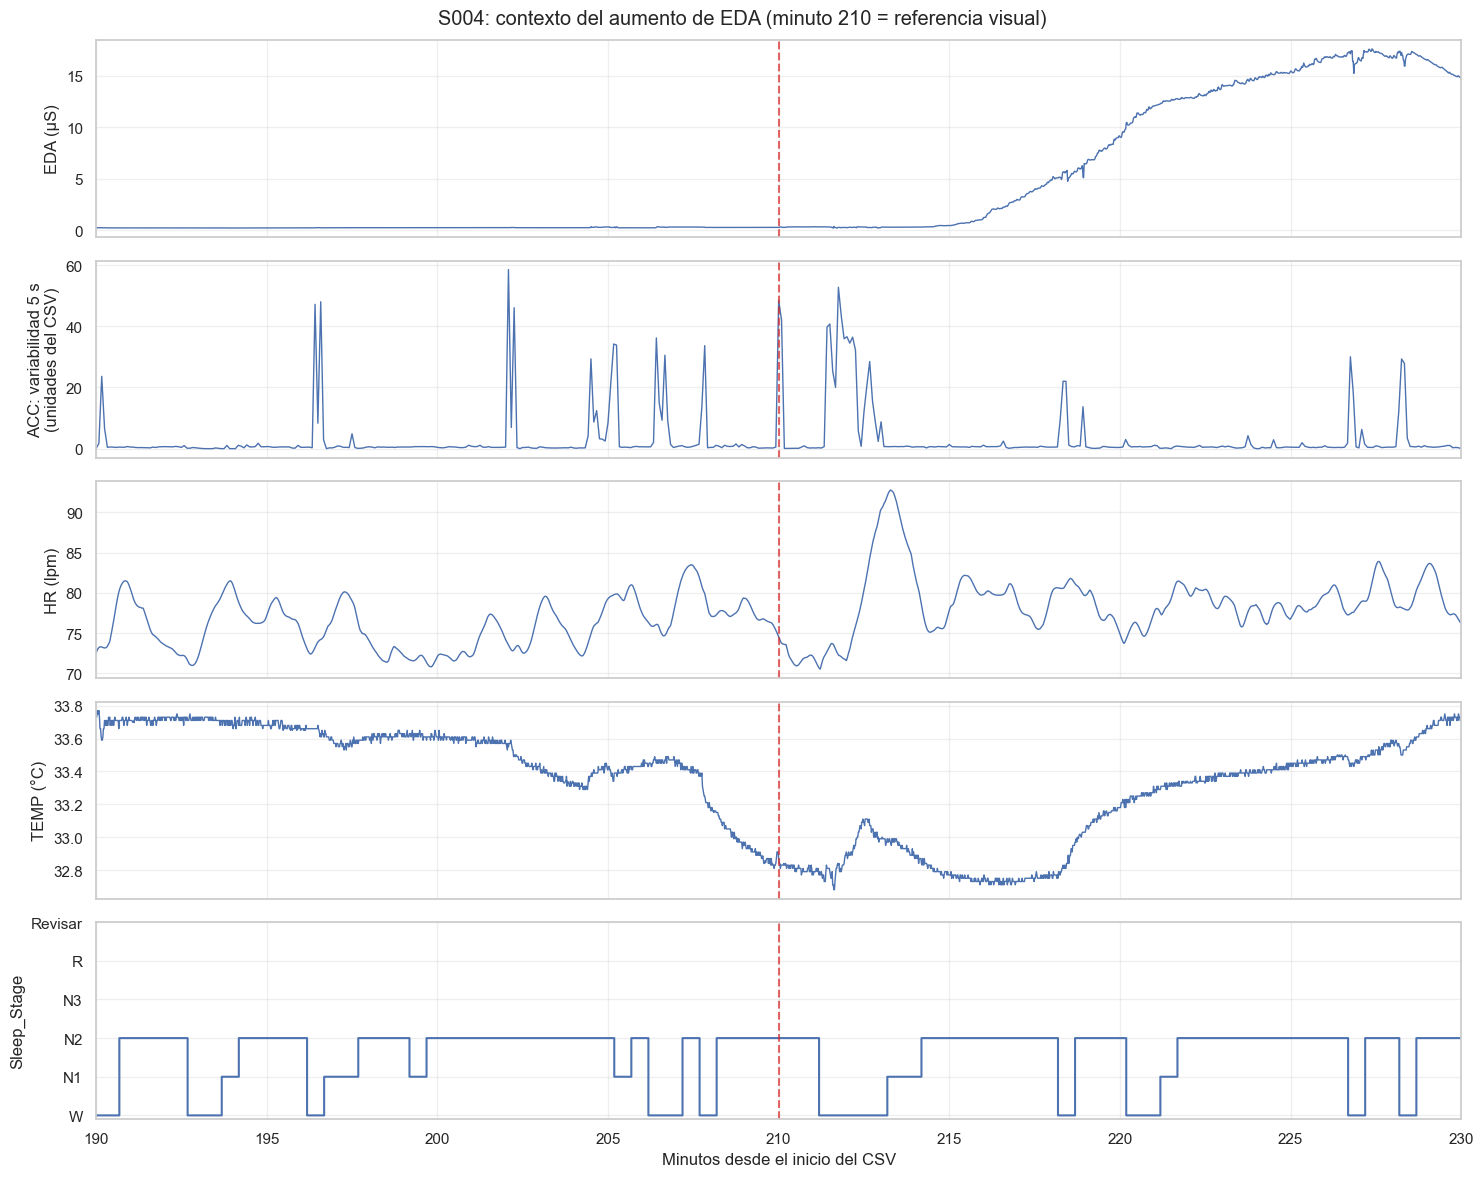


ESTADÍSTICAS DE EDA POR PACIENTE


,count,mean,std,min,1%,25%,50%,75%,99%,max,archivo,valores_negativos,mayor_cambio_absoluto,estado_revision,motivo_revision
0,1958400.0,0.231192,0.26747,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764,S002_PSG_df.csv,0,0.130614,Referencia exploratoria,
1,2413100.0,10.635652,14.41238,0.102755,0.207805,0.280828,0.324385,16.530336,52.520241,53.174881,S004_PSG_df.csv,0,0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...



CASOS DE EDA PENDIENTES DE REVISIÓN


,archivo,min,50%,99%,max,mayor_cambio_absoluto,estado_revision,motivo_revision
1,S004_PSG_df.csv,0.102755,0.324385,52.520241,53.174881,0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,EDA,EDA_anterior,cambio_entre_muestras,estado_revision,motivo_revision
0,S002_PSG_df.csv,Máximo,903539,20915.39,1.698764,1.698090,0.000674,Referencia exploratoria,
1,S002_PSG_df.csv,Mayor cambio entre muestras,1571881,27598.81,0.272808,0.142194,0.130614,Referencia exploratoria,
2,S004_PSG_df.csv,Máximo,2381748,30657.48,53.174881,52.904557,0.270324,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...
3,S004_PSG_df.csv,Mayor cambio entre muestras,2167659,28516.59,36.541969,37.454010,-0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...



No se modificaron valores. La vista general puede ocultar eventos breves por su muestreo visual; los gráficos locales utilizan todas las muestras. Los valores elevados o el movimiento coincidente no confirman por sí solos un error.


In [110]:
# 2.6.4. Inspección de EDA y contexto de movimiento

carpeta_revision = Path("/kaggle/working/auditoria")

auditoria_eda = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_eda = auditoria_eda.loc[
    auditoria_eda["señal"].eq("EDA"),
    ["archivo", "minimo", "maximo", "nulos", "infinitos"],
].sort_values("maximo", ascending=False)

print("DIEZ MAYORES MÁXIMOS DE EDA")
display(rangos_eda.head(10))

# Panorama de todos los pacientes auditados, sin releer señales crudas.
maximos_eda = rangos_eda.copy()
maximos_eda["maximo"] = pd.to_numeric(maximos_eda["maximo"], errors="coerce")
validos_max = np.isfinite(maximos_eda["maximo"]) & maximos_eda["maximo"].ge(0)
print(f"Máximos EDA graficables: {int(validos_max.sum())}/{len(maximos_eda)} archivos")
maximos_eda = maximos_eda.loc[validos_max].sort_values("maximo").reset_index(drop=True)
if not maximos_eda.empty:
    destacados = maximos_eda["archivo"].isin(["S004_PSG_df.csv", "S057_PSG_df.csv"])
    fig, ax = plt.subplots(figsize=(max(12, 0.27 * len(maximos_eda)), 5))
    ax.scatter(np.arange(len(maximos_eda)), np.log1p(maximos_eda["maximo"]),
               c=np.where(destacados, "tab:red", "tab:blue"), s=30)
    ax.set_xticks(np.arange(len(maximos_eda)))
    ax.set_xticklabels(maximos_eda["archivo"], rotation=90, fontsize=7)
    ax.set_ylabel("log(1 + máximo EDA en µS) — solo visualización")
    ax.set_title("Máximo crudo de EDA por archivo auditado; rojo = revisión pendiente")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

pacientes_eda_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S057_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_eda = [
    nombre for nombre in pacientes_eda_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_eda:
    nombres_revision_eda = [p.name for p in data_files[:3]]

columnas_leer = [
    "TIMESTAMP", "EDA", "ACC_X", "ACC_Y", "ACC_Z",
    "HR", "TEMP", "Sleep_Stage",
]
estadisticas_eda = []
puntos_revision_eda = []

for nombre in nombres_revision_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando EDA: {nombre}", flush=True)

    if ruta == sample_file:
        datos = df_sample_eda[columnas_leer].copy()
    else:
        datos = pd.read_csv(ruta, usecols=columnas_leer)

    datos = datos.reset_index(drop=True)

    valores = pd.to_numeric(datos["EDA"], errors="coerce")
    tiempos = pd.to_numeric(
        datos["TIMESTAMP"], errors="coerce"
    )
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        del datos
        continue

    diferencias = finitos.diff()
    diferencias_absolutas = diferencias.abs()

    if not diferencias_absolutas.notna().any():
        print("No hay pares válidos para calcular cambios.")
        del datos
        continue

    posicion_maximo = int(finitos.idxmax())
    posicion_cambio = int(diferencias_absolutas.idxmax())

    resumen = finitos.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).to_dict()
    resumen["archivo"] = nombre
    resumen["valores_negativos"] = int(finitos.lt(0).sum())
    resumen["mayor_cambio_absoluto"] = float(
        diferencias_absolutas.iloc[posicion_cambio]
    )
    estadisticas_eda.append(resumen)

    fig, axes = plt.subplots(4, 2, figsize=(14, 14))

    # 1. Vista general: tomar una muestra por segundo para dibujar.
    # Solo reduce los puntos del gráfico; no cambia los datos analizados.
    posiciones_vista = np.arange(0, len(datos), 100)

    axes[0, 0].plot(
        (tiempos.iloc[posiciones_vista] - tiempos.iloc[0]) / 60,
        valores.iloc[posiciones_vista],
        linewidth=0.8,
    )
    axes[0, 0].scatter(
        (tiempos.iloc[posicion_maximo] - tiempos.iloc[0]) / 60,
        valores.iloc[posicion_maximo],
        color="red",
        label="Máximo global",
        zorder=5,
    )
    axes[0, 0].set_title("Vista general de EDA")
    axes[0, 0].set_xlabel("Minutos desde el inicio del CSV")
    axes[0, 0].set_ylabel("EDA (µS)")
    axes[0, 0].legend()

    # 2 y 3. Hasta 60 segundos alrededor del máximo y mayor cambio.
    for ax, motivo, posicion in [
        (axes[0, 1], "Máximo", posicion_maximo),
        (axes[1, 0], "Mayor cambio entre muestras", posicion_cambio),
    ]:
        inicio = max(0, posicion - 6000)
        fin = min(len(datos), posicion + 6001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(motivo)
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("EDA (µS)")

        puntos_revision_eda.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "EDA": valores.iloc[posicion],
            "EDA_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
            "cambio_entre_muestras": diferencias.iloc[posicion],
        })

    # 4. Acelerómetro en el MISMO intervalo del mayor cambio de EDA.
    inicio = max(0, posicion_cambio - 6000)
    fin = min(len(datos), posicion_cambio + 6001)
    tiempo_relativo = (
        tiempos.iloc[inicio:fin] - tiempos.iloc[posicion_cambio]
    )

    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[1, 1].plot(
            tiempo_relativo,
            pd.to_numeric(
                datos[eje].iloc[inicio:fin], errors="coerce"
            ),
            label=eje,
            alpha=0.8,
        )

    axes[1, 1].axvline(0, color="red", linestyle="--")
    axes[1, 1].set_title(
        "Acelerómetro alrededor del mayor cambio de EDA"
    )
    axes[1, 1].set_xlabel("Segundos respecto al cambio")
    axes[1, 1].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[1, 1].legend()

    # ACC, HR y TEMP en la MISMA ventana temporal del máximo de EDA.
    inicio_max = max(0, posicion_maximo - 6000)
    fin_max = min(len(datos), posicion_maximo + 6001)
    tiempo_max = tiempos.iloc[inicio_max:fin_max] - tiempos.iloc[posicion_maximo]
    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[2, 0].plot(
            tiempo_max, pd.to_numeric(datos[eje].iloc[inicio_max:fin_max], errors="coerce"),
            label=eje, alpha=0.8,
        )
    axes[2, 0].axvline(0, color="red", linestyle="--")
    axes[2, 0].set_title("Acelerómetro alrededor del máximo de EDA")
    axes[2, 0].set_xlabel("Segundos respecto al máximo de EDA")
    axes[2, 0].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[2, 0].legend()
    for ax, senal in [(axes[2, 1], "HR"), (axes[3, 0], "TEMP")]:
        ax.plot(
            tiempo_max,
            pd.to_numeric(datos[senal].iloc[inicio_max:fin_max], errors="coerce"),
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(f"{senal} alrededor del máximo de EDA")
        ax.set_xlabel("Segundos respecto al máximo de EDA")
        ax.set_ylabel(senal)
    separacion_minutos = (
        tiempos.iloc[posicion_cambio] - tiempos.iloc[posicion_maximo]
    ) / 60
    axes[3, 1].axis("off")
    axes[3, 1].text(
        0.05, 0.65,
        f"Máximo y mayor cambio separados por {separacion_minutos:.1f} min.\n"
        "ACC se grafica alrededor de ambos puntos.\n"
        "Coincidencia temporal no confirma causa.",
        transform=axes[3, 1].transAxes, va="top",
    )

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    fig.suptitle(nombre)
    plt.tight_layout()
    plt.show()

    if nombre == "S004_PSG_df.csv":
        # Zoom exploratorio: reutiliza el CSV ya cargado y no cambia el ETL.
        minuto_inicio, minuto_fin = 190, 230
        minuto_relativo = (tiempos - tiempos.iloc[0]) / 60
        ventana = datos.loc[minuto_relativo.between(minuto_inicio, minuto_fin)].copy()
        if ventana.empty:
            print("S004: no hay muestras en los minutos 190–230.")
        else:
            ventana["segundo"] = np.floor(
                tiempos.loc[ventana.index] - tiempos.iloc[0]
            ).astype(int)
            for senal in ["EDA", "HR", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]:
                ventana[senal] = pd.to_numeric(ventana[senal], errors="coerce")
            por_segundo = ventana.groupby("segundo")[["EDA", "HR", "TEMP"]].median()
            acc_5s = ventana.groupby(ventana["segundo"] // 5)[
                ["ACC_X", "ACC_Y", "ACC_Z"]
            ].std(ddof=0)
            movimiento = np.sqrt(acc_5s.pow(2).sum(axis=1, min_count=1))
            etapas = ventana.groupby("segundo")["Sleep_Stage"].first()
            orden_etapas = ["W", "N1", "N2", "N3", "R", "Revisar"]
            etapas = etapas.where(etapas.isin(orden_etapas[:-1]), "Revisar")
            etapas_num = etapas.map({etapa: i for i, etapa in enumerate(orden_etapas)})

            fig, ejes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
            for ax, senal, unidad in [
                (ejes[0], "EDA", "EDA (µS)"),
                (ejes[2], "HR", "HR (lpm)"),
                (ejes[3], "TEMP", "TEMP (°C)"),
            ]:
                ax.plot(por_segundo.index / 60, por_segundo[senal], linewidth=1)
                ax.set_ylabel(unidad)
            ejes[1].plot(movimiento.index * 5 / 60, movimiento, linewidth=1)
            ejes[1].set_ylabel("ACC: variabilidad 5 s\n(unidades del CSV)")
            ejes[4].step(etapas_num.index / 60, etapas_num, where="post")
            ejes[4].set_yticks(range(len(orden_etapas)), orden_etapas)
            ejes[4].set_ylabel("Sleep_Stage")
            ejes[4].set_xlabel("Minutos desde el inicio del CSV")
            for ax in ejes:
                ax.axvline(210, color="tab:red", linestyle="--", alpha=0.7)
                ax.set_xlim(minuto_inicio, minuto_fin)
                ax.grid(alpha=0.3)
            fig.suptitle("S004: contexto del aumento de EDA (minuto 210 = referencia visual)")
            plt.tight_layout()
            plt.show()
            del ventana, por_segundo, acc_5s, movimiento, etapas, etapas_num

    del datos, valores, tiempos, finitos
    del diferencias, diferencias_absolutas

estadisticas_eda = pd.DataFrame(estadisticas_eda)
puntos_revision_eda = pd.DataFrame(puntos_revision_eda)

# Marcas exploratorias: no alteran EDA ni la inclusión de epochs.
motivos_revision_eda = {
    "S004_PSG_df.csv": "Máximo elevado y cambio entre muestras: comprobar continuidad y escala",
    "S057_PSG_df.csv": "Subida y descenso prolongados: comprobar continuidad y contacto",
}
for tabla in (estadisticas_eda, puntos_revision_eda):
    if not tabla.empty:
        tabla["estado_revision"] = np.where(
            tabla["archivo"].isin(motivos_revision_eda),
            "Pendiente de revisión", "Referencia exploratoria",
        )
        tabla["motivo_revision"] = tabla["archivo"].map(
            motivos_revision_eda
        ).fillna("")

print("\nESTADÍSTICAS DE EDA POR PACIENTE")
display(estadisticas_eda.round(6))
print("\nCASOS DE EDA PENDIENTES DE REVISIÓN")
if not estadisticas_eda.empty:
    display(estadisticas_eda.loc[
        estadisticas_eda["estado_revision"].eq("Pendiente de revisión"),
        ["archivo", "min", "50%", "99%", "max",
         "mayor_cambio_absoluto", "estado_revision", "motivo_revision"],
    ])

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_eda)

estadisticas_eda.to_csv(
    carpeta_revision / "revision_estadisticas_eda.csv",
    index=False,
)
puntos_revision_eda.to_csv(
    carpeta_revision / "revision_puntos_eda.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "La vista general puede ocultar eventos breves por su muestreo "
    "visual; los gráficos locales utilizan todas las muestras. "
    "Los valores elevados o el movimiento coincidente no confirman "
    "por sí solos un error."
)

# 3. Preparación y evaluación del dataset de epochs
Preparamos una tabla con una fila por paciente y epoch completo de 30 segundos.

- Se verifica continuidad a 100 Hz y se infiere la alineación a partir de los cambios entre etapas válidas.
- Se definen los epochs antes de filtrar filas. Se contabilizan los fragmentos incompletos.
- Se conservan las señales originales, incluidos sus posibles nulos. El recorte por percentiles y la interpolación automática están desactivados.
- Las anotaciones respiratorias no se utilizan como predictores; sí se conservan las señales fisiológicas respiratorias.
- Se calculan media, desviación estándar, mediana y cobertura de cada señal por epoch.

La documentación de DREAMT indica que la preparación (`P`) aparece como `W` en los archivos de 100 Hz. Por eso, `W` por sí solo no permite distinguir preparación de vigilia real.

Fuente del dataset: [DREAMT 2.2.0](https://physionet.org/content/dreamt/2.2.0/).

In [111]:
# Funciones Modulares de Limpieza a 100 Hz

def clean_sleep_stages(df):
    """Conserva filas, orden y etiquetas antes del agrupamiento temporal."""
    if "Sleep_Stage" not in df.columns:
        raise ValueError("Falta la columna Sleep_Stage.")

    return df.copy()


def clean_sao2(df):
    """
    Conserva SAO2 original, incluidos sus posibles faltantes.

    No aplica umbrales ni interpolación automática mientras
    esas reglas no estén justificadas.
    """
    return df

def clean_outliers_wearable_psg(df):
    """
    Conserva las señales originales.

    El recorte por percentiles y el relleno de nulos quedan
    desactivados hasta justificar sus reglas con evidencia.
    """
    return df

def run_etl_pipeline(df):
    """Prepara señales para predecir la etapa de sueño."""
    df = clean_sleep_stages(df)
    df = clean_sao2(df)
    df = clean_outliers_wearable_psg(df)
    return df

## 3.1. Generación de la primera versión del dataset de epochs

Se procesan ventanas de 30 segundos alineadas por paciente. Los registros originales no se modifican. Los epochs Missing aislados se completan solo cuando los dos epochs vecinos son puros, contiguos y tienen la misma etapa; la imputación queda marcada. Los demás epochs sin etiqueta válida no entran al dataset supervisado.

S027 y S048 se analizan por tramos: se recuperan solo segmentos con tiempo continuo y al menos dos transiciones válidas de la misma fase de 3000 muestras. Las zonas ambiguas permanecen excluidas. S097 conserva su exclusión provisional por señales PSG constantes. SAO2 e IBI permanecen fuera de las características.

El dataset consolidado, la auditoría y el detalle de epochs rechazados se guardan en etl_v1/ local o /kaggle/working/etl_v1/ en Kaggle. Si ya existen y coinciden los archivos fuente, la configuración y la versión de estas reglas, se **cargan los tres CSV** sin rehacer el ETL. Un manifiesto pequeño identifica la caché; una salida antigua sin manifiesto se recalcula una vez para establecerla. Para reconstruir deliberadamente, cambiar FORZAR_RECALCULO_ETL a True. En Kaggle, /kaggle/working persiste durante la sesión, pero una sesión nueva necesita recuperar esos archivos como salida o dataset antes de reutilizarlos. La sección 3.2 explica y resume las decisiones.


In [112]:
# 3.1. Dataset de epochs con control de etiquetas y alineación

es_kaggle = os.name != "nt" and (
    "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/input").exists()
)
carpeta_etl = Path("/kaggle/working/etl_v1") if es_kaggle else Path.cwd() / "etl_v1"
carpeta_etl.mkdir(parents=True, exist_ok=True)
print("Carpeta de salida ETL:", carpeta_etl.resolve())

if not data_files:
    raise ValueError("No se encontraron archivos de pacientes.")
if len({p.name for p in data_files}) != len(data_files):
    raise ValueError("Hay nombres de archivos duplicados.")

window_size = 3000
etapas_validas = ["W", "N1", "N2", "N3", "R"]
wearable_cols = ["BVP", "HR", "EDA", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]
psg_cols = [
    "C4-M1", "F4-M1", "O2-M1", "Fp1-O2", "T3 - CZ", "CZ - T4",
    "CHIN", "E1", "E2", "ECG", "LAT", "RAT", "SNORE", "PTAF",
    "FLOW", "THORAX", "ABDOMEN",
]
senales_modelo = wearable_cols + psg_cols
columnas_leer = ["TIMESTAMP", "Sleep_Stage", *senales_modelo]
exclusiones_fijas = {
    "S097_PSG_df.csv": "Señales PSG constantes durante todo el registro",
}
pacientes_alineacion = {"S027_PSG_df.csv", "S048_PSG_df.csv"}


def fragmentos_verificados(df):
    """Recuperar solo tramos continuos con dos cambios válidos de fase estable."""
    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce").to_numpy()
    saltos = ~np.isclose(np.diff(tiempos), 0.01, atol=1e-6, rtol=0)
    cortes = np.r_[0, np.flatnonzero(saltos) + 1, len(df)]
    encontrados = []

    for inicio_cont, fin_cont in zip(cortes[:-1], cortes[1:]):
        if fin_cont - inicio_cont < 2 * window_size:
            continue
        if not np.isfinite(tiempos[inicio_cont:fin_cont]).all():
            continue

        etapas = df["Sleep_Stage"].iloc[inicio_cont:fin_cont].reset_index(drop=True)
        anterior = etapas.shift()
        cambios = (
            etapas.isin(etapas_validas)
            & anterior.isin(etapas_validas)
            & etapas.ne(anterior)
        )
        posiciones = np.flatnonzero(cambios.to_numpy())
        if len(posiciones) < 2:
            continue
        restos = posiciones % window_size
        limites = np.r_[0, np.flatnonzero(np.diff(restos) != 0) + 1, len(posiciones)]

        for indice, (desde, hasta) in enumerate(zip(limites[:-1], limites[1:])):
            if hasta - desde < 2:
                continue
            inicio = inicio_cont + int(posiciones[desde])
            fin = inicio_cont + int(posiciones[hasta - 1]) + window_size
            if indice + 1 < len(limites) - 1:
                fin = min(fin, inicio_cont + int(posiciones[limites[indice + 1]]))
            fin = min(fin, fin_cont)
            if fin - inicio >= window_size:
                encontrados.append((inicio, fin))

    return encontrados


def resumir_fragmento(datos, inicio_epoch, timestamp_inicio):
    """Agregar epochs completos; imputar solo un Missing aislado y flanqueado."""
    epoch_ids, completos, diagnostico = definir_epochs(datos)
    trabajo = datos.loc[completos].copy()
    trabajo["epoch"] = epoch_ids[completos] + inicio_epoch
    grupos = trabajo.groupby("epoch", sort=True)
    etapas_originales = grupos["Sleep_Stage"].first()
    validas_originales = (
        grupos["Sleep_Stage"].nunique(dropna=False).eq(1)
        & etapas_originales.isin(etapas_validas)
    )
    es_missing = trabajo["Sleep_Stage"].eq("Missing") | trabajo["Sleep_Stage"].isna()
    missing_por_epoch = es_missing.groupby(trabajo["epoch"]).sum()
    missing_completo = missing_por_epoch.eq(window_size)
    imputados = set()
    vecinos_distintos = set()

    for epoch in missing_completo.index[missing_completo]:
        anterior, siguiente = epoch - 1, epoch + 1
        if anterior not in etapas_originales.index or siguiente not in etapas_originales.index:
            continue
        if not (validas_originales.loc[anterior] and validas_originales.loc[siguiente]):
            continue
        etapa_anterior = etapas_originales.loc[anterior]
        etapa_siguiente = etapas_originales.loc[siguiente]
        if etapa_anterior == etapa_siguiente:
            trabajo.loc[trabajo["epoch"].eq(epoch), "Sleep_Stage"] = etapa_anterior
            imputados.add(epoch)
        else:
            vecinos_distintos.add(epoch)

    grupos = trabajo.groupby("epoch", sort=True)
    estadisticas = grupos[senales_modelo].agg(["mean", "std", "median", "count"])
    estadisticas.columns = [
        f"{senal}_{'n_valid' if operacion == 'count' else operacion}"
        for senal, operacion in estadisticas.columns
    ]
    for senal in senales_modelo:
        estadisticas[f"{senal}_missing_frac"] = (
            1 - estadisticas[f"{senal}_n_valid"] / window_size
        )

    etiquetas_validas = trabajo["Sleep_Stage"].where(
        trabajo["Sleep_Stage"].isin(etapas_validas)
    )
    conteos = (
        etiquetas_validas.groupby(trabajo["epoch"])
        .value_counts().unstack(fill_value=0)
        .reindex(index=estadisticas.index, columns=etapas_validas, fill_value=0)
        .fillna(0)
    )
    mayor_conteo = conteos.max(axis=1)
    objetivo = conteos.idxmax(axis=1).where(mayor_conteo.gt(0))
    conservar = mayor_conteo.eq(window_size)

    estadisticas["TIMESTAMP"] = grupos["TIMESTAMP"].first()
    estadisticas["tiempo_relativo_segundos"] = (
        estadisticas["TIMESTAMP"] - timestamp_inicio
    )
    estadisticas["Sleep_Stage"] = objetivo
    estadisticas["porcentaje_pureza"] = mayor_conteo / window_size
    estadisticas["porcentaje_pureza_original"] = (
        mayor_conteo - pd.Series(
            {epoch: window_size for epoch in imputados}, dtype="int64"
        ).reindex(mayor_conteo.index, fill_value=0)
    ) / window_size
    estadisticas["etiqueta_imputada"] = estadisticas.index.isin(imputados)

    descartados = pd.DataFrame({
        "epoch": estadisticas.index,
        "porcentaje_pureza": estadisticas["porcentaje_pureza"].to_numpy(),
        "muestras_con_etiqueta_valida": conteos.sum(axis=1).to_numpy(),
    }).loc[~conservar.to_numpy()].copy()
    descartados["motivo"] = "No contiene 3000 muestras de una misma etapa válida"
    descartados.loc[
        descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing aislado entre etapas distintas: decisión pendiente"
    descartados.loc[
        descartados["epoch"].isin(missing_completo.index[missing_completo])
        & ~descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing sin dos vecinos válidos iguales o tramo prolongado"

    conservados = estadisticas.loc[conservar].reset_index()
    resumen = {
        "desplazamiento_segmento": diagnostico["desplazamiento"],
        "epochs_completos": diagnostico["epochs_completos"],
        "filas_fragmento_inicial": diagnostico["filas_fragmento_inicial"],
        "filas_fragmento_final": diagnostico["filas_fragmento_final"],
        "epochs_descartados_por_pureza": int((~conservar).sum()),
        "epochs_conservados": len(conservados),
        "epochs_etiqueta_imputada": len(imputados),
        "epochs_missing_no_imputados": int(missing_por_epoch.gt(0).sum()) - len(imputados),
        "epochs_missing_vecinos_distintos": len(vecinos_distintos),
    }
    return conservados, descartados, resumen


# Reutilizar una salida validada cuando las fuentes y reglas no cambiaron.
FORZAR_RECALCULO_ETL = False
ETL_CACHE_VERSION = 2  # Incrementar si cambia la lógica de construcción.
rutas_etl = {
    "dataset": carpeta_etl / "dataset_epochs_v1.csv",
    "auditoria": carpeta_etl / "auditoria_epochs.csv",
    "descartados": carpeta_etl / "epochs_descartados.csv",
}
ruta_manifiesto = carpeta_etl / "manifest_etl_v1.json"
firma_etl = {
    "version": ETL_CACHE_VERSION,
    "window_size": window_size,
    "senales_modelo": senales_modelo,
    "exclusiones_fijas": exclusiones_fijas,
    "pacientes_alineacion": sorted(pacientes_alineacion),
    "fuentes": [
        {
            "archivo": ruta.name,
            "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(data_files, key=lambda p: p.name)
    ],
}

def validar_resultado_etl(df_epochs_all, auditoria_epochs, epochs_descartados):
    """Comprobar esquema, trazabilidad y orden antes de usar o guardar."""
    columnas_esperadas = {
        "patient_id", "epoch", "TIMESTAMP", "Sleep_Stage",
        "porcentaje_pureza", "etiqueta_imputada",
    }
    for senal in senales_modelo:
        columnas_esperadas.update(
            f"{senal}_{sufijo}"
            for sufijo in ("mean", "std", "median", "n_valid", "missing_frac")
        )
    faltantes = columnas_esperadas.difference(df_epochs_all.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas del ETL: {sorted(faltantes)}")
    if set(auditoria_epochs["archivo"]) != {ruta.name for ruta in data_files}:
        raise ValueError("Los archivos auditados no coinciden con los detectados.")
    if len(auditoria_epochs) != len(data_files):
        raise ValueError("La auditoría no incluye todos los archivos.")
    if auditoria_epochs["archivo"].duplicated().any():
        raise ValueError("Hay archivos duplicados en la auditoría.")
    if auditoria_epochs["patient_id"].duplicated().any():
        raise ValueError("Hay identificadores de paciente duplicados.")

    procesados = auditoria_epochs.loc[
        auditoria_epochs["estado"].isin(["procesado", "procesado_parcial"])
    ].copy()
    if not (
        procesados["filas_originales"].eq(
            procesados["filas_excluidas_alineacion"]
            + procesados["filas_fragmento_inicial"]
            + procesados["epochs_completos"] * window_size
            + procesados["filas_fragmento_final"]
        )
    ).all():
        raise ValueError("Las filas no cuadran con segmentos, epochs y fragmentos.")
    if not procesados["epochs_completos"].eq(
        procesados["epochs_descartados_por_pureza"]
        + procesados["epochs_conservados"]
    ).all():
        raise ValueError("Los epochs completos no cuadran con conservados y descartados.")
    if int(procesados["epochs_descartados_por_pureza"].sum()) != len(epochs_descartados):
        raise ValueError("La auditoría no coincide con los epochs descartados.")

    conservados_por_paciente = df_epochs_all.groupby("patient_id").size()
    if not procesados["epochs_conservados"].eq(
        procesados["patient_id"].map(conservados_por_paciente).fillna(0)
    ).all():
        raise ValueError("La auditoría no coincide con el dataset consolidado.")
    if df_epochs_all.empty or df_epochs_all.duplicated(["patient_id", "epoch"]).any():
        raise ValueError("Dataset vacío o claves patient_id/epoch duplicadas.")
    if not df_epochs_all["Sleep_Stage"].isin(etapas_validas).all():
        raise ValueError("Hay etiquetas inválidas en el dataset final.")

    df_epochs_all = df_epochs_all.sort_values(
        ["patient_id", "epoch"]
    ).reset_index(drop=True)
    if not pd.MultiIndex.from_frame(
        df_epochs_all[["patient_id", "epoch"]]
    ).is_monotonic_increasing:
        raise ValueError("Los epochs no quedaron ordenados por paciente.")

    return df_epochs_all

cache_valida = False
if not FORZAR_RECALCULO_ETL and ruta_manifiesto.exists() and all(
    ruta.exists() for ruta in rutas_etl.values()
):
    try:
        with ruta_manifiesto.open(encoding="utf-8") as archivo_manifiesto:
            manifiesto = json.load(archivo_manifiesto)
        if manifiesto.get("firma") != firma_etl:
            raise ValueError("Las fuentes o reglas del ETL cambiaron")
        df_epochs_all = pd.read_csv(rutas_etl["dataset"], low_memory=False)
        auditoria_epochs = pd.read_csv(rutas_etl["auditoria"], low_memory=False)
        epochs_descartados = pd.read_csv(rutas_etl["descartados"], low_memory=False)
        if len(df_epochs_all) != manifiesto.get("epochs_conservados"):
            raise ValueError("El tamaño del dataset no coincide con el manifiesto")
        df_epochs_all = validar_resultado_etl(
            df_epochs_all, auditoria_epochs, epochs_descartados
        )
        cache_valida = True
        print("ETL cargado desde CSV existente:", rutas_etl["dataset"])
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché no utilizable ({error}); se recalculará el ETL.")

if not cache_valida:
    if not FORZAR_RECALCULO_ETL:
        print("Sin caché validada; se generarán los epochs una vez.")
    resultados_epochs = []
    resumen_temporal = []
    exclusiones_epochs = []

    for numero, file_path in enumerate(data_files, start=1):
        patient_id = extract_patient_id(file_path)
        print(f"[{numero}/{len(data_files)}] {file_path.name}", flush=True)

        if file_path.name in exclusiones_fijas:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "estado": "excluido", "motivo_exclusion": exclusiones_fijas[file_path.name],
                "continuidad_temporal": "no evaluada",
            })
            continue

        df_completo = pd.read_csv(file_path, usecols=columnas_leer, low_memory=False)
        total_filas = len(df_completo)
        timestamp_inicio = df_completo["TIMESTAMP"].iloc[0]
        if file_path.name in pacientes_alineacion:
            fragmentos = fragmentos_verificados(df_completo)
        else:
            fragmentos = [(0, total_filas)]

        if not fragmentos:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "filas_originales": total_filas, "estado": "excluido",
                "motivo_exclusion": "Sin segmentos de alineación verificable",
                "continuidad_temporal": "no verificable",
                "segmentos_recuperados": 0,
                "filas_excluidas_alineacion": total_filas,
            })
            del df_completo
            continue

        partes = []
        acumulado = {
            clave: 0 for clave in [
                "epochs_completos", "filas_fragmento_inicial", "filas_fragmento_final",
                "epochs_descartados_por_pureza", "epochs_conservados",
                "epochs_etiqueta_imputada", "epochs_missing_no_imputados",
                "epochs_missing_vecinos_distintos",
            ]
        }
        inicio_epoch = 0
        desplazamientos = []
        for inicio, fin in fragmentos:
            fragmento = df_completo.iloc[inicio:fin].copy()
            conservados, descartados, resumen = resumir_fragmento(
                fragmento, inicio_epoch, timestamp_inicio
            )
            inicio_epoch += resumen["epochs_completos"]
            desplazamientos.append(resumen["desplazamiento_segmento"])
            for clave in acumulado:
                acumulado[clave] += resumen[clave]
            partes.append(conservados)
            if not descartados.empty:
                descartados.insert(0, "archivo", file_path.name)
                descartados.insert(0, "patient_id", patient_id)
                exclusiones_epochs.append(descartados)
            del fragmento

        df_epochs = pd.concat(partes, ignore_index=True)
        df_epochs.insert(0, "patient_id", patient_id)
        columnas_float32 = [
            col for col in df_epochs.columns
            if col.endswith(("_mean", "_std", "_median", "_missing_frac"))
        ]
        df_epochs[columnas_float32] = df_epochs[columnas_float32].astype("float32")
        resultados_epochs.append(df_epochs)

        filas_recuperadas = sum(fin - inicio for inicio, fin in fragmentos)
        acumulado.update({
            "patient_id": patient_id, "archivo": file_path.name,
            "filas_originales": total_filas,
            "filas_excluidas_alineacion": total_filas - filas_recuperadas,
            "segmentos_recuperados": len(fragmentos),
            "desplazamientos_segmentos": ";".join(map(str, desplazamientos)),
            "intervalos_filas_recuperados": ";".join(
                f"{inicio}-{fin - 1}" for inicio, fin in fragmentos
            ),
            "estado": "procesado_parcial" if filas_recuperadas < total_filas else "procesado",
            "motivo_exclusion": "",
            "continuidad_temporal": "verificada en segmentos recuperados",
        })
        resumen_temporal.append(acumulado)
        pd.DataFrame(resumen_temporal).to_csv(
            carpeta_etl / "auditoria_epochs.csv", index=False
        )
        print(
            f"  Segmentos: {len(fragmentos)} | Conservados: {len(df_epochs)} | "
            f"Imputados: {acumulado['epochs_etiqueta_imputada']} | "
            f"Descartados: {acumulado['epochs_descartados_por_pureza']}",
            flush=True,
        )
        del df_completo, df_epochs
        gc.collect()

    if not resultados_epochs:
        raise ValueError("No se conservaron pacientes para el dataset final.")

    df_epochs_all = pd.concat(resultados_epochs, ignore_index=True)
    auditoria_epochs = pd.DataFrame(resumen_temporal)
    epochs_descartados = (
        pd.concat(exclusiones_epochs, ignore_index=True)
        if exclusiones_epochs else pd.DataFrame(columns=[
            "patient_id", "archivo", "epoch", "porcentaje_pureza",
            "muestras_con_etiqueta_valida", "motivo",
        ])
    )

    df_epochs_all = validar_resultado_etl(
        df_epochs_all, auditoria_epochs, epochs_descartados
    )
    df_epochs_all.to_csv(rutas_etl["dataset"], index=False)
    auditoria_epochs.to_csv(rutas_etl["auditoria"], index=False)
    epochs_descartados.to_csv(rutas_etl["descartados"], index=False)
    with ruta_manifiesto.open("w", encoding="utf-8") as archivo_manifiesto:
        json.dump(
            {"firma": firma_etl, "epochs_conservados": len(df_epochs_all)},
            archivo_manifiesto, ensure_ascii=False, indent=2,
        )
    print("Caché del ETL guardada:", ruta_manifiesto)

print("\nETL FINALIZADO")
print("Pacientes con epochs conservados:", df_epochs_all["patient_id"].nunique())
print("Dimensiones:", df_epochs_all.shape)
print("Epochs con etiqueta imputada:", int(df_epochs_all["etiqueta_imputada"].sum()))
print("Epochs descartados:", len(epochs_descartados))
print("\nEPOCHS POR ETAPA")
print(df_epochs_all["Sleep_Stage"].value_counts().to_string())
print("\nResultados guardados en:", carpeta_etl)


Carpeta de salida ETL: B:\Facultad\2026\CDD\REPO TPI\TPI_CDD_G7\etl_v1
ETL cargado desde CSV existente: b:\Facultad\2026\CDD\REPO TPI\TPI_CDD_G7\etl_v1\dataset_epochs_v1.csv

ETL FINALIZADO
Pacientes con epochs conservados: 18
Dimensiones: (13165, 128)
Epochs con etiqueta imputada: 0
Epochs descartados: 0

EPOCHS POR ETAPA
Sleep_Stage
N2    5744
W     4267
N1    1589
R     1127
N3     438

Resultados guardados en: b:\Facultad\2026\CDD\REPO TPI\TPI_CDD_G7\etl_v1


## 3.2. Resumen Post-ETL y Consolidación

### Tratamiento de etiquetas incompletas

- **Un único epoch `Missing`, flanqueado por epochs completos, contiguos y de la misma etapa:** se completa **solo la etiqueta de trabajo**, no el CSV original. El epoch entra al dataset con `etiqueta_imputada=True`, `porcentaje_pureza_original=0` y `porcentaje_pureza=1` tras la imputación. Es una inferencia, no una anotación PSG confirmada; debe evaluarse su efecto por separado y no usarse como referencia clínica.
- **Vecinos de etapas distintas:** no se fuerza una etapa. Opciones para conservar ese epoch en un análisis futuro: recuperar la anotación PSG original con un especialista; mantener sus señales como dato sin etiqueta para aprendizaje semisupervisado; o generar una pseudoetiqueta con un modelo entrenado solo en otros pacientes, marcada como inferida y excluida de la evaluación. Una regla por mayoría o escoger un vecino arbitrario introduciría un sesgo sin evidencia. Hasta decidir una opción, el epoch queda trazado en `epochs_descartados.csv` y sus señales permanecen en el CSV crudo.
- **Tramo largo de `Missing`, `Missing` parcial o vecinos no verificables:** se excluyen esos epochs del dataset supervisado, sin rellenar. Algunos tramos documentados en DREAMT se asocian con reconfiguración de la PSG; otros pueden reflejar problemas de medición o anotación, que deben comprobarse caso por caso.

### Tratamiento de desplazamientos de alineación

Para S027 y S048 se separan tramos con `TIMESTAMP` continuo a 100 Hz. Dentro de cada tramo se buscan secuencias con al menos dos cambios entre etapas válidas que compartan una fase estable respecto de 3000 muestras. Solo se generan epochs completos dentro de esos segmentos; ninguna ventana cruza un corte o cambio de fase. Los intervalos recuperados y las filas que permanecen excluidas figuran en `auditoria_epochs.csv`. Si no existe un segmento verificable, el paciente continúa excluido. Esta recuperación automática requiere revisión con los resultados reales de Kaggle antes de considerarla validada científicamente.

Fuente externa para la resolución de 30 segundos y los tramos `Missing` asociados a reconfiguración: [DREAMT 2.2.0, PhysioNet](https://physionet.org/content/dreamt/2.2.0/). Estas reglas son decisiones metodológicas del proyecto, no requisitos de la cátedra.


In [113]:
# Mostrar dimensiones del resultado actual

if 'df_epochs_all' in globals() and not df_epochs_all.empty:
    print("--- Resumen del Resultado Actual del ETL ---")
    num_cols = df_epochs_all.shape[1]
    print(f"Dimensiones de df_epochs_all: {df_epochs_all.shape} (Filas/Epochs x {num_cols} Columnas/Features)")
    
    # Memoria consumida (en MB)
    mem_mb = df_epochs_all.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memoria consumida en RAM: {mem_mb:.2f} MB")
    
    # Verificación de nulos
    total_nulls = df_epochs_all.isnull().sum().sum()
    print(f"Total de valores nulos globales post-ETL: {total_nulls}\n")
    
    if "auditoria_epochs" not in globals():
        raise ValueError("Falta auditoria_epochs. Ejecutar primero la sección 3.1.")

    # Una fila por archivo; mostrar todas, incluidos los excluidos.
    columnas_archivos = [
        "patient_id", "archivo", "estado", "motivo_exclusion",
        "filas_originales", "segmentos_recuperados",
        "filas_excluidas_alineacion", "epochs_conservados",
        "epochs_descartados_por_pureza", "epochs_etiqueta_imputada",
        "epochs_missing_no_imputados", "epochs_missing_vecinos_distintos",
    ]
    tabla_archivos = (
        auditoria_epochs.reindex(columns=columnas_archivos)
        .sort_values(["patient_id", "archivo"], na_position="last")
        .reset_index(drop=True)
    )
    print("\nARCHIVOS INCLUIDOS Y EXCLUIDOS: TODAS LAS FILAS")
    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.max_colwidth", None,
    ):
        display(tabla_archivos.fillna("—"))
    print("— indica que ese control no se evaluó o no corresponde.")

    estados = auditoria_epochs["estado"].fillna("")
    incluidos = estados.isin(["procesado", "procesado_parcial"])
    excluidos = estados.eq("excluido")
    print("\nRESUMEN DE ARCHIVOS")
    print("Archivos auditados:", len(auditoria_epochs))
    print("Incluidos:", int(incluidos.sum()))
    print("  Completos:", int(estados.eq("procesado").sum()))
    print("  Parciales:", int(estados.eq("procesado_parcial").sum()))
    print("Excluidos:", int(excluidos.sum()))

    def cantidad_positiva(fila, columna):
        valor = pd.to_numeric(fila.get(columna), errors="coerce")
        return int(valor) if pd.notna(valor) and valor > 0 else 0

    incidencias = []
    imputaciones = []
    for _, fila in tabla_archivos.iterrows():
        archivo = fila["archivo"]
        motivos = []
        if fila["estado"] == "excluido":
            detalle = fila["motivo_exclusion"]
            motivos.append(
                f"excluido ({detalle})" if detalle not in ("", "—")
                else "excluido"
            )
        filas_fuera = cantidad_positiva(fila, "filas_excluidas_alineacion")
        if filas_fuera and fila["estado"] != "excluido":
            motivos.append(f"{filas_fuera} filas fuera por alineación")
        sin_etiqueta = cantidad_positiva(fila, "epochs_missing_no_imputados")
        if sin_etiqueta:
            motivos.append(f"{sin_etiqueta} {'epoch' if sin_etiqueta == 1 else 'epochs'} con Missing sin resolver")
        vecinos_distintos = cantidad_positiva(
            fila, "epochs_missing_vecinos_distintos"
        )
        if vecinos_distintos:
            motivos.append(f"{vecinos_distintos} con vecinos distintos")
        descartados = cantidad_positiva(
            fila, "epochs_descartados_por_pureza"
        )
        if descartados and not sin_etiqueta:
            motivos.append(f"{descartados} {'epoch' if descartados == 1 else 'epochs'} descartados por etiqueta")
        if motivos:
            incidencias.append(f"{archivo}: {', '.join(motivos)}")

        imputados = cantidad_positiva(fila, "epochs_etiqueta_imputada")
        if imputados:
            imputaciones.append(f"{archivo}: {imputados} {'epoch' if imputados == 1 else 'epochs'} imputados")

    print("\nARCHIVOS CON INCIDENCIAS PARA REVISIÓN")
    if incidencias:
        for linea in incidencias:
            print("-", linea)
    else:
        print("Ninguno según los controles de esta auditoría.")
    print("\nIMPUTACIONES APLICADAS (NO SON ERRORES CONFIRMADOS)")
    if imputaciones:
        for linea in imputaciones:
            print("-", linea)
    else:
        print("Ninguna.")

    print("\nMotivos de epochs no incorporados al dataset supervisado")
    display(epochs_descartados["motivo"].value_counts())

    print("--- Diccionario de Datos ---")
    # Generar tabla de definición de columnas
    def get_column_meaning(col):
        if col == 'patient_id': return 'ID numérico único por paciente'
        if col == 'epoch': return 'Índice secuencial del bloque de 30s'
        if col == 'tiempo_relativo_segundos': return 'Segundos desde el inicio del CSV original'
        if col == 'TIMESTAMP': return 'Marca de tiempo original del inicio del epoch'
        if col == 'Sleep_Stage': return 'Etapa válida del epoch, observada o imputada según etiqueta_imputada'
        if col == 'etiqueta_imputada': return 'Indica si Sleep_Stage se completó desde dos vecinos iguales'
        if col == 'porcentaje_pureza_original': return 'Pureza de la etiqueta antes de cualquier imputación'
        if col == 'porcentaje_pureza': return 'Pureza de la etiqueta tras la imputación, si la hubo'
        if col.endswith('_mean'): return f"Promedio de la señal {col.replace('_mean', '')} durante el epoch de 30s"
        if col.endswith('_std'): return f"Desviación estándar de la señal {col.replace('_std', '')} en el epoch"
        if col.endswith('_median'): return f"Mediana de la señal {col.replace('_median', '')} en el epoch"
        if col.endswith('_missing_frac'): return 'Fracción de muestras nulas dentro del epoch (0 a 1)'
        if col.endswith('_n_valid'): return 'Cantidad de muestras no nulas dentro del epoch (0 a 3000)'
        return 'Variable no catalogada'

    data_dict = []
    for col in df_epochs_all.columns:
        data_dict.append({
            'Columna': col,
            'Tipo de Dato': str(df_epochs_all[col].dtype),
            'Significado': get_column_meaning(col)
        })
    df_diccionario = pd.DataFrame(data_dict)
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(df_diccionario)
    
#     # Distribución de Sleep_Stage (Variable Objetivo)
#     print("\n--- Distribución de Clases del Resultado Actual (Sleep_Stage) ---")
#     stage_counts = df_epochs_all['Sleep_Stage'].value_counts()
#     display(stage_counts)
    
#     # Gráfico
#     plt.figure(figsize=(8, 5))
#     sns.countplot(data=df_epochs_all, x='Sleep_Stage', order=['W', 'N1', 'N2', 'N3', 'R'], palette='viridis')
#     plt.title('Distribución de Etapas de Sueño en el Resultado Actual')
#     plt.xlabel('Etapa de Sueño')
#     plt.ylabel('Cantidad de Epochs Totales')
    
#     # Añadir porcentajes al gráfico
#     for p in plt.gca().patches:
#         height = p.get_height()
#         if height > 0:
#             plt.gca().annotate(f'{height/len(df_epochs_all):.1%}', (p.get_x() + p.get_width() / 2., height),
#                         ha='center', va='bottom', fontsize=10)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("El dataframe df_epochs_all no está definido.")

--- Resumen del Resultado Actual del ETL ---
Dimensiones de df_epochs_all: (13165, 128) (Filas/Epochs x 128 Columnas/Features)
Memoria consumida en RAM: 13.30 MB
Total de valores nulos globales post-ETL: 0


ARCHIVOS INCLUIDOS Y EXCLUIDOS: TODAS LAS FILAS


,patient_id,archivo,estado,motivo_exclusion,filas_originales,segmentos_recuperados,filas_excluidas_alineacion,epochs_conservados,epochs_descartados_por_pureza,epochs_etiqueta_imputada,epochs_missing_no_imputados,epochs_missing_vecinos_distintos
0,2,S002_PSG_df.csv,procesado,—,1958400,1,0,652,0,0,0,0
1,3,S003_PSG_df.csv,procesado,—,2321400,1,0,773,0,0,0,0
2,4,S004_PSG_df.csv,procesado,—,2413100,1,0,804,0,0,0,0
3,5,S005_PSG_df.csv,procesado,—,2191300,1,0,730,0,0,0,0
4,6,S006_PSG_df.csv,procesado,—,2403000,1,0,801,0,0,0,0
5,7,S007_PSG_df.csv,procesado,—,2391000,1,0,797,0,0,0,0
6,8,S008_PSG_df.csv,procesado,—,2231500,1,0,743,0,0,0,0
7,9,S009_PSG_df.csv,procesado,—,2298400,1,0,766,0,0,0,0
8,10,S010_PSG_df.csv,procesado,—,2385100,1,0,795,0,0,0,0
9,16,S016_PSG_df.csv,procesado,—,2250400,1,0,750,0,0,0,0


— indica que ese control no se evaluó o no corresponde.

RESUMEN DE ARCHIVOS
Archivos auditados: 18
Incluidos: 18
  Completos: 18
  Parciales: 0
Excluidos: 0

ARCHIVOS CON INCIDENCIAS PARA REVISIÓN
Ninguno según los controles de esta auditoría.

IMPUTACIONES APLICADAS (NO SON ERRORES CONFIRMADOS)
Ninguna.

Motivos de epochs no incorporados al dataset supervisado


Series([], Name: count, dtype: int64)

--- Diccionario de Datos ---


,Columna,Tipo de Dato,Significado
0,patient_id,int64,ID numérico único por paciente
1,epoch,int64,Índice secuencial del bloque de 30s
2,BVP_mean,float64,Promedio de la señal BVP durante el epoch de 30s
3,BVP_std,float64,Desviación estándar de la señal BVP en el epoch
4,BVP_median,float64,Mediana de la señal BVP en el epoch
5,BVP_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)
6,HR_mean,float64,Promedio de la señal HR durante el epoch de 30s
7,HR_std,float64,Desviación estándar de la señal HR en el epoch
8,HR_median,float64,Mediana de la señal HR en el epoch
9,HR_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)


### Decisiones tomadas

- Los CSV originales permanecen intactos. Solo se imputa una etiqueta `Missing` de un epoch completo cuando ambos vecinos puros y contiguos tienen la misma etapa; la inferencia se marca en el resultado.
- Los epochs con vecinos distintos, tramos prolongados de `Missing` o etiquetas no verificables quedan fuera del dataset supervisado y trazados para revisión. No se asignan etiquetas arbitrarias.
- S027 y S048 solo aportan segmentos de tiempo continuo y fase estable. Si ninguno se verifica, permanecen excluidos; S097 sigue excluido provisionalmente por sus señales PSG constantes.
- Se conservan ventanas completas de 3000 muestras. Las anotaciones de apnea no son predictores. Las señales no se recortan ni se rellenan automáticamente.

Los resultados y conteos mostrados dependen de los archivos disponibles al ejecutar la sección 3.1. La ejecución local previa de 18 pacientes no prueba el comportamiento de S027/S048 ni de sus tramos `Missing`.


## 3.3. Distribución global de etapas y señales

La barra de etapas informa **frecuencia de clases**, no una tendencia a lo largo del tiempo. La evolución temporal está en el hipnograma de 2.5. Aquí se comparan características de epochs de 30 segundos entre W, N1, N2, N3 y R.

Para HR, TEMP y EDA se usa la **mediana de las muestras dentro de cada epoch**, no la media: representa un valor central menos sensible a picos aislados. Para BVP se usa la desviación estándar del epoch, porque la onda tiene oscilaciones positivas y negativas y su media puede cancelarse. Cada punto atípico del diagrama corresponde a un **epoch**, no a una muestra individual de la señal. Comparar una fila por muestra cruda con una etiqueta repetida 3000 veces por epoch exageraría el tamaño efectivo de la evidencia. La mediana no permite detectar picos muy breves dentro del epoch; para eso se necesitan métricas adicionales de extremos o inspección de la señal cruda.

Las cajas muestran mediana, cuartiles y puntos fuera de los bigotes de 1,5 × IQR. Esos puntos son **candidatos a revisar, no errores confirmados**. Se conservan todos los valores. En 3.3.1 se cuantifican los candidatos y se revisan pacientes y epochs vecinos; en 3.3.2 se muestra además una vista sin puntos extremos para distinguir mejor el centro de la distribución. Pacientes con más epochs pesan más en estas distribuciones globales.


COBERTURA GLOBAL POR ETAPA


,epochs,porcentaje_epochs,pacientes
Sleep_Stage,,,
W,4267,32.41,18
N1,1589,12.07,18
N2,5744,43.63,18
N3,438,3.33,7
R,1127,8.56,14


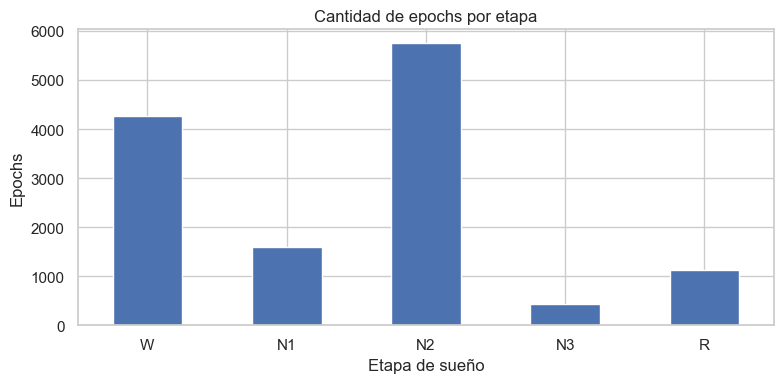

COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA


,caracteristica,Sleep_Stage,epochs_con_valor,epochs_totales,pacientes,muestras_faltantes_pct
0,HR_median,W,4267,4267,18,0.0
1,HR_median,N1,1589,1589,18,0.0
2,HR_median,N2,5744,5744,18,0.0
3,HR_median,N3,438,438,7,0.0
4,HR_median,R,1127,1127,14,0.0
5,TEMP_median,W,4267,4267,18,0.0
6,TEMP_median,N1,1589,1589,18,0.0
7,TEMP_median,N2,5744,5744,18,0.0
8,TEMP_median,N3,438,438,7,0.0
9,TEMP_median,R,1127,1127,14,0.0


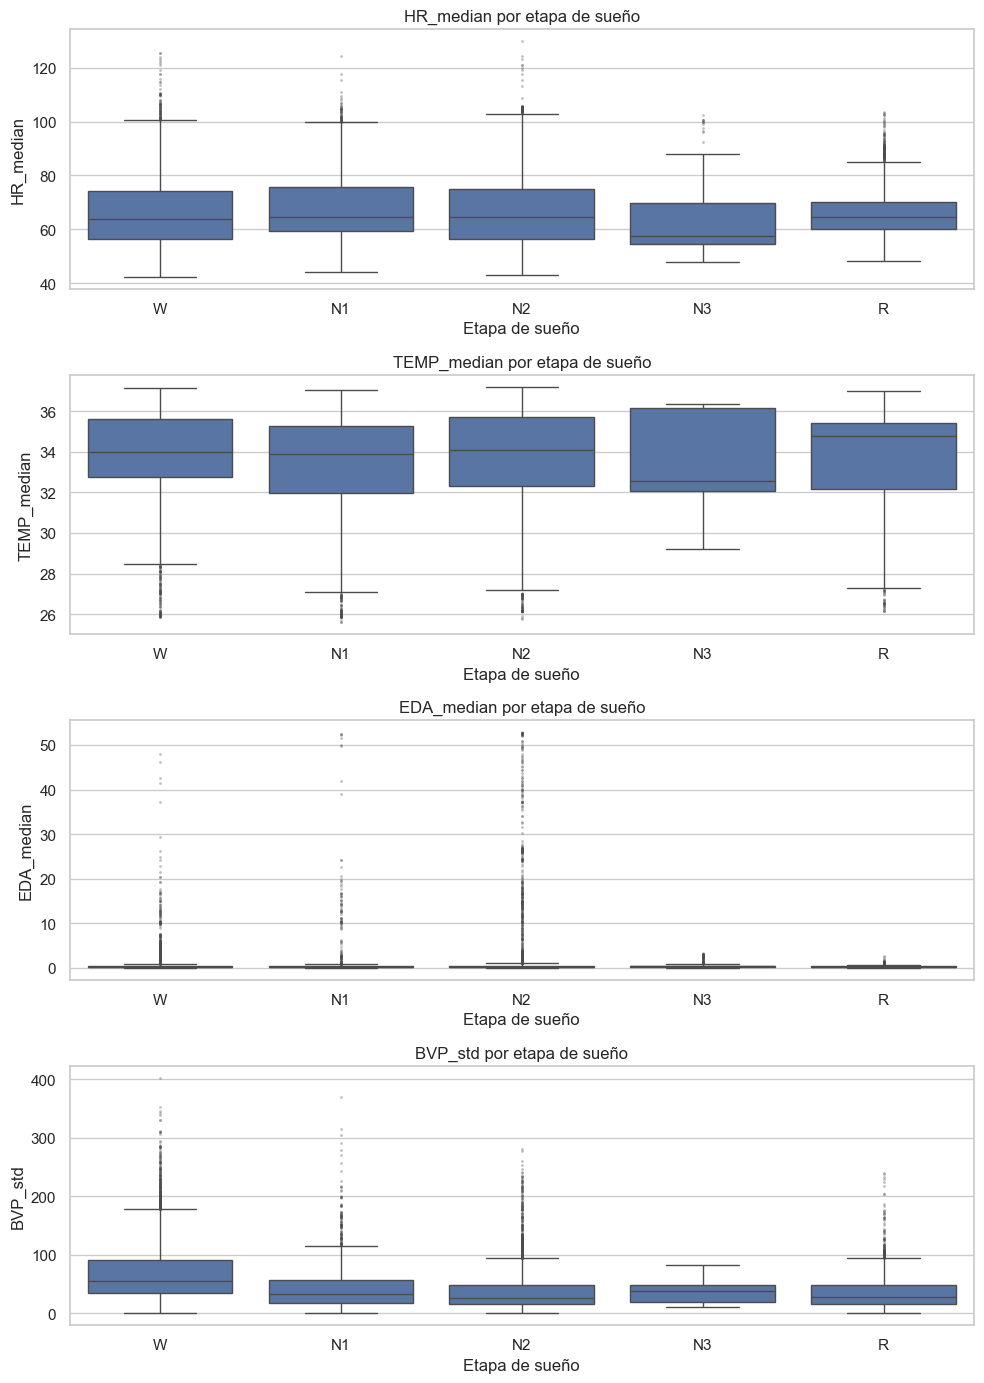

Cada observación es un epoch. Las cajas resumen datos agrupados de todos los pacientes; no representan al paciente típico. Los puntos fuera de los bigotes son candidatos estadísticos; no se eliminaron del dataset. Revisar patrones dudosos por paciente.


In [114]:
# 3.3. Comparación global por etapa de sueño
orden_etapas = ["W", "N1", "N2", "N3", "R"]

if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_requeridas = {
    "patient_id", "epoch", "Sleep_Stage", "porcentaje_pureza"
}
faltantes = columnas_requeridas.difference(df_epochs_all.columns)
if faltantes:
    raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etiquetas de sueño faltantes o inválidas.")

if not df_epochs_all["porcentaje_pureza"].eq(1.0).all():
    raise ValueError("Hay epochs no puros. Revisarlos antes de comparar.")

conteos_etapa = df_epochs_all["Sleep_Stage"].value_counts().reindex(
    orden_etapas, fill_value=0
)
pacientes_etapa = (
    df_epochs_all.groupby("Sleep_Stage")["patient_id"]
    .nunique()
    .reindex(orden_etapas, fill_value=0)
)
resumen_etapas = pd.DataFrame({
    "epochs": conteos_etapa,
    "porcentaje_epochs": 100 * conteos_etapa / len(df_epochs_all),
    "pacientes": pacientes_etapa,
})
resumen_etapas.index.name = "Sleep_Stage"

print("COBERTURA GLOBAL POR ETAPA")
display(resumen_etapas.round(2))

ax = conteos_etapa.plot.bar(figsize=(8, 4), rot=0)
ax.set_title("Cantidad de epochs por etapa")
ax.set_xlabel("Etapa de sueño")
ax.set_ylabel("Epochs")
plt.tight_layout()
plt.show()

caracteristicas_propuestas = [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std"
]
caracteristicas = [
    col for col in caracteristicas_propuestas if col in df_epochs_all.columns
]
no_disponibles = sorted(set(caracteristicas_propuestas) - set(caracteristicas))
if no_disponibles:
    print("Características no disponibles en esta versión:", no_disponibles)
if not caracteristicas:
    raise ValueError("No hay características disponibles para graficar.")

resumen_cobertura = []
for caracteristica in caracteristicas:
    valores_validos = (
        df_epochs_all.groupby("Sleep_Stage")[caracteristica]
        .count()
        .reindex(orden_etapas, fill_value=0)
    )
    señal = caracteristica.rsplit("_", 1)[0]
    columna_faltantes = f"{señal}_missing_frac"

    for etapa in orden_etapas:
        registro = {
            "caracteristica": caracteristica,
            "Sleep_Stage": etapa,
            "epochs_con_valor": int(valores_validos[etapa]),
            "epochs_totales": int(conteos_etapa[etapa]),
            "pacientes": int(pacientes_etapa[etapa]),
        }
        if columna_faltantes in df_epochs_all.columns:
            fraccion = df_epochs_all.loc[
                df_epochs_all["Sleep_Stage"].eq(etapa),
                columna_faltantes,
            ].mean()
            registro["muestras_faltantes_pct"] = 100 * fraccion
        resumen_cobertura.append(registro)

print("COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA")
display(pd.DataFrame(resumen_cobertura).round(2))

fig, axes = plt.subplots(
    len(caracteristicas), 1,
    figsize=(10, 3.5 * len(caracteristicas)),
    squeeze=False,
)
for fila, caracteristica in enumerate(caracteristicas):
    ax = axes[fila, 0]
    sns.boxplot(
        data=df_epochs_all,
        x="Sleep_Stage",
        y=caracteristica,
        order=orden_etapas,
        showfliers=True,
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.35},
        ax=ax,
    )
    ax.set_title(f"{caracteristica} por etapa de sueño")
    ax.set_xlabel("Etapa de sueño")
    ax.set_ylabel(caracteristica)

plt.tight_layout()
plt.show()

print(
    "Cada observación es un epoch. Las cajas resumen datos agrupados "
    "de todos los pacientes; no representan al paciente típico. "
    "Los puntos fuera de los bigotes son candidatos estadísticos; "
    "no se eliminaron del dataset. Revisar patrones dudosos por paciente."
)

## 3.3.1. Revisión exploratoria de valores atípicos

Se marcan valores alejados del rango intercuartílico **global** (1,5 × IQR) en características de wearable y PSG. Para HR, TEMP y EDA se priorizan medianas por epoch; para BVP, dispersión por epoch. Es una regla descriptiva, no un límite fisiológico ni una limpieza. Los límites y extremos se muestran con ocho cifras significativas para que las señales PSG pequeñas no parezcan cero por redondeo.

El resumen por variable informa cuántos epochs se marcan. La vista por paciente permite detectar si los casos se concentran en algunas personas; los tramos consecutivos muestran persistencia temporal. Los cinco casos principales **de cada variable** evitan que una señal con IQR diminuto, como EDA, monopolice la inspección. La distancia en IQR sirve para ordenar casos dentro de una variable, no para comparar gravedad entre señales.

**Los puntos de las cajas de 3.3 y esta tabla no tienen exactamente el mismo criterio:** cada caja calcula sus cuartiles dentro de una etapa, mientras que aquí el IQR se calcula con todos los epochs de la variable. Una diferencia real entre etapas puede quedar marcada por uno de los criterios y no por el otro. Ninguno demuestra error de medición.

La lista de casos conserva la fracción de muestras faltantes y los valores de epochs vecinos contiguos del mismo paciente. Se revisan características agregadas por epoch; los picos breves de la señal cruda requieren una inspección adicional. No se modifica df_epochs_all; cualquier recorte, exclusión o imputación requiere evidencia y una decisión posterior documentada en el ADR 0005.


In [115]:
# 3.3.1. Candidatos atípicos: marcas descriptivas, sin cambiar el dataset
variables_revision = [
    "HR_median", "HR_std", "TEMP_median", "EDA_median", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] + [f"{senal}_std" for senal in psg_cols]
variables_revision = list(dict.fromkeys(
    col for col in variables_revision if col in df_epochs_all.columns
))
if not variables_revision:
    raise ValueError("No hay características disponibles para revisar atípicos.")

base_revision = df_epochs_all.sort_values(["patient_id", "epoch"])
resumen_atipicos = []
resumen_atipicos_etapa = []
resumen_atipicos_paciente = []
casos_atipicos = []

for variable in variables_revision:
    valores = pd.to_numeric(base_revision[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    fila = {
        "variable": variable,
        "epochs_validos": int(validos.sum()),
        "epochs_sin_valor_finito": int((~validos).sum()),
    }
    if validos.sum() < 4:
        fila.update({"criterio": "insuficientes datos", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    q1, q3 = valores.loc[validos].quantile([0.25, 0.75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        fila.update({"criterio": "IQR nulo", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    marcados = validos & (
        (valores < limite_inferior) | (valores > limite_superior)
    )
    fila.update({
        "criterio": "1,5 × IQR global",
        "minimo": valores.loc[validos].min(),
        "p01": valores.loc[validos].quantile(0.01),
        "mediana": valores.loc[validos].median(),
        "p99": valores.loc[validos].quantile(0.99),
        "maximo": valores.loc[validos].max(),
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "epochs_marcados": int(marcados.sum()),
        "porcentaje_validos": 100 * marcados.sum() / validos.sum(),
        "pacientes_marcados": base_revision.loc[marcados, "patient_id"].nunique(),
    })
    resumen_atipicos.append(fila)

    por_paciente = (
        base_revision[["patient_id"]]
        .assign(epoch_valido=validos.astype(int), epoch_marcado=marcados.astype(int))
        .groupby("patient_id", sort=True)
        .sum()
    )
    por_paciente["variable"] = variable
    por_paciente["porcentaje_marcados"] = (
        100 * por_paciente["epoch_marcado"]
        / por_paciente["epoch_valido"].replace(0, np.nan)
    )
    resumen_atipicos_paciente.append(por_paciente.reset_index())

    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = base_revision["Sleep_Stage"].eq(etapa)
        n_validos = int((validos & en_etapa).sum())
        n_marcados = int((marcados & en_etapa).sum())
        resumen_atipicos_etapa.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_validos": n_validos,
            "epochs_marcados": n_marcados,
            "porcentaje_validos": 100 * n_marcados / n_validos if n_validos else np.nan,
        })

    if not marcados.any():
        continue
    casos = base_revision.loc[
        marcados, ["patient_id", "epoch", "Sleep_Stage"]
    ].copy()
    casos["variable"] = variable
    casos["valor"] = valores.loc[marcados]
    casos["limite_inferior"] = limite_inferior
    casos["limite_superior"] = limite_superior
    casos["distancia_iqr"] = np.maximum(
        limite_inferior - casos["valor"],
        casos["valor"] - limite_superior,
    ) / iqr

    faltantes_col = variable.rsplit("_", 1)[0] + "_missing_frac"
    if faltantes_col in base_revision.columns:
        casos["fraccion_muestras_faltantes"] = base_revision.loc[
            marcados, faltantes_col
        ]

    epochs = base_revision["epoch"]
    grupos = base_revision["patient_id"]
    anterior = valores.groupby(grupos).shift(1).where(
        epochs.sub(epochs.groupby(grupos).shift(1)).eq(1)
    )
    siguiente = valores.groupby(grupos).shift(-1).where(
        epochs.groupby(grupos).shift(-1).sub(epochs).eq(1)
    )
    casos["valor_epoch_anterior"] = anterior.loc[marcados]
    casos["valor_epoch_siguiente"] = siguiente.loc[marcados]
    casos_atipicos.append(casos)

resumen_atipicos = pd.DataFrame(resumen_atipicos)
resumen_atipicos_etapa = pd.DataFrame(resumen_atipicos_etapa)
resumen_atipicos_paciente = (
    pd.concat(resumen_atipicos_paciente, ignore_index=True)
    if resumen_atipicos_paciente else pd.DataFrame()
)
candidatos_atipicos = (
    pd.concat(casos_atipicos, ignore_index=True)
    if casos_atipicos else pd.DataFrame()
)

if candidatos_atipicos.empty:
    tramos_atipicos = pd.DataFrame()
else:
    ordenados = candidatos_atipicos.sort_values(
        ["variable", "patient_id", "epoch"]
    ).copy()
    claves = [ordenados["variable"], ordenados["patient_id"]]
    nuevo_tramo = ordenados.groupby(
        ["variable", "patient_id"]
    )["epoch"].diff().ne(1)
    ordenados["tramo_id"] = nuevo_tramo.groupby(claves).cumsum()
    tramos_atipicos = (
        ordenados.groupby(["variable", "patient_id", "tramo_id"], sort=False)
        .agg(
            epoch_inicial=("epoch", "min"),
            epoch_final=("epoch", "max"),
            epochs_marcados=("epoch", "size"),
            distancia_iqr_max=("distancia_iqr", "max"),
        )
        .reset_index()
        .drop(columns="tramo_id")
    )
    tramos_atipicos["duracion_minutos"] = tramos_atipicos["epochs_marcados"] * 0.5

# Ocho cifras significativas: no confundir valores pequeños con cero.
with pd.option_context("display.float_format", lambda x: f"{x:.8g}"):
    print("RESUMEN DE CANDIDATOS POR VARIABLE (IQR global)")
    display(resumen_atipicos.sort_values("epochs_marcados", ascending=False))

    print("CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)")
    if resumen_atipicos_etapa.empty:
        display("Sin variables con criterio IQR aplicable")
    else:
        display(resumen_atipicos_etapa.loc[
            resumen_atipicos_etapa["epochs_marcados"].gt(0)
        ].sort_values("porcentaje_validos", ascending=False).head(30))

    print("PACIENTES MÁS AFECTADOS POR VARIABLE (tres por variable)")
    if resumen_atipicos_paciente.empty:
        display("Sin variables con criterio IQR aplicable")
    else:
        principales_paciente = (
            resumen_atipicos_paciente.loc[
                resumen_atipicos_paciente["epoch_marcado"].gt(0)
            ]
            .sort_values(
                ["variable", "epoch_marcado", "porcentaje_marcados"],
                ascending=[True, False, False],
            )
            .groupby("variable", sort=False)
            .head(3)
        )
        display(principales_paciente if not principales_paciente.empty
                else "Sin candidatos")

    print("TRAMOS CONSECUTIVOS MÁS LARGOS (tres por variable)")
    if tramos_atipicos.empty:
        display("Sin tramos marcados")
    else:
        principales_tramos = (
            tramos_atipicos.sort_values(
                ["variable", "epochs_marcados", "distancia_iqr_max"],
                ascending=[True, False, False],
            )
            .groupby("variable", sort=False)
            .head(3)
        )
        display(principales_tramos)

    print("CINCO CASOS MÁS ALEJADOS POR VARIABLE; NO ELIMINADOS")
    if candidatos_atipicos.empty:
        display("Sin candidatos")
    else:
        principales_casos = (
            candidatos_atipicos.sort_values(
                ["variable", "distancia_iqr"],
                ascending=[True, False],
            )
            .groupby("variable", sort=False)
            .head(5)
        )
        display(principales_casos)

print(
    "Las tablas completas están en resumen_atipicos_paciente, "
    "tramos_atipicos y candidatos_atipicos. Ningún dato fue modificado."
)


RESUMEN DE CANDIDATOS POR VARIABLE (IQR global)


,variable,epochs_validos,epochs_sin_valor_finito,criterio,minimo,p01,mediana,p99,maximo,limite_inferior,limite_superior,epochs_marcados,porcentaje_validos,pacientes_marcados
4,EDA_std,13165,0,"1,5 × IQR global",0,0.00069111195,0.0015354228,0.41079219,5.1376824,-0.0038520376,0.009322172,2506,19.035321,18
6,ACC_X_std,13165,0,"1,5 × IQR global",0,0,0.39629695,26.842698,52.36403,-0.51678336,1.2875863,2198,16.695784,18
21,SNORE_std,13165,0,"1,5 × IQR global",0,2.6445409e-07,1.0739717e-06,0.000148677,0.00042277251,-3.0407164e-06,6.8069626e-06,2153,16.353969,17
8,ACC_Z_std,13165,0,"1,5 × IQR global",0,0,0.395911,25.584292,52.527504,-0.34284092,1.0883351,2150,16.331181,18
20,RAT_std,13165,0,"1,5 × IQR global",0,2.5546522e-07,2.2133277e-06,0.00016355379,0.0004354299,-7.5678275e-06,1.5386311e-05,1997,15.169009,18
22,PTAF_std,13165,0,"1,5 × IQR global",0,2.5603892e-06,6.8400695e-05,0.0019951378,0.0025733989,-0.00047516115,0.00083734069,1879,14.272693,14
7,ACC_Y_std,13165,0,"1,5 × IQR global",0,0,0.34001425,20.88587,48.61469,-0.39124894,1.0096635,1758,13.353589,18
25,ABDOMEN_std,13165,0,"1,5 × IQR global",0,1.0725753e-06,0.00016038555,0.0010244843,0.001714727,-0.0002725806,0.00065752292,1523,11.568553,16
19,LAT_std,13165,0,"1,5 × IQR global",0,4.2740612e-07,2.5697284e-06,0.00010634127,0.000601914,-9.0785265e-06,1.8013599e-05,1446,10.983669,18
3,EDA_median,13165,0,"1,5 × IQR global",0,0.002559,0.237285,24.267064,52.87126,-0.355813,0.996779,1318,10.011394,9


CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)


,variable,Sleep_Stage,epochs_validos,epochs_marcados,porcentaje_validos
53,F4-M1_std,N3,438,284,64.840183
48,C4-M1_std,N3,438,243,55.479452
108,SNORE_std,N3,438,212,48.401826
40,ACC_Z_std,W,4267,1455,34.098899
30,ACC_X_std,W,4267,1445,33.864542
35,ACC_Y_std,W,4267,1280,29.997656
20,EDA_std,W,4267,1209,28.333724
63,Fp1-O2_std,N3,438,120,27.39726
68,T3 - CZ_std,N3,438,114,26.027397
100,RAT_std,W,4267,1106,25.91985


PACIENTES MÁS AFECTADOS POR VARIABLE (tres por variable)


...

TRAMOS CONSECUTIVOS MÁS LARGOS (tres por variable)


,variable,patient_id,epoch_inicial,epoch_final,epochs_marcados,distancia_iqr_max,duracion_minutos
187,ABDOMEN_std,84,456,617,162,2.1096588,81
175,ABDOMEN_std,84,179,329,151,4.1639093,75.5
195,ABDOMEN_std,86,5,153,149,4.2598221,74.5
289,ACC_X_std,2,139,181,43,55.065823,21.5
1025,ACC_X_std,19,558,596,39,77.884427,19.5
...,...,...,...,...,...,...,...
12327,TEMP_median,16,669,749,81,0.29518072,40.5
12324,TEMP_median,16,162,170,9,0.048192771,4.5
12329,THORAX_std,2,17,141,125,2.1385066,62.5
12330,THORAX_std,2,143,205,63,1.5483313,31.5


CINCO CASOS MÁS ALEJADOS POR VARIABLE; NO ELIMINADOS


,patient_id,epoch,Sleep_Stage,variable,valor,limite_inferior,limite_superior,distancia_iqr,fraccion_muestras_faltantes,valor_epoch_anterior,valor_epoch_siguiente
31157,10,248,W,ABDOMEN_std,0.001714727,-0.0002725806,0.00065752292,4.5466082,0,0.000962672,0.001306612
31090,3,533,W,ABDOMEN_std,0.0016806409,-0.0002725806,0.00065752292,4.4000177,0,0.001368829,0.00053367554
31092,3,536,W,ABDOMEN_std,0.0016729657,-0.0002725806,0.00065752292,4.3670097,0,0.0015651255,0.0012484377
32047,86,134,W,ABDOMEN_std,0.0016480418,-0.0002725806,0.00065752292,4.2598221,0,0.001293061,0.0012866454
31596,84,321,W,ABDOMEN_std,0.0016257396,-0.0002725806,0.00065752292,4.1639093,0,0.00093201885,0.0015128129
...,...,...,...,...,...,...,...,...,...,...,...
30500,3,757,W,THORAX_std,0.0021357713,-0.00030342022,0.00071223334,5.6063918,0,0.00205792,0.001638525
30494,3,562,N2,THORAX_std,0.0020949799,-0.00030342022,0.00071223334,5.445741,0,0.0014788103,0.0017769999
30499,3,756,W,THORAX_std,0.00205792,-0.00030342022,0.00071223334,5.2997861,0,0.0019937134,0.0021357713
30498,3,755,W,THORAX_std,0.0019937134,-0.00030342022,0.00071223334,5.046918,0,0.00087305706,0.00205792


Las tablas completas están en resumen_atipicos_paciente, tramos_atipicos y candidatos_atipicos. Ningún dato fue modificado.


### 3.3.2. Distribuciones de predictores prioritarios

Se muestran pocos resúmenes representativos: medianas por epoch de HR, temperatura y EDA, dispersión por epoch de BVP y aceleración, un canal PSG y SAO2 solo si está disponible. Cada fila combina un histograma global, que permite ver escala, ceros y colas, con una caja por etapa para comparar superposición. La tabla informa cuántos epochs y pacientes aportan valores finitos en cada etapa. Los extremos no se borran; esta segunda vista oculta sus puntos para conservar legibilidad, mientras que las cajas de 3.3 los muestran y 3.3.1 los cuantifica. Las unidades deben confirmarse contra la documentación y los CSV fuente antes de interpretar magnitudes o fijar rangos.

La regresión logística **no exige predictores normales**. Una distribución sesgada puede motivar una transformación posterior, ajustada solo con pacientes de entrenamiento, pero no obliga a forzar normalidad. `Sleep_Stage` es categórica: no se normaliza. Su desbalance se describe con los recuentos globales de 3.3 y por paciente de 3.6; ponderación de clases y métricas por etapa quedan para el modelado, siempre con partición por paciente.


COBERTURA POR VARIABLE Y ETAPA


,variable,Sleep_Stage,epochs_con_valor,epochs_totales,cobertura_pct,pacientes_con_valor
0,HR_median,W,4267,4267,100.0,18
1,HR_median,N1,1589,1589,100.0,18
2,HR_median,N2,5744,5744,100.0,18
3,HR_median,N3,438,438,100.0,7
4,HR_median,R,1127,1127,100.0,14
5,TEMP_median,W,4267,4267,100.0,18
6,TEMP_median,N1,1589,1589,100.0,18
7,TEMP_median,N2,5744,5744,100.0,18
8,TEMP_median,N3,438,438,100.0,7
9,TEMP_median,R,1127,1127,100.0,14


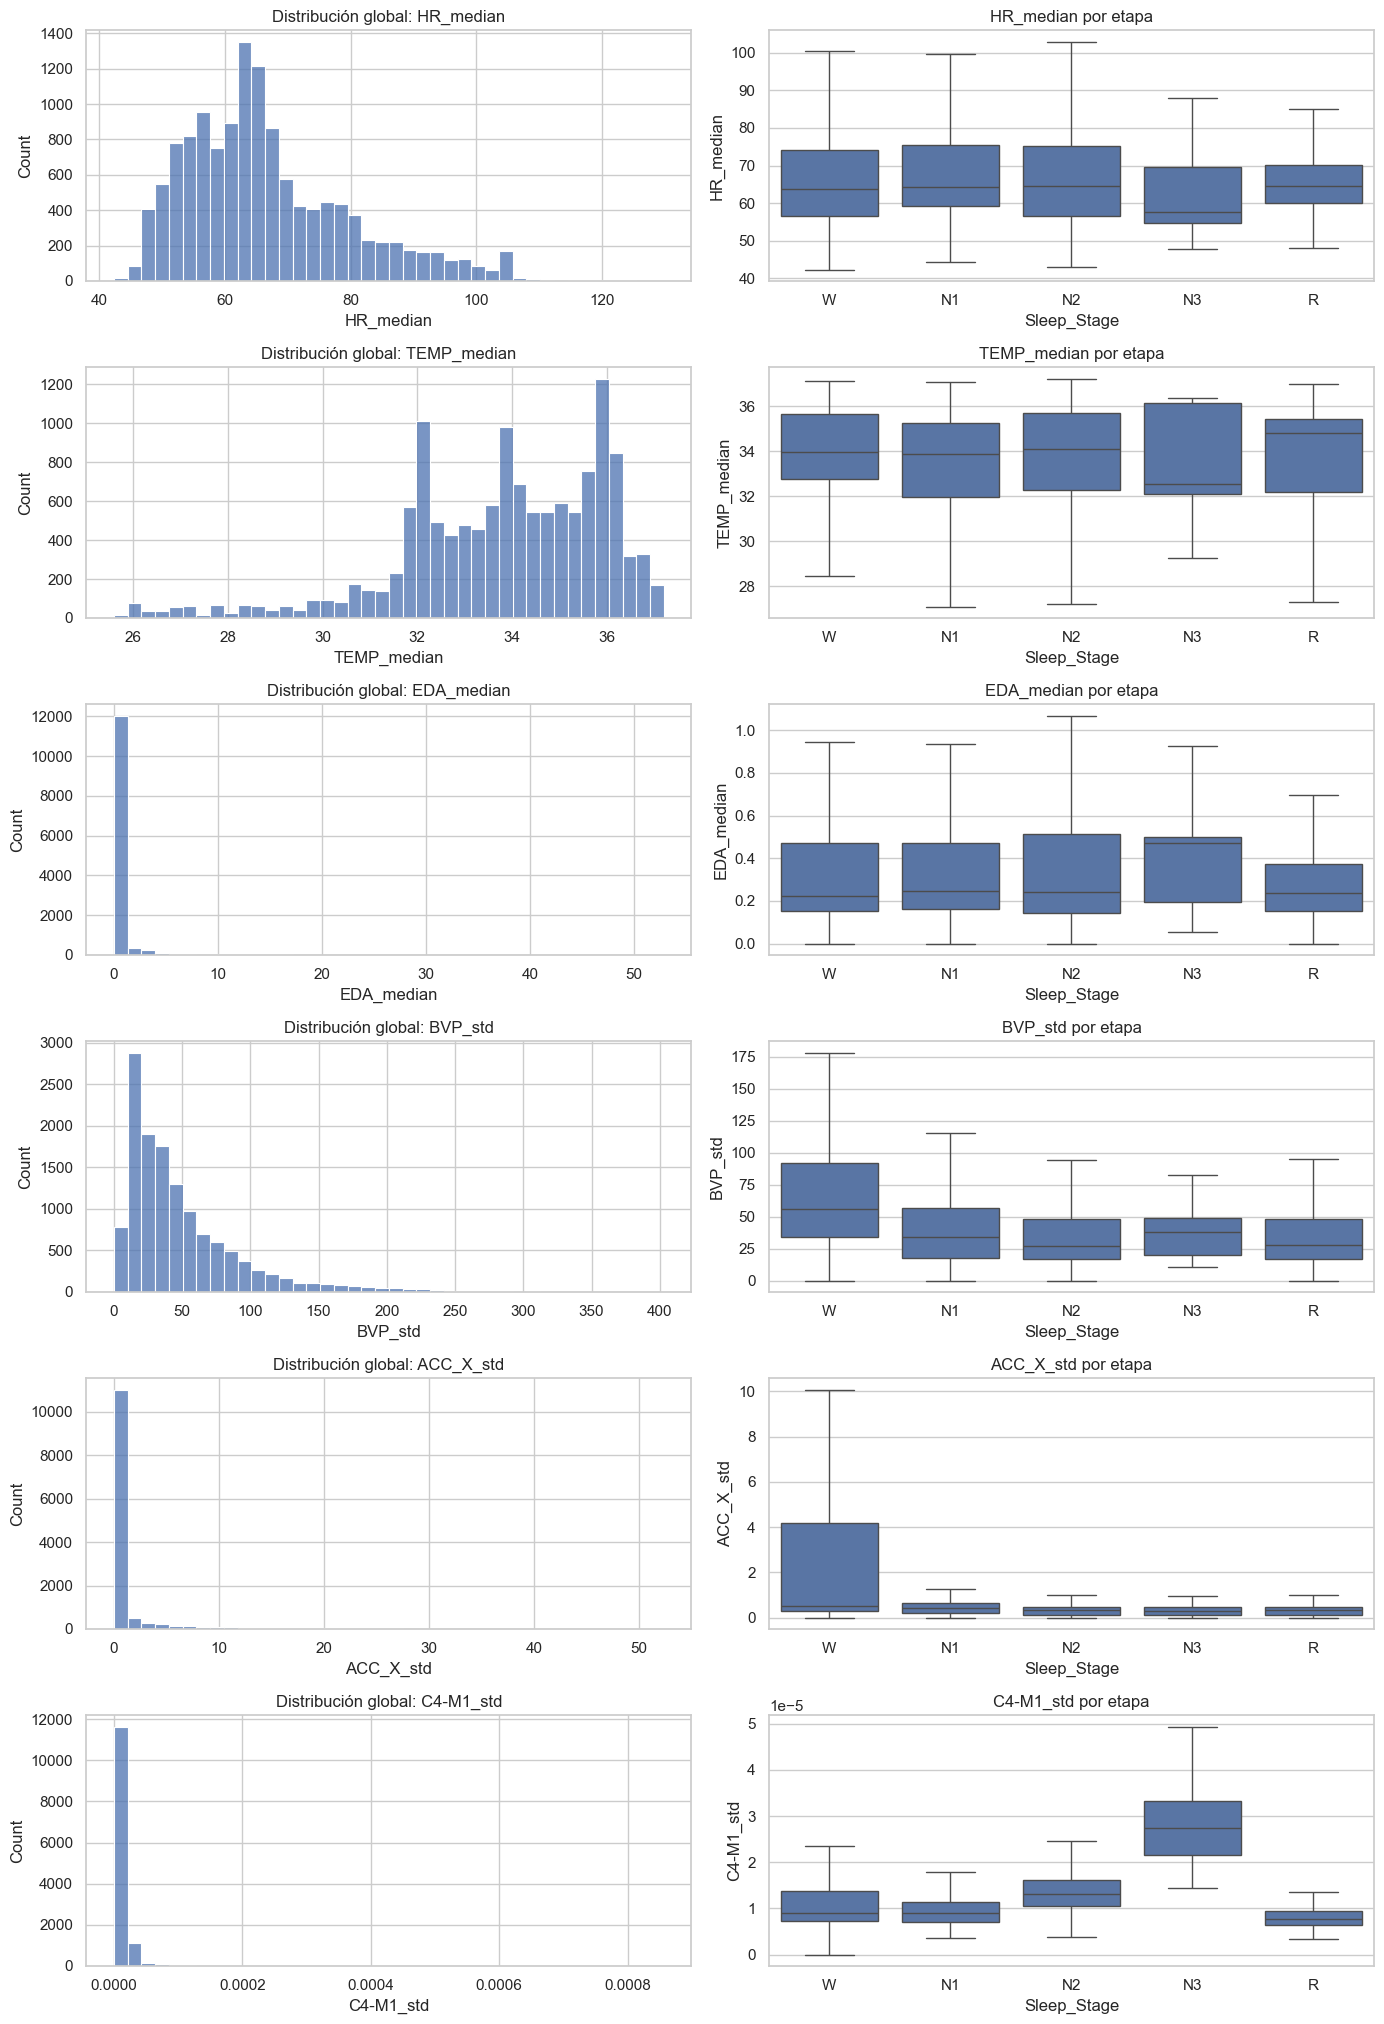

Los gráficos son descriptivos. No se transformaron predictores ni se balancearon etapas. Confirmar unidades antes de fijar umbrales.


In [116]:
# 3.3.2. Distribuciones de predictores prioritarios
candidatas_distribucion = [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std",
    "ACC_X_std", "C4-M1_std", "SAO2_mean",
]
variables_distribucion = [c for c in candidatas_distribucion
                          if c in df_epochs_all.columns]
if not variables_distribucion:
    raise ValueError("No hay predictores prioritarios disponibles.")

filas_cobertura = []
for variable in variables_distribucion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = df_epochs_all["Sleep_Stage"].eq(etapa)
        validos_etapa = finitos & en_etapa
        total_etapa = int(en_etapa.sum())
        filas_cobertura.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_con_valor": int(validos_etapa.sum()),
            "epochs_totales": total_etapa,
            "cobertura_pct": 100 * validos_etapa.sum() / total_etapa
                             if total_etapa else np.nan,
            "pacientes_con_valor": df_epochs_all.loc[
                validos_etapa, "patient_id"
            ].nunique(),
        })
resumen_distribuciones = pd.DataFrame(filas_cobertura)
print("COBERTURA POR VARIABLE Y ETAPA")
display(resumen_distribuciones.round(2))

fig, axes = plt.subplots(
    len(variables_distribucion), 2,
    figsize=(14, 3.4 * len(variables_distribucion)),
    squeeze=False,
)
for fila, variable in enumerate(variables_distribucion):
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    datos_grafico = df_epochs_all.loc[
        finitos, ["Sleep_Stage", variable]
    ]
    if datos_grafico.empty:
        axes[fila, 0].set_title(f"{variable}: sin valores finitos")
        axes[fila, 1].set_visible(False)
        continue
    sns.histplot(data=datos_grafico, x=variable, bins=40,
                 ax=axes[fila, 0])
    axes[fila, 0].set_title(f"Distribución global: {variable}")
    sns.boxplot(data=datos_grafico, x="Sleep_Stage", y=variable,
                order=["W", "N1", "N2", "N3", "R"],
                showfliers=False, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"{variable} por etapa")
plt.tight_layout()
plt.show()
print(
    "Los gráficos son descriptivos. No se transformaron predictores ni "
    "se balancearon etapas. Confirmar unidades antes de fijar umbrales."
)


### 3.3.3. EDA en todos los pacientes incluidos

La sección 2.6.4 usa máximos crudos de todos los archivos auditados, pero profundiza solo en S002, S004 y S057. Aquí se usan todos los epochs conservados en el ETL: se comparan percentiles de EDA por paciente y su evolución temporal sin releer los CSV de 100 Hz. Esto excluye pacientes y epochs rechazados por el ETL; S097 no aparece.

La distancia entre la mediana y el percentil 95 señala episodios elevados dentro del paciente; valores altos en ambos sugieren un nivel basal alto. El mapa temporal muestra si el aumento es localizado o sostenido. La escala log(1 + EDA) se usa solo para visualizar y no transforma el dataset. Un resumen de 30 segundos puede ocultar picos más breves: contrastar S004 y S057 con las curvas crudas de 2.6.4 antes de decidir una limpieza.


Archivos fuente: 18 | Pacientes incluidos en ETL: 18
Epochs sin EDA finita: 0 | Con EDA mediana negativa (revisar): 0
EDA POR PACIENTE: TODOS LOS INCLUIDOS


,patient_id,epochs_con_eda,mediana,p95,p99,maximo_epoch,epochs_totales,cobertura_pct,estado_revision
0,17,770,0.102,0.167,0.181,0.241,770,100.0,Exploratorio
1,2,652,0.140,0.888,1.342,1.420,652,100.0,Exploratorio
2,87,535,0.147,0.183,0.191,0.200,535,100.0,Exploratorio
3,7,797,0.155,0.165,0.170,0.179,797,100.0,Exploratorio
4,8,743,0.162,0.359,1.123,1.615,743,100.0,Exploratorio
5,16,750,0.187,0.266,0.271,0.273,750,100.0,Exploratorio
6,9,766,0.191,3.168,6.206,7.067,766,100.0,Exploratorio
7,10,795,0.192,2.642,3.485,3.761,795,100.0,Exploratorio
8,84,687,0.216,0.265,0.302,0.444,687,100.0,Exploratorio
9,3,773,0.284,2.130,2.994,3.296,773,100.0,Exploratorio


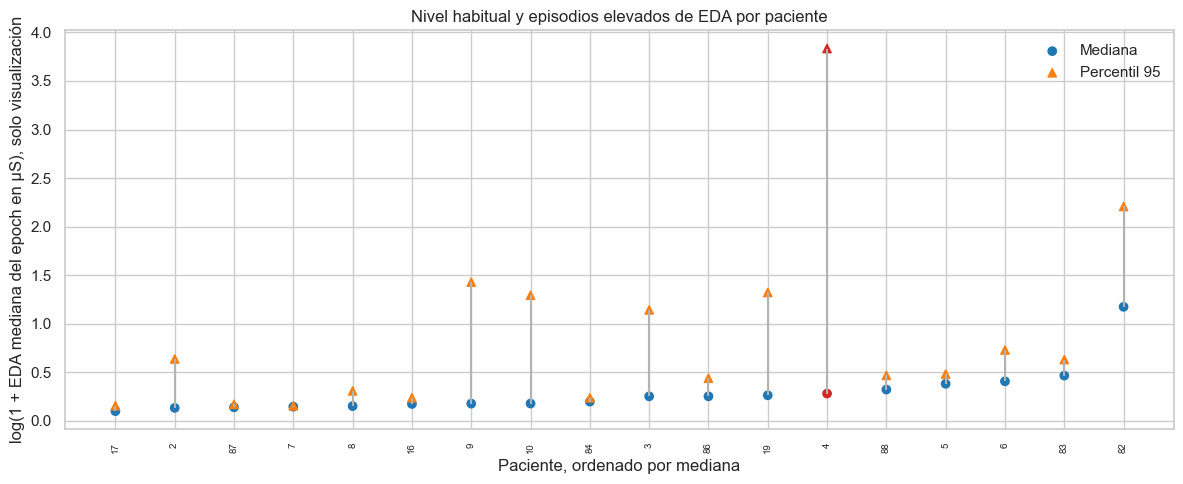

Epochs con EDA pero tiempo no graficable: 0


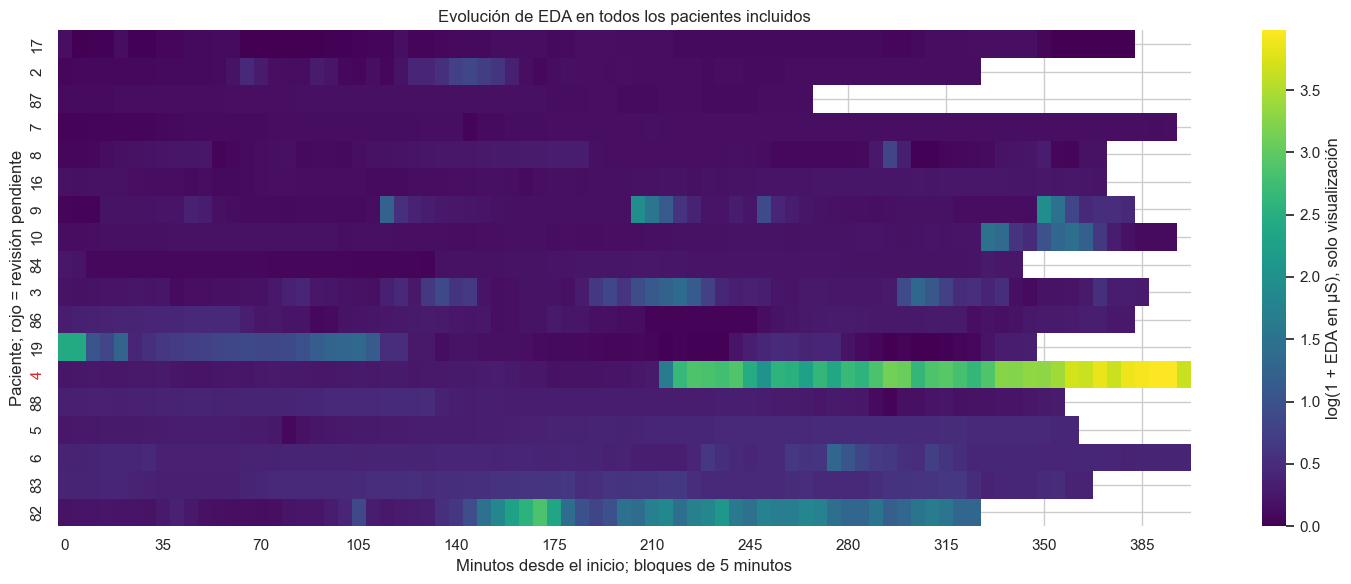

Gráficos descriptivos: no se recortó ni transformó el dataset.


In [117]:
# 3.3.3. Resumen EDA de todos los pacientes incluidos en el ETL
requeridas_eda = ["patient_id", "EDA_median", "tiempo_relativo_segundos"]
if not set(requeridas_eda).issubset(df_epochs_all.columns):
    raise ValueError("Faltan columnas para el análisis global de EDA.")
eda_total = df_epochs_all[requeridas_eda].copy()
for columna in ["EDA_median", "tiempo_relativo_segundos"]:
    eda_total[columna] = pd.to_numeric(eda_total[columna], errors="coerce")
finita = np.isfinite(eda_total["EDA_median"])
negativa = finita & eda_total["EDA_median"].lt(0)
print("Archivos fuente:", len(data_files),"| Pacientes incluidos en ETL:", eda_total["patient_id"].nunique())
print("Epochs sin EDA finita:", int((~finita).sum()),
      "| Con EDA mediana negativa (revisar):", int(negativa.sum()))
eda_valida = eda_total.loc[finita & ~negativa].copy()
if eda_valida.empty:
    raise ValueError("No hay EDA no negativa y finita para graficar.")
resumen_eda_paciente = eda_valida.groupby("patient_id")["EDA_median"].agg(
    epochs_con_eda="size", mediana="median",
    p95=lambda s: s.quantile(0.95), p99=lambda s: s.quantile(0.99),
    maximo_epoch="max",
).reset_index()
resumen_eda_paciente["epochs_totales"] = resumen_eda_paciente["patient_id"].map(
    eda_total.groupby("patient_id").size()
)
resumen_eda_paciente["cobertura_pct"] = (
    100 * resumen_eda_paciente["epochs_con_eda"]
    / resumen_eda_paciente["epochs_totales"]
)
resumen_eda_paciente["estado_revision"] = np.where(
    resumen_eda_paciente["patient_id"].isin([4, 57]),
    "Pendiente de revisión", "Exploratorio",
)
resumen_eda_paciente = resumen_eda_paciente.sort_values("mediana").reset_index(drop=True)
print("EDA POR PACIENTE: TODOS LOS INCLUIDOS")
with pd.option_context("display.max_rows", None):
    display(resumen_eda_paciente.round(3))

x = np.arange(len(resumen_eda_paciente))
marcados = resumen_eda_paciente["patient_id"].isin([4, 57])
fig, ax = plt.subplots(figsize=(max(12, 0.27 * len(x)), 5))
ax.vlines(x, np.log1p(resumen_eda_paciente["mediana"]),
          np.log1p(resumen_eda_paciente["p95"]), color="0.7")
ax.scatter(x, np.log1p(resumen_eda_paciente["mediana"]),
           c=np.where(marcados, "tab:red", "tab:blue"), label="Mediana")
ax.scatter(x, np.log1p(resumen_eda_paciente["p95"]), marker="^",
           c=np.where(marcados, "tab:red", "tab:orange"), label="Percentil 95")
ax.set_xticks(x)
ax.set_xticklabels(resumen_eda_paciente["patient_id"].astype(str), rotation=90, fontsize=7)
ax.set(xlabel="Paciente, ordenado por mediana",
       ylabel="log(1 + EDA mediana del epoch en µS), solo visualización",
       title="Nivel habitual y episodios elevados de EDA por paciente")
ax.legend()
plt.tight_layout()
plt.show()

tiempo_valido = (np.isfinite(eda_valida["tiempo_relativo_segundos"])
                 & eda_valida["tiempo_relativo_segundos"].ge(0))
print("Epochs con EDA pero tiempo no graficable:", int((~tiempo_valido).sum()))
eda_temporal = eda_valida.loc[tiempo_valido].copy()
if not eda_temporal.empty:
    eda_temporal["bloque_5min"] = (
        eda_temporal["tiempo_relativo_segundos"] // 300
    ).astype(int)
    mapa_eda = eda_temporal.groupby(["patient_id", "bloque_5min"])["EDA_median"].median().unstack()
    mapa_eda = mapa_eda.reindex(resumen_eda_paciente["patient_id"])
    fig, ax = plt.subplots(figsize=(15, max(6, 0.22 * len(mapa_eda))))
    sns.heatmap(np.log1p(mapa_eda), ax=ax, cmap="viridis",
                cbar_kws={"label": "log(1 + EDA en µS), solo visualización"})
    paso = max(1, int(np.ceil(len(mapa_eda.columns) / 12)))
    indices = np.arange(0, len(mapa_eda.columns), paso)
    ax.set_xticks(indices + 0.5)
    ax.set_xticklabels((mapa_eda.columns[indices] * 5).astype(int), rotation=0)
    for etiqueta in ax.get_yticklabels():
        if etiqueta.get_text() in {"4", "57"}:
            etiqueta.set_color("tab:red")
    ax.set(xlabel="Minutos desde el inicio; bloques de 5 minutos",
           ylabel="Paciente; rojo = revisión pendiente",
           title="Evolución de EDA en todos los pacientes incluidos")
    plt.tight_layout()
    plt.show()
print("Gráficos descriptivos: no se recortó ni transformó el dataset.")


## 3.4. Asociación entre señales y etapas

Los dos primeros mapas usan Spearman para revisar relaciones **entre predictores**; no miden relación con `Sleep_Stage`. Se eligen resúmenes con interpretación física y se excluyen identificadores, tiempo, anotaciones de apnea y numeraciones artificiales de la etapa. Para HR, EDA y TEMP se usan las medianas por epoch, en coherencia con la sección 3.3; sus medias también existen, pero aquí no se mezclan ambas versiones. Las columnas esperadas de esas tres señales se comprueban explícitamente; otras columnas ausentes se omiten sin inventar valores. Un par con |r| > 0,85 merece revisión de cobertura y redundancia, pero no se elimina automáticamente.

El tercer mapa compara cada etapa frente al resto mediante AUC de rangos. Se usa aquí como descripción univariada de la muestra, no como evaluación de un modelo ni criterio definitivo de selección. La comparación puede estar dominada por pacientes con más epochs; su estabilidad se comprobará después por paciente y fuera de muestra.

**Reejecutar 3.4 tras este cambio:** las salidas guardadas anteriormente pueden corresponder a `*_mean` y no deben interpretarse como resultados de `*_median`.


Cobertura de características incluidas en los mapas


,epochs_con_valor
BVP_std,13165
HR_median,13165
HR_std,13165
EDA_median,13165
EDA_std,13165
TEMP_median,13165
ACC_X_std,13165
ACC_Y_std,13165
ACC_Z_std,13165
C4-M1_std,13165


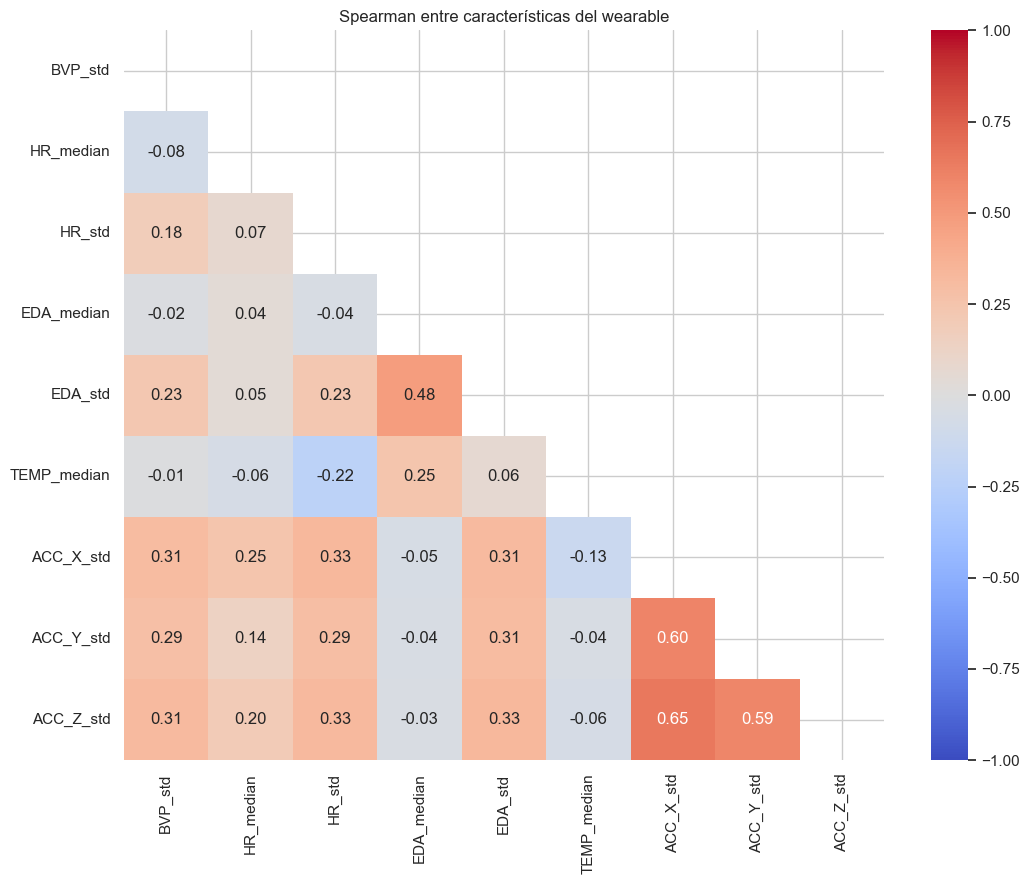

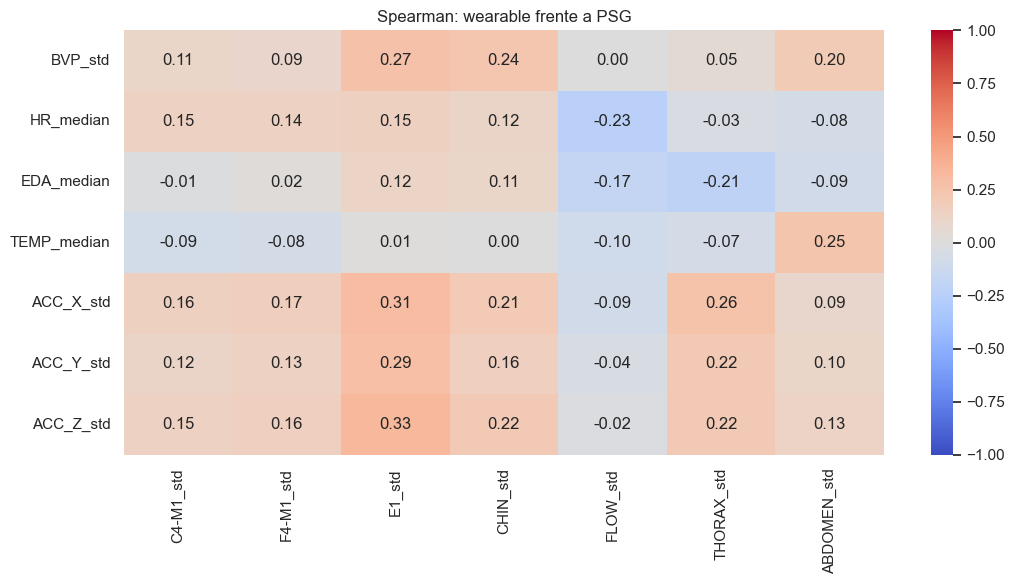

Pares con |Spearman| > 0,85: 5; ninguno se elimina


,variable_1,variable_2,spearman,magnitud
0,C4-M1_std,F4-M1_std,0.929931,0.929931
1,T3 - CZ_std,CZ - T4_std,0.905134,0.905134
2,C4-M1_std,T3 - CZ_std,0.862699,0.862699
3,C4-M1_std,CZ - T4_std,0.856628,0.856628
4,E1_std,E2_std,0.853632,0.853632


In [118]:
# 3.4.1. Asociaciones entre predictores, sin variable objetivo
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_centrales = ["HR_median", "EDA_median", "TEMP_median"]
faltantes_centrales = [c for c in columnas_centrales if c not in df_epochs_all.columns]
if faltantes_centrales:
    raise ValueError(f"Faltan columnas esperadas del ETL: {faltantes_centrales}")

wearable_mapa = [c for c in [
    "BVP_std", "HR_median", "HR_std", "EDA_median", "EDA_std",
    "TEMP_median", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in df_epochs_all.columns]
psg_mapa = [f"{senal}_std" for senal in psg_cols
            if f"{senal}_std" in df_epochs_all.columns]
caracteristicas_asociacion = wearable_mapa + psg_mapa
if len(caracteristicas_asociacion) < 2:
    raise ValueError("Faltan características para calcular asociaciones.")

print("Cobertura de características incluidas en los mapas")
display(df_epochs_all[caracteristicas_asociacion].notna().sum()
        .rename("epochs_con_valor").to_frame())

if len(wearable_mapa) > 1:
    corr_wearable = df_epochs_all[wearable_mapa].corr(
        method="spearman", min_periods=30
    )
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_wearable, mask=np.triu(np.ones_like(
        corr_wearable, dtype=bool)), annot=True, fmt=".2f",
        cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman entre características del wearable")
    plt.tight_layout()
    plt.show()

wearable_cruce = [c for c in [
    "BVP_std", "HR_median", "EDA_median", "TEMP_median",
    "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in wearable_mapa]
psg_cruce = [c for c in [
    "C4-M1_std", "F4-M1_std", "E1_std", "CHIN_std",
    "FLOW_std", "THORAX_std", "ABDOMEN_std",
] if c in psg_mapa]
if wearable_cruce and psg_cruce:
    corr_cruce = df_epochs_all[wearable_cruce + psg_cruce].corr(
        method="spearman", min_periods=30
    ).loc[wearable_cruce, psg_cruce]
    plt.figure(figsize=(11, 6))
    sns.heatmap(corr_cruce, annot=True, fmt=".2f",
                cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman: wearable frente a PSG")
    plt.tight_layout()
    plt.show()

corr_predictores = df_epochs_all[caracteristicas_asociacion].corr(
    method="spearman", min_periods=30
)
triangulo = corr_predictores.where(np.triu(np.ones(
    corr_predictores.shape, dtype=bool), k=1))
pares_revisar = (
    triangulo.stack().rename("spearman").reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares_revisar = pares_revisar.loc[
    pares_revisar["spearman"].abs().gt(0.85)
].copy()
pares_revisar["magnitud"] = pares_revisar["spearman"].abs()
pares_revisar = pares_revisar.sort_values(
    "magnitud", ascending=False
).reset_index(drop=True)
print(f"Pares con |Spearman| > 0,85: {len(pares_revisar)}; ninguno se elimina")
display(pares_revisar.head(30))


### 3.4.2. Asociación descriptiva con cada etapa

Para cada característica se calcula una AUC de rangos de una etapa frente a las demás, usando únicamente epochs con valor finito. El mapa presenta `2 × AUC − 1`: **0** indica ausencia de separación por rangos; valores positivos indican valores mayores en esa etapa y negativos, menores. Las celdas sin ambas clases quedan vacías. La tabla adjunta informa cobertura, epochs y pacientes por etapa. Este análisis no presupone un orden entre W, N1, N2, N3 y R y no autoriza retirar columnas por sí solo.


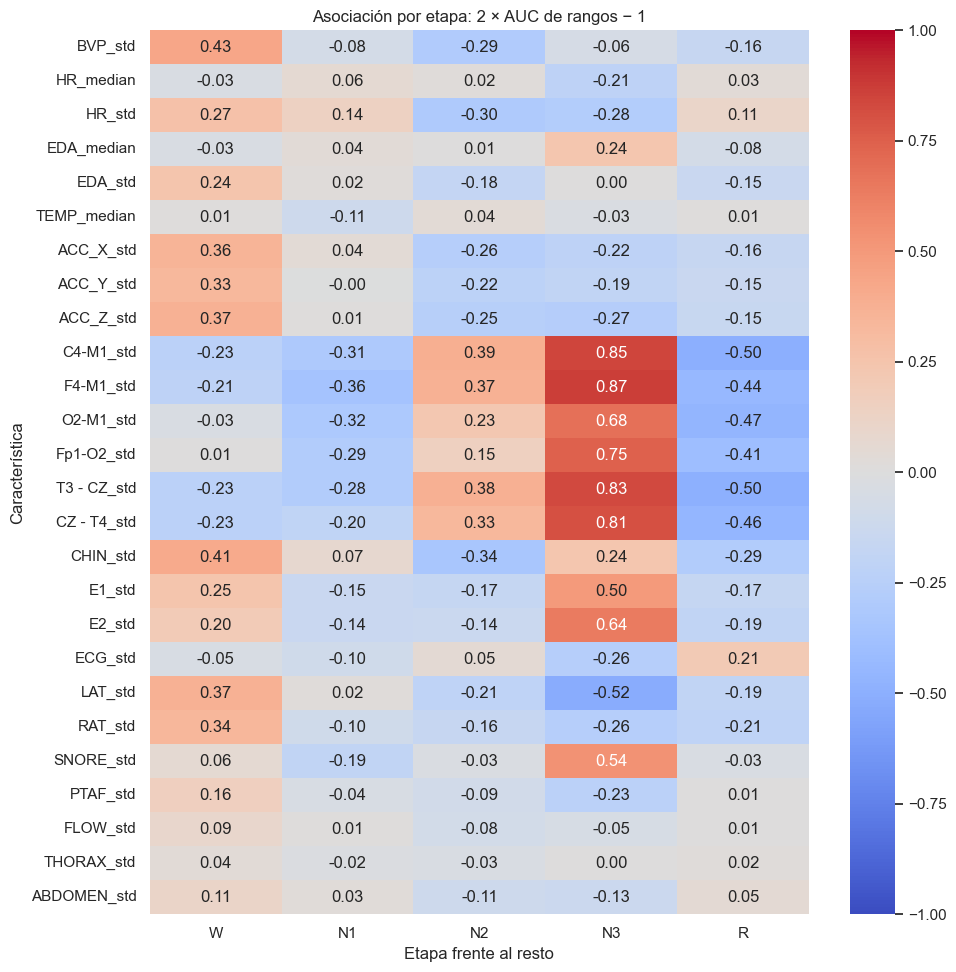

Detalle de cobertura y tamaños por etapa


,variable,Sleep_Stage,auc_rangos,direccion,epochs_etapa,epochs_resto,cobertura_pct,pacientes_etapa
0,BVP_std,W,0.716,0.431,4267,8898,100.0,18
1,BVP_std,N1,0.461,-0.078,1589,11576,100.0,18
2,BVP_std,N2,0.354,-0.292,5744,7421,100.0,18
3,BVP_std,N3,0.469,-0.061,438,12727,100.0,7
4,BVP_std,R,0.421,-0.157,1127,12038,100.0,14
...,...,...,...,...,...,...,...,...
125,ABDOMEN_std,W,0.557,0.115,4267,8898,100.0,18
126,ABDOMEN_std,N1,0.513,0.025,1589,11576,100.0,18
127,ABDOMEN_std,N2,0.445,-0.111,5744,7421,100.0,18
128,ABDOMEN_std,N3,0.435,-0.129,438,12727,100.0,7


0: sin separación univariada; positivo: valores mayores en la etapa; negativo: valores menores. Revisar cobertura y consistencia entre pacientes. Estas AUC no son rendimiento predictivo fuera de muestra.


In [119]:
# 3.4. Asociación por etapa: AUC de rangos uno contra el resto
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas inválidas o faltantes.")

filas_auc = []
for variable in caracteristicas_asociacion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    rangos = valores.loc[validos].rank(method="average")
    etapas_validas = df_epochs_all.loc[validos, "Sleep_Stage"]
    for etapa in orden_etapas:
        positivos = etapas_validas.eq(etapa)
        n_pos = int(positivos.sum())
        n_neg = int((~positivos).sum())
        auc = (
            (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
            / (n_pos * n_neg)
            if n_pos and n_neg else np.nan
        )
        filas_auc.append({
            "variable": variable, "Sleep_Stage": etapa,
            "auc_rangos": auc,
            "direccion": 2 * auc - 1 if pd.notna(auc) else np.nan,
            "epochs_etapa": n_pos, "epochs_resto": n_neg,
            "cobertura_pct": 100 * validos.mean(),
            "pacientes_etapa": df_epochs_all.loc[
                validos & df_epochs_all["Sleep_Stage"].eq(etapa), "patient_id"
            ].nunique(),
        })

resumen_auc_etapa = pd.DataFrame(filas_auc)
matriz_direccion = resumen_auc_etapa.pivot(
    index="variable", columns="Sleep_Stage", values="direccion"
).reindex(index=caracteristicas_asociacion, columns=orden_etapas)
if matriz_direccion.notna().any().any():
    plt.figure(figsize=(10, max(7, 0.38 * len(matriz_direccion))))
    sns.heatmap(matriz_direccion, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Asociación por etapa: 2 × AUC de rangos − 1")
    plt.xlabel("Etapa frente al resto")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()
else:
    print("No hay etapas con ambos grupos para calcular AUC de rangos.")

print("Detalle de cobertura y tamaños por etapa")
display(resumen_auc_etapa.round(3))
print(
    "0: sin separación univariada; positivo: valores mayores en la etapa; "
    "negativo: valores menores. Revisar cobertura y consistencia entre pacientes. "
    "Estas AUC no son rendimiento predictivo fuera de muestra."
)


**Interpretación del análisis de correlación:**

Las conclusiones se redactarán a partir de los mapas regenerados con el ETL actual. No se conservan coeficientes de versiones anteriores ni se interpreta REM como un nivel numérico de profundidad.

La relación descriptiva con cada etapa se muestra en el mapa de AUC de rangos y en las distribuciones globales de la sección 3.3. La utilidad predictiva deberá evaluarse después con pacientes separados.

### 3.4.3. Tiempo transcurrido y etapa: prueba descriptiva por paciente

Se usa `tiempo_relativo_segundos` (minutos desde el inicio del CSV), no la hora del día. Para S027/S048, el contador `epoch` puede comprimir intervalos descartados; el tiempo relativo conserva el desplazamiento real. Se comparan proporciones de etapas en bloques de 30 minutos, dando el mismo peso a cada paciente con al menos 10 epochs en el bloque. También se calcula una AUC de rangos del tiempo para cada etapa frente al resto, global y por paciente: 0,5 indica que el tiempo no separa esa etapa; no es desempeño predictivo. Las etapas son categorías: no se correlacionan con códigos W=0, N1=1, etc.

El CSV cacheado local puede contener solo 18 pacientes; la tabla informa cuántos se analizaron. Reejecutar con el CSV consolidado de 73 antes de concluir sobre toda la cohorte. En bloques tardíos quedan menos pacientes: no extrapolar sus proporciones. Esta prueba no incorpora el tiempo al modelo ni modifica `df_epochs_all`.

Análisis temporal: 13,165 epochs de 18 pacientes
Porcentaje medio por paciente en cada bloque; no ponderado por duración del registro


Sleep_Stage,W,N1,N2,N3,R,pacientes
bloque_30_min,,,,,,
0,28.4,24.0,45.9,1.7,0.0,18
30,19.6,6.6,67.2,5.0,1.6,18
60,20.5,10.3,54.0,12.2,3.1,18
90,24.2,12.8,49.3,6.9,6.9,18
120,28.9,12.3,34.4,5.6,18.8,18
150,41.2,9.2,38.3,1.0,10.3,18
180,40.0,11.9,44.1,3.1,0.9,18
210,40.8,11.2,37.1,2.8,8.1,18
240,41.3,10.8,33.9,0.0,14.0,18


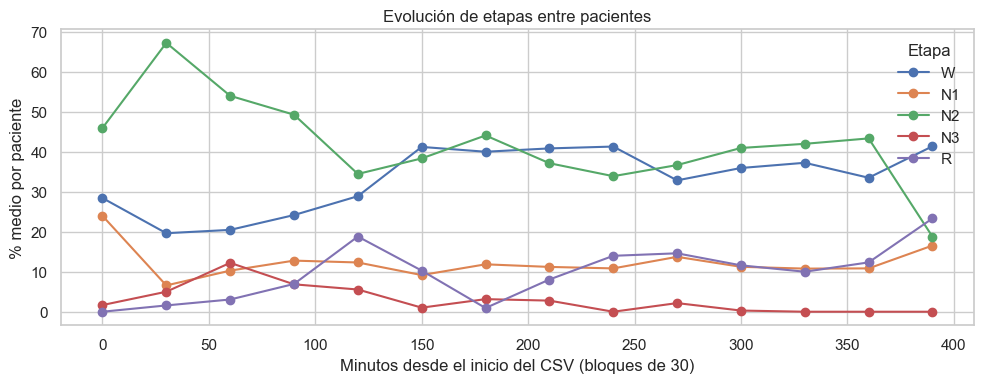

,etapa,auc_global,pacientes_evaluables,mediana_auc_paciente,p25_auc_paciente,p75_auc_paciente
0,W,0.567,18,0.633,0.496,0.678
1,N1,0.471,18,0.458,0.407,0.519
2,N2,0.436,18,0.406,0.344,0.461
3,N3,0.310,7,0.260,0.215,0.295
4,R,0.633,14,0.673,0.506,0.773


AUC descriptiva ≠ rendimiento fuera de muestra; validar la utilidad del tiempo por paciente.


In [120]:
# 3.4.3. Asociación descriptiva etapa-tiempo; sin modificar el dataset.
columnas_tiempo = ['patient_id', 'Sleep_Stage', 'tiempo_relativo_segundos']
faltantes_tiempo = set(columnas_tiempo) - set(df_epochs_all.columns)
if faltantes_tiempo:
    raise ValueError(f'Faltan columnas para el análisis temporal: {faltantes_tiempo}')
temporal = df_epochs_all[columnas_tiempo].copy()
temporal['minuto'] = pd.to_numeric(temporal['tiempo_relativo_segundos'], errors='coerce') / 60
temporal = temporal.loc[np.isfinite(temporal['minuto']) & temporal['minuto'].ge(0)
                        & temporal['Sleep_Stage'].isin(orden_etapas)].copy()
print(f'Análisis temporal: {len(temporal):,} epochs de {temporal.patient_id.nunique()} pacientes')
temporal['bloque_30_min'] = (temporal['minuto'] // 30).astype(int) * 30
conteos_tiempo = temporal.groupby(['patient_id', 'bloque_30_min', 'Sleep_Stage']).size()
conteos_tiempo = conteos_tiempo.unstack(fill_value=0).reindex(columns=orden_etapas, fill_value=0)
conteos_tiempo = conteos_tiempo.loc[conteos_tiempo.sum(axis=1).ge(10)]
proporciones_paciente = conteos_tiempo.div(conteos_tiempo.sum(axis=1), axis=0)
resumen_tiempo = proporciones_paciente.groupby(level='bloque_30_min').mean().mul(100)
resumen_tiempo['pacientes'] = proporciones_paciente.groupby(level='bloque_30_min').size()
print('Porcentaje medio por paciente en cada bloque; no ponderado por duración del registro')
display(resumen_tiempo.round(1))
if not resumen_tiempo.empty:
    ax = resumen_tiempo[orden_etapas].plot(figsize=(10, 4), marker='o')
    ax.set(xlabel='Minutos desde el inicio del CSV (bloques de 30)',
           ylabel='% medio por paciente', title='Evolución de etapas entre pacientes')
    ax.legend(title='Etapa')
    plt.tight_layout()
    plt.show()

def auc_rangos_tiempo(datos, etapa):
    positivos = datos['Sleep_Stage'].eq(etapa)
    n_pos, n_neg = int(positivos.sum()), int((~positivos).sum())
    if not n_pos or not n_neg:
        return np.nan
    rangos = datos['minuto'].rank(method='average')
    return (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

filas_tiempo = []
for etapa in orden_etapas:
    auc_pacientes = [auc_rangos_tiempo(g, etapa) for _, g in temporal.groupby('patient_id')]
    auc_pacientes = pd.Series(auc_pacientes, dtype=float).dropna()
    filas_tiempo.append({'etapa': etapa, 'auc_global': auc_rangos_tiempo(temporal, etapa),
                         'pacientes_evaluables': len(auc_pacientes),
                         'mediana_auc_paciente': auc_pacientes.median(),
                         'p25_auc_paciente': auc_pacientes.quantile(.25),
                         'p75_auc_paciente': auc_pacientes.quantile(.75)})
resumen_auc_tiempo = pd.DataFrame(filas_tiempo)
display(resumen_auc_tiempo.round(3))
print('AUC descriptiva ≠ rendimiento fuera de muestra; validar la utilidad del tiempo por paciente.')


## 3.5. Revisión de características y propuestas experimentales

La tabla siguiente reúne cobertura, variación, asociación descriptiva por etapa y marcas de revisión para las características del dataset base. Las medias y medianas de señales oscilatorias se **marcan para examinar**, no se eliminan. Después se resume si algunas diferencias por etapa mantienen su dirección entre pacientes. Las secciones 3.5.2 y 3.5.3 estudian redundancia y transformaciones; 3.5.4 crea columnas candidatas solo en una copia, sin borrar señales originales. Ninguno de estos criterios sustituye la comparación futura de modelos con partición por paciente.


### 3.5.1. Ficha de variables y consistencia entre pacientes

Cada fila de la primera tabla representa una característica existente. «Pendiente» significa que todavía no se decidió incluirla o excluirla del modelo. La marca de señal oscilatoria advierte que una media cercana a cero puede ser poco informativa sobre amplitud, pero no demuestra que la señal deba quitarse.

La segunda tabla compara, para cada paciente con al menos cinco epochs válidos en ambos grupos, la mediana de una etapa contra la mediana del resto. Para HR, TEMP y EDA utiliza las características `*_median` por epoch, igual que 3.4; luego resume la mediana de las diferencias entre pacientes. Informa cuántos pacientes permiten esa comparación y en qué proporción la diferencia tiene signo positivo. El umbral de cinco epochs es exploratorio para evitar interpretar una mediana de uno o dos epochs; no es un criterio clínico. No se asigna cero a pacientes sin esa etapa. La magnitud de diferencias entre señales con distintas unidades no es comparable. **Reejecutar esta celda:** las salidas guardadas pueden corresponder a `*_mean`.


In [121]:
# 3.5.1. Ficha descriptiva de características y estabilidad entre pacientes
if "resumen_auc_etapa" not in globals():
    raise ValueError("Ejecutar primero el mapa de asociación de la sección 3.4.")

columnas_revision = [c for c in df_epochs_all.columns
                     if c.endswith(("_mean", "_std", "_median"))]
filas_revision = []
for variable in columnas_revision:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    senal, estadistico = variable.rsplit("_", 1)
    marca = (
        "revisar resumen oscilatorio"
        if estadistico in ("mean", "median")
        and senal in set(psg_cols + ["BVP"])
        else "sin marca específica"
    )
    asociaciones = resumen_auc_etapa.loc[
        resumen_auc_etapa["variable"].eq(variable)
        & resumen_auc_etapa["direccion"].notna()
    ]
    mayor = (
        asociaciones.loc[asociaciones["direccion"].abs().idxmax()]
        if not asociaciones.empty else None
    )
    filas_revision.append({
        "variable": variable,
        "marca_revision": marca,
        "cobertura_pct": 100 * validos.mean(),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "valores_distintos": valores.loc[validos].nunique(),
        "iqr": valores.loc[validos].quantile(0.75)
               - valores.loc[validos].quantile(0.25) if validos.any() else np.nan,
        "etapa_mayor_asociacion": mayor["Sleep_Stage"] if mayor is not None else None,
        "direccion_mayor": mayor["direccion"] if mayor is not None else np.nan,
        "decision_modelo": "pendiente",
    })
revision_caracteristicas = pd.DataFrame(filas_revision)
print("FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA")
with pd.option_context("display.max_rows", 100):
    display(revision_caracteristicas.round(3))

variables_estabilidad = [c for c in [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std",
    "ACC_X_std", "C4-M1_std", "E1_std", "FLOW_std",
] if c in df_epochs_all.columns]
min_epochs_comparacion = 5
filas_estabilidad = []
for variable in variables_estabilidad:
    datos = df_epochs_all[["patient_id", "Sleep_Stage", variable]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.loc[np.isfinite(datos[variable])]
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = datos["Sleep_Stage"].eq(etapa)
        dentro = datos.loc[en_etapa].groupby("patient_id")[variable].agg(
            mediana_etapa="median", epochs_etapa="size"
        )
        fuera = datos.loc[~en_etapa].groupby("patient_id")[variable].agg(
            mediana_resto="median", epochs_resto="size"
        )
        pares = dentro.join(fuera, how="inner")
        pares = pares.loc[
            pares["epochs_etapa"].ge(min_epochs_comparacion)
            & pares["epochs_resto"].ge(min_epochs_comparacion)
        ]
        diferencias = pares["mediana_etapa"] - pares["mediana_resto"]
        filas_estabilidad.append({
            "variable": variable, "Sleep_Stage": etapa,
            "pacientes_evaluables": len(pares),
            "mediana_diferencia": diferencias.median() if len(pares) else np.nan,
            "pacientes_diferencia_positiva_pct":
                100 * diferencias.gt(0).mean() if len(pares) else np.nan,
        })
resumen_estabilidad = pd.DataFrame(filas_estabilidad)
print("DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA")
display(resumen_estabilidad.round(2))


FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA


,variable,marca_revision,cobertura_pct,pacientes_con_valor,valores_distintos,iqr,etapa_mayor_asociacion,direccion_mayor,decision_modelo
0,BVP_mean,revisar resumen oscilatorio,100.0,18,13164,0.342,None,NaN,pendiente
1,BVP_std,sin marca específica,100.0,18,13143,45.830,W,0.431,pendiente
2,BVP_median,revisar resumen oscilatorio,100.0,18,12670,5.176,None,NaN,pendiente
3,HR_mean,sin marca específica,100.0,18,13146,17.297,None,NaN,pendiente
4,HR_std,sin marca específica,100.0,18,13144,0.651,N2,-0.302,pendiente
5,HR_median,sin marca específica,100.0,18,3340,17.300,N3,-0.214,pendiente
6,EDA_mean,sin marca específica,100.0,18,13059,0.338,None,NaN,pendiente
7,EDA_std,sin marca específica,100.0,18,13064,0.003,W,0.244,pendiente
8,EDA_median,sin marca específica,100.0,18,5242,0.338,N3,0.239,pendiente
9,TEMP_mean,sin marca específica,100.0,18,12893,3.317,None,NaN,pendiente


DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA


,variable,Sleep_Stage,pacientes_evaluables,mediana_diferencia,pacientes_diferencia_positiva_pct
0,HR_median,W,18,2.68,83.33
1,HR_median,N1,18,0.24,55.56
2,HR_median,N2,18,-0.77,33.33
3,HR_median,N3,5,0.73,60.00
4,HR_median,R,14,-1.29,28.57
5,TEMP_median,W,18,-0.18,33.33
6,TEMP_median,N1,18,-0.07,33.33
7,TEMP_median,N2,18,0.05,55.56
8,TEMP_median,N3,5,0.09,60.00
9,TEMP_median,R,14,0.11,64.29


### 3.5.2. Redundancia y posibles resúmenes por familia de señales

Una variable puede **compartir información** con otra sin explicarla causalmente. La tabla contrasta Spearman global con la mediana de Spearman calculada por paciente: una correlación alta solo a nivel global puede reflejar diferencias entre personas. Ningún par se elimina ni se fusiona aquí.

- **Ojos (`E1_std`, `E2_std`):** comparar ambos canales con un resumen bilateral (por ejemplo, el máximo para conservar actividad unilateral). No fusionar antes de revisar diferencias laterales y cobertura.
- **Piernas (`LAT_std`, `RAT_std`):** mantener izquierda y derecha por ahora; un movimiento unilateral puede perderse en una media. El máximo bilateral es solo un experimento posterior.
- **Acelerómetro (`ACC_X_std`, `ACC_Y_std`, `ACC_Z_std`):** no elegir X+Z y descartar Y sin evidencia. Comparar los tres ejes con una magnitud `sqrt(X_std²+Y_std²+Z_std²)` calculada por epoch; no representa exactamente la desviación de la magnitud cruda.
- **EEG:** C4-M1/F4-M1 y T3-CZ/CZ-T4 son pares muy correlacionados, pero pueden aportar información espacial distinta. Probar una ablación por familia en pacientes no vistos.
- **Media frente a mediana:** examinar HR, TEMP y EDA; no conservar ambas por costumbre ni borrar una por correlación alta. La diferencia puede señalar picos o artefactos y también contener información legítima.

In [122]:
# 3.5.2. Correlaciones para priorizar ablaciones; no se podan columnas.
pares_familias = [
    ('E1_std', 'E2_std', 'ojos'), ('LAT_std', 'RAT_std', 'piernas'),
    ('ACC_X_std', 'ACC_Y_std', 'ACC'), ('ACC_X_std', 'ACC_Z_std', 'ACC'),
    ('ACC_Y_std', 'ACC_Z_std', 'ACC'),
    ('C4-M1_std', 'F4-M1_std', 'EEG'),
    ('T3 - CZ_std', 'CZ - T4_std', 'EEG'),
    ('HR_mean', 'HR_median', 'nivel'),
    ('TEMP_mean', 'TEMP_median', 'nivel'),
    ('EDA_mean', 'EDA_median', 'nivel'),
    ('EDA_median', 'EDA_std', 'EDA'),
]
def spearman_sin_orden_objetivo(grupo, col_a, col_b):
    valores = grupo[[col_a, col_b]].apply(pd.to_numeric, errors='coerce')
    valores = valores.replace([np.inf, -np.inf], np.nan).dropna()
    if len(valores) < 10 or valores[col_a].nunique() < 2 or valores[col_b].nunique() < 2:
        return np.nan
    return valores[col_a].rank().corr(valores[col_b].rank())

filas_redundancia = []
for col_a, col_b, familia in pares_familias:
    if not {col_a, col_b}.issubset(df_epochs_all.columns):
        continue
    por_paciente = pd.Series([
        spearman_sin_orden_objetivo(g, col_a, col_b)
        for _, g in df_epochs_all.groupby('patient_id')
    ], dtype=float).dropna()
    filas_redundancia.append({
        'familia': familia, 'variable_1': col_a, 'variable_2': col_b,
        'spearman_global': spearman_sin_orden_objetivo(df_epochs_all, col_a, col_b),
        'mediana_spearman_paciente': por_paciente.median(),
        'pacientes_evaluables': len(por_paciente),
    })
resumen_redundancia = pd.DataFrame(filas_redundancia)
display(resumen_redundancia.round(3))
print('Correlación alta sugiere comparación; no demuestra causalidad ni autoriza poda.')


,familia,variable_1,variable_2,spearman_global,mediana_spearman_paciente,pacientes_evaluables
0,ojos,E1_std,E2_std,0.854,0.869,18
1,piernas,LAT_std,RAT_std,0.480,0.403,18
2,ACC,ACC_X_std,ACC_Y_std,0.599,0.538,18
3,ACC,ACC_X_std,ACC_Z_std,0.651,0.534,18
4,ACC,ACC_Y_std,ACC_Z_std,0.590,0.478,18
5,EEG,C4-M1_std,F4-M1_std,0.930,0.935,18
6,EEG,T3 - CZ_std,CZ - T4_std,0.905,0.920,18
7,nivel,HR_mean,HR_median,1.000,0.998,18
8,nivel,TEMP_mean,TEMP_median,1.000,1.000,18
9,nivel,EDA_mean,EDA_median,0.999,0.999,18


Correlación alta sugiere comparación; no demuestra causalidad ni autoriza poda.


### 3.5.3. Diagnóstico previo a transformaciones numéricas

Se describen dominio, ceros y cola alta de candidatos. `log1p(x)=ln(1+x)` solo se plantea para valores no negativos y suficientemente grandes respecto de la unidad elegida; no corrige defectos de sensor. Para EEG/EOG/PSG `*_std` muy pequeños, `log1p(x)` casi no modifica la distribución: primero comprobar unidades y comparar escalado robusto en una copia de entrenamiento. Una asimetría alta tampoco obliga a transformar: en árboles, una transformación monótona suele conservar el orden de los valores. No se modifica el CSV base.

In [123]:
# 3.5.3. Elegibilidad descriptiva de log1p; sin aplicar la transformación.
candidatas_log = ['BVP_std', 'EDA_median', 'EDA_std',
                  'ACC_X_std', 'ACC_Y_std', 'ACC_Z_std',
                  'LAT_std', 'RAT_std', 'E1_std', 'E2_std']
filas_transformacion = []
for variable in candidatas_log:
    if variable not in df_epochs_all.columns:
        continue
    x = pd.to_numeric(df_epochs_all[variable], errors='coerce')
    x = x.loc[np.isfinite(x)]
    filas_transformacion.append({
        'variable': variable, 'valores_finitos': len(x),
        'negativos': int(x.lt(0).sum()), 'ceros_pct': 100 * x.eq(0).mean(),
        'mediana': x.median(), 'p99': x.quantile(.99),
        'asimetria': x.skew(),
        'log1p_directo_elegible': bool(x.ge(0).all() and x.quantile(.99) >= 1),
    })
resumen_transformacion = pd.DataFrame(filas_transformacion)
display(resumen_transformacion.round(4))
print('Elegible significa que vale la pena probarlo; no implica limpiar ni transformarlo ahora.')


,variable,valores_finitos,negativos,ceros_pct,mediana,p99,asimetria,log1p_directo_elegible
0,BVP_std,13165,0,0.1215,36.4322,221.0251,2.1126,True
1,EDA_median,13165,0,0.9495,0.2373,24.2671,7.8158,True
2,EDA_std,13165,0,0.7596,0.0015,0.4108,17.9856,False
3,ACC_X_std,13165,0,6.4717,0.3963,26.8427,4.2997,True
4,ACC_Y_std,13165,0,8.7733,0.3400,20.8859,5.5572,True
5,ACC_Z_std,13165,0,3.0460,0.3959,25.5843,5.0750,True
6,LAT_std,13165,0,0.0076,0.0000,0.0001,8.3550,False
7,RAT_std,13165,0,0.0076,0.0000,0.0002,4.4438,False
8,E1_std,13165,0,0.0076,0.0000,0.0001,13.2127,False
9,E2_std,13165,0,0.0076,0.0000,0.0001,16.6365,False


Elegible significa que vale la pena probarlo; no implica limpiar ni transformarlo ahora.


### 3.5.4. Columnas candidatas en una copia reversible

Se agregan `log1p` de BVP_std, EDA_median y ACC `*_std` cuando son no negativos, máximo bilateral de E1/E2 y LAT/RAT, y una norma de las tres dispersiones ACC. **No se quitan originales**, no se invalida ningún valor y no se guarda un CSV nuevo. EDA S004/S057 sigue pendiente de revisión. Son alternativas para comparar después en entrenamiento/validación por paciente, no un conjunto de predictores ya seleccionado.

In [124]:
# 3.5.4. Crear alternativas reversibles; sin poda ni cambios al CSV base.
if 'df_epochs_all' not in globals() or df_epochs_all.empty:
    raise ValueError('Primero ejecutar la sección 3.1.')
df_epochs_features = df_epochs_all.copy()
columnas_originales = set(df_epochs_features.columns)
for variable in ['BVP_std', 'EDA_median', 'ACC_X_std', 'ACC_Y_std', 'ACC_Z_std']:
    if variable not in df_epochs_features.columns:
        continue
    x = pd.to_numeric(df_epochs_features[variable], errors='coerce')
    if (x.dropna() < 0).any():
        print(f'{variable}: contiene negativos; no se crea log1p.')
        continue
    df_epochs_features[f'{variable}_log1p'] = np.log1p(x)

# Máximo bilateral conserva episodios de un solo lado; no reemplaza canales.
for nuevo, canales in {
    'EOG_max_std': ['E1_std', 'E2_std'],
    'LEG_max_std': ['LAT_std', 'RAT_std'],
}.items():
    if set(canales).issubset(df_epochs_features.columns):
        valores = df_epochs_features[canales].apply(pd.to_numeric, errors='coerce')
        df_epochs_features[nuevo] = valores.max(axis=1, skipna=False)
ejes_acc = ['ACC_X_std', 'ACC_Y_std', 'ACC_Z_std']
if set(ejes_acc).issubset(df_epochs_features.columns):
    valores = df_epochs_features[ejes_acc].apply(pd.to_numeric, errors='coerce')
    df_epochs_features['ACC_std_norma'] = np.sqrt(
        valores.pow(2).sum(axis=1, min_count=3))
nuevas = sorted(set(df_epochs_features.columns) - columnas_originales)
print('Copia experimental:', df_epochs_features.shape, '| base:', df_epochs_all.shape)
print('Columnas candidatas nuevas:', nuevas)
print('Columnas originales conservadas:', columnas_originales.issubset(df_epochs_features.columns))
display(df_epochs_features[['patient_id', 'epoch', *nuevas]].head())

Copia experimental: (13165, 136) | base: (13165, 128)
Columnas candidatas nuevas: ['ACC_X_std_log1p', 'ACC_Y_std_log1p', 'ACC_Z_std_log1p', 'ACC_std_norma', 'BVP_std_log1p', 'EDA_median_log1p', 'EOG_max_std', 'LEG_max_std']
Columnas originales conservadas: True


,patient_id,epoch,ACC_X_std_log1p,ACC_Y_std_log1p,ACC_Z_std_log1p,ACC_std_norma,BVP_std_log1p,EDA_median_log1p,EOG_max_std,LEG_max_std
0,2,0,0.475493,0.337505,0.352321,0.842732,1.936784,0.076414,0.000017,0.000005
1,2,1,2.484531,2.851304,1.842927,20.375900,4.253210,0.075226,0.000021,0.000017
2,2,2,2.968606,2.366207,3.309044,33.600558,4.444191,0.076414,0.000042,0.000028
3,2,3,1.808811,0.844746,1.194926,5.754105,4.228881,0.076414,0.000030,0.000006
4,2,4,1.246906,0.878764,1.083046,3.456481,2.430748,0.076414,0.000029,0.000007


## 3.6. Variación de etapas entre pacientes

Esta sección resume todos los pacientes en una tabla y en gráficos globales; no genera un hipnograma por persona. Cada proporción usa los epochs conservados de ese paciente. La duración válida cuenta epochs conservados, mientras que el tramo observado entre el primero y el último también incluye posibles huecos. Una etapa ausente significa «no observada en los epochs conservados», no incapacidad fisiológica de alcanzarla.

La latencia REM se mide desde el **primer epoch de sueño observado** (N1, N2, N3 o R) hasta el primer epoch REM. Si REM no aparece, la latencia queda faltante y se informa «no observado»; no se reemplaza por cero. Las transiciones se cuentan solo entre etiquetas de epochs consecutivos. Un salto por epochs descartados se registra aparte y no se interpreta como transición directa. Proporciones, latencias y transiciones usan `Sleep_Stage` y son únicamente auditoría descriptiva: no pueden entrar como predictores del modelo de esa misma etiqueta. Ningún paciente se excluye por REM temprano, ausencia de REM o ausencia de N3.


PACIENTES RESUMIDOS: 18
SIN REM OBSERVADO: 4
SIN N3 OBSERVADO: 11
RESUMEN POR PACIENTE; SIN EXCLUSIONES


,patient_id,epochs_validos,duracion_valida_min,tramo_observado_min,saltos_entre_epochs,transiciones_contiguas,etapas_ausentes,estado_rem,latencia_rem_desde_primer_sueno_min,epochs_W,pct_W,epochs_N1,pct_N1,epochs_N2,pct_N2,epochs_N3,pct_N3,epochs_R,pct_R,HR_missing_frac_promedio,BVP_missing_frac_promedio,C4-M1_missing_frac_promedio,filas_fragmento_inicial,filas_fragmento_final,epochs_descartados_por_pureza,continuidad_temporal
0,2,652,326.0,326.0,0,188,N3,observado,159.5,174,26.687117,64,9.815951,334,51.226994,0,0.000000,80,12.269939,0.0,0.0,0.0,2400,0,0,verificada en segmentos recuperados
1,3,773,386.5,386.5,0,72,ninguna,observado,96.0,58,7.503234,32,4.139715,428,55.368693,136,17.593790,119,15.394567,0.0,0.0,0.0,2400,0,0,verificada en segmentos recuperados
2,4,804,402.0,402.0,0,274,R,no observado,NaN,216,26.865672,163,20.273632,424,52.736318,1,0.124378,0,0.000000,0.0,0.0,0.0,1100,0,0,verificada en segmentos recuperados
3,5,730,365.0,365.0,0,121,ninguna,observado,98.0,90,12.328767,39,5.342466,480,65.753425,5,0.684932,116,15.890411,0.0,0.0,0.0,1300,0,0,verificada en segmentos recuperados
4,6,801,400.5,400.5,0,191,R,no observado,NaN,210,26.217228,123,15.355805,290,36.204744,178,22.222222,0,0.000000,0.0,0.0,0.0,0,0,0,verificada en segmentos recuperados
5,7,797,398.5,398.5,0,144,ninguna,observado,120.5,405,50.815558,26,3.262233,299,37.515684,26,3.262233,41,5.144291,0.0,0.0,0.0,0,0,0,verificada en segmentos recuperados
6,8,743,371.5,371.5,0,104,ninguna,observado,41.5,53,7.133244,43,5.787349,421,56.662180,89,11.978466,137,18.438762,0.0,0.0,0.0,2500,0,0,verificada en segmentos recuperados
7,9,766,383.0,383.0,0,110,ninguna,observado,113.5,211,27.545692,67,8.746736,409,53.394256,3,0.391645,76,9.921671,0.0,0.0,0.0,400,0,0,verificada en segmentos recuperados
8,10,795,397.5,397.5,0,158,N3,observado,270.5,127,15.974843,124,15.597484,458,57.610063,0,0.000000,86,10.817610,0.0,0.0,0.0,100,0,0,verificada en segmentos recuperados
9,16,750,375.0,375.0,0,103,N3,observado,156.0,226,30.133333,299,39.866667,169,22.533333,0,0.000000,56,7.466667,0.0,0.0,0.0,400,0,0,verificada en segmentos recuperados


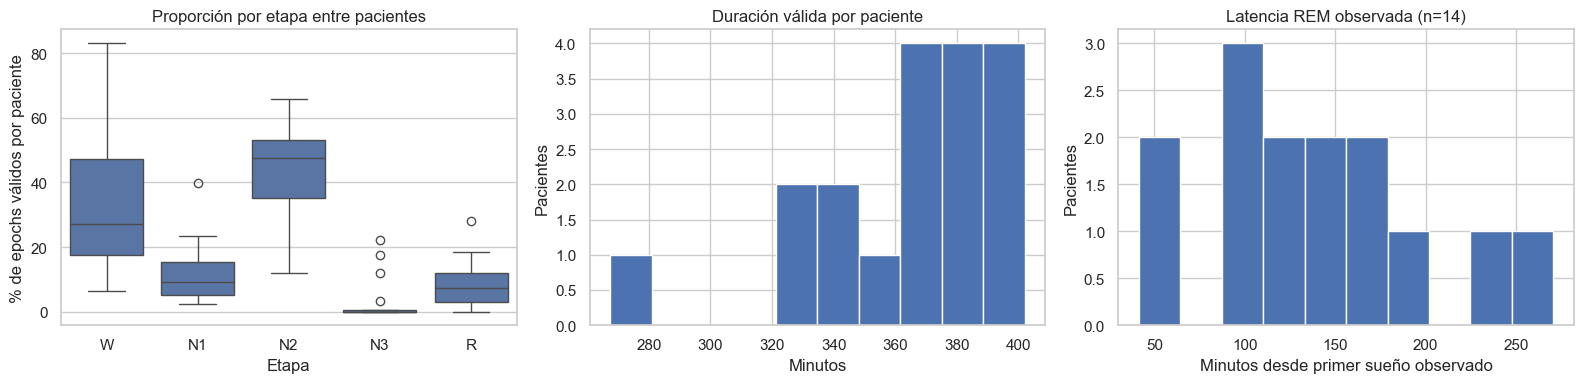

Los gráficos muestran variación descriptiva, no calidad del sueño ni un criterio de exclusión de pacientes.


In [125]:
# 3.6. Resumen descriptivo de etapas por paciente
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset consolidado de epochs.")
if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves paciente/epoch duplicadas.")
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas faltantes o inválidas.")

resumen_filas = []
for patient_id, grupo in df_epochs_all.groupby("patient_id", sort=True):
    grupo = grupo.sort_values("epoch")
    conteos = grupo["Sleep_Stage"].value_counts().reindex(
        orden_etapas, fill_value=0
    )
    primer_sueno = grupo.loc[
        grupo["Sleep_Stage"].ne("W"), "epoch"
    ].min()
    primer_rem = grupo.loc[
        grupo["Sleep_Stage"].eq("R"), "epoch"
    ].min()
    latencia_rem = (
        (primer_rem - primer_sueno) * 0.5
        if pd.notna(primer_sueno) and pd.notna(primer_rem) else np.nan
    )
    diferencias_epoch = grupo["epoch"].diff()
    transiciones = int((
        diferencias_epoch.eq(1)
        & grupo["Sleep_Stage"].ne(grupo["Sleep_Stage"].shift())
    ).sum())
    fila = {
        "patient_id": patient_id,
        "epochs_validos": len(grupo),
        "duracion_valida_min": len(grupo) * 0.5,
        "tramo_observado_min":
            (grupo["epoch"].max() - grupo["epoch"].min() + 1) * 0.5,
        "saltos_entre_epochs": int(diferencias_epoch.gt(1).sum()),
        "transiciones_contiguas": transiciones,
        "etapas_ausentes": ", ".join(conteos.index[conteos.eq(0)]) or "ninguna",
        "estado_rem": "observado" if pd.notna(primer_rem) else "no observado",
        "latencia_rem_desde_primer_sueno_min": latencia_rem,
    }
    for etapa in orden_etapas:
        fila[f"epochs_{etapa}"] = int(conteos[etapa])
        fila[f"pct_{etapa}"] = 100 * conteos[etapa] / len(grupo)
    for calidad in ["HR_missing_frac", "BVP_missing_frac", "C4-M1_missing_frac"]:
        if calidad in grupo.columns:
            fila[f"{calidad}_promedio"] = grupo[calidad].mean()
    resumen_filas.append(fila)

resumen_pacientes = pd.DataFrame(resumen_filas).sort_values(
    "patient_id"
).reset_index(drop=True)
if "auditoria_epochs" in globals():
    columnas_auditoria = [c for c in [
        "patient_id", "filas_fragmento_inicial", "filas_fragmento_final",
        "epochs_descartados_por_pureza", "continuidad_temporal",
    ] if c in auditoria_epochs.columns]
    if "patient_id" in columnas_auditoria:
        resumen_pacientes = resumen_pacientes.merge(
            auditoria_epochs[columnas_auditoria], on="patient_id",
            how="left", validate="one_to_one",
        )

print("PACIENTES RESUMIDOS:", len(resumen_pacientes))
print("SIN REM OBSERVADO:", resumen_pacientes["epochs_R"].eq(0).sum())
print("SIN N3 OBSERVADO:", resumen_pacientes["epochs_N3"].eq(0).sum())
print("RESUMEN POR PACIENTE; SIN EXCLUSIONES")
display(resumen_pacientes)

proporciones = resumen_pacientes.melt(
    id_vars="patient_id", value_vars=[f"pct_{e}" for e in orden_etapas],
    var_name="etapa", value_name="porcentaje_epochs",
)
proporciones["etapa"] = proporciones["etapa"].str.removeprefix("pct_")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=proporciones, x="etapa", y="porcentaje_epochs",
            order=orden_etapas, ax=axes[0], showfliers=True)
axes[0].set_title("Proporción por etapa entre pacientes")
axes[0].set_xlabel("Etapa")
axes[0].set_ylabel("% de epochs válidos por paciente")
axes[1].hist(resumen_pacientes["duracion_valida_min"].dropna())
axes[1].set_title("Duración válida por paciente")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Pacientes")
latencias_rem = resumen_pacientes[
    "latencia_rem_desde_primer_sueno_min"
].dropna()
if not latencias_rem.empty:
    axes[2].hist(latencias_rem)
axes[2].set_title(f"Latencia REM observada (n={len(latencias_rem)})")
axes[2].set_xlabel("Minutos desde primer sueño observado")
axes[2].set_ylabel("Pacientes")
plt.tight_layout()
plt.show()
print(
    "Los gráficos muestran variación descriptiva, no calidad del sueño "
    "ni un criterio de exclusión de pacientes."
)


## 3.7. Controles de rangos sin alterar el dataset

Se revisan reglas lógicas que no dependen de límites clínicos: desviaciones estándar no negativas, recuentos de muestras válidas entre 0 y 3000, fracciones de faltantes y pureza entre 0 y 1, y coherencia entre recuento y fracción de faltantes. El reporte indica epochs y pacientes afectados y conserva casos para inspección. **No corrige ni excluye filas**; una violación requiere volver al CSV fuente y justificar la causa antes de decidir tratamiento.

Por separado se describen ceros, cobertura, cuantiles y extremos observados de HR, TEMP, EDA, IBI y SAO2 cuando estén presentes. Estos números no son umbrales de recorte. En particular, no se comprueba `SAO2_mean` contra [0, 1] mientras no se confirme si la fuente usa fracción, porcentaje u otra escala. Tampoco se aplican máximos universales a BVP, aceleración o PSG. Las medias oscilatorias próximas a cero no son errores lógicos.


In [127]:
# 3.7. Controles lógicos de rangos, sin recorte
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset de epochs.")

reglas_rango = []
for col in df_epochs_all.columns:
    if col.endswith("_std"):
        reglas_rango.append((col, "desviación estándar negativa",
                             lambda v: v.lt(0)))
    elif col.endswith("_n_valid"):
        reglas_rango.append((col, "recuento fuera de [0, 3000] o no entero",
                             lambda v: v.lt(0) | v.gt(3000) | v.ne(v.round())))
    elif col.endswith("_missing_frac") or col == "porcentaje_pureza":
        reglas_rango.append((col, "fracción fuera de [0, 1]",
                             lambda v: v.lt(0) | v.gt(1)))

filas_controles = []
casos_controles = []
for variable, regla, criterio in reglas_rango:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    definidos = valores.notna()
    infraccion = definidos & (~np.isfinite(valores) | criterio(valores))
    filas_controles.append({
        "variable": variable, "regla": regla,
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~definidos).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = variable
        casos["regla"] = regla
        casos["valor"] = valores.loc[infraccion]
        casos_controles.append(casos)

for senal in [c.removesuffix("_n_valid") for c in df_epochs_all.columns
              if c.endswith("_n_valid")]:
    n_valid = pd.to_numeric(df_epochs_all[f"{senal}_n_valid"], errors="coerce")
    faltantes = pd.to_numeric(
        df_epochs_all[f"{senal}_missing_frac"], errors="coerce"
    )
    comparables = np.isfinite(n_valid) & np.isfinite(faltantes)
    infraccion = comparables & (
        faltantes.sub(1 - n_valid / 3000).abs().gt(1e-4)
    )
    filas_controles.append({
        "variable": senal,
        "regla": "recuento y fracción de faltantes inconsistentes",
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~comparables).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = senal
        casos["regla"] = "recuento y fracción de faltantes inconsistentes"
        casos["valor"] = faltantes.loc[infraccion]
        casos_controles.append(casos)

resumen_controles_rango = pd.DataFrame(filas_controles)
casos_controles_rango = (
    pd.concat(casos_controles, ignore_index=True)
    if casos_controles else pd.DataFrame(columns=[
        "patient_id", "epoch", "Sleep_Stage", "variable", "regla", "valor"
    ])
)
print("REGLAS LÓGICAS CON VIOLACIONES")
violaciones = resumen_controles_rango.loc[
    resumen_controles_rango["epochs_afectados"].gt(0)
]
display(violaciones if not violaciones.empty else "Sin violaciones detectadas")
print("CASOS PARA RASTREAR EN EL CSV FUENTE")
display(casos_controles_rango.head(20))
resumen_controles_etapa = (
    casos_controles_rango.groupby(["variable", "regla", "Sleep_Stage"])
    .agg(epochs_afectados=("epoch", "size"),
         pacientes_afectados=("patient_id", "nunique"))
    .reset_index()
)
print("VIOLACIONES POR ETAPA")
display(resumen_controles_etapa)

filas_niveles = []
for variable in [
    "HR_mean", "IBI_mean", "TEMP_mean", "EDA_mean", "SAO2_mean",
    "BVP_std", "ACC_X_std", "C4-M1_std",
]:
    if variable not in df_epochs_all.columns:
        continue
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    observados = valores.loc[validos]
    ceros = validos & valores.eq(0)
    filas_niveles.append({
        "variable": variable,
        "epochs_con_valor": int(validos.sum()),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "epochs_cero": int(ceros.sum()),
        "pacientes_con_ceros": df_epochs_all.loc[ceros, "patient_id"].nunique(),
        "minimo": observados.min(),
        "p01": observados.quantile(0.01),
        "mediana": observados.median(),
        "p99": observados.quantile(0.99),
        "maximo": observados.max(),
    })
resumen_niveles = pd.DataFrame(filas_niveles)
print("VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES")
display(resumen_niveles.round(3))
print("SAO2: escala pendiente de confirmación; no se aplica rango físico.")


REGLAS LÓGICAS CON VIOLACIONES


'Sin violaciones detectadas'

CASOS PARA RASTREAR EN EL CSV FUENTE


,patient_id,epoch,Sleep_Stage,variable,regla,valor


VIOLACIONES POR ETAPA


,variable,regla,Sleep_Stage,epochs_afectados,pacientes_afectados


VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES


,variable,epochs_con_valor,pacientes_con_valor,epochs_cero,pacientes_con_ceros,minimo,p01,mediana,p99,maximo
0,HR_mean,13165,18,0,0,42.392,47.066,64.203,104.961,127.279
1,TEMP_mean,13165,18,0,0,25.595,26.477,34.005,36.955,37.196
2,EDA_mean,13165,18,85,2,0.000,0.005,0.238,24.264,52.850
3,BVP_std,13165,18,16,16,0.000,1.708,36.432,221.025,402.941
4,ACC_X_std,13165,18,852,18,0.000,0.000,0.396,26.843,52.364
5,C4-M1_std,13165,18,1,1,0.000,0.000,0.000,0.000,0.001


SAO2: escala pendiente de confirmación; no se aplica rango físico.


### 3.8. Estado del ETL y decisiones pendientes

**Estado:** el ETL ya transformó señales crudas en un dataset único de epochs de 30 segundos. Esta sección distingue lo ejecutado, las marcas de revisión y las transformaciones **propuestas para copias de modelado**; ninguna poda, recorte o balanceo adicional se aplica aquí. La sección 3.1 marca etiquetas imputadas y recupera solo segmentos verificables de S027/S048; la sección 3.2 conserva la auditoría. Véase ADR 0012.

| Decisión | Estado actual |
| :--- | :--- |
| Ventanas | 30 segundos (3000 muestras), alineadas por paciente. Solo se conservan epochs completos con una misma etiqueta válida en todas sus muestras. |
| Dataset | Un único `dataset_epochs_v1.csv`, ordenado por `patient_id` y `epoch`; no se generan datasets completos por paciente. |
| Trazabilidad | `auditoria_epochs.csv` documenta archivos, exclusiones, fragmentos, epochs conservados y descartados; `epochs_descartados.csv` detalla ventanas rechazadas. |
| Señales | 24 señales incluidas en esta versión, con media, desviación estándar, mediana y cobertura por epoch. IBI y SAO2 quedan fuera de las características hasta revisar disponibilidad y calidad. |
| Apneas | Las anotaciones permanecen en los CSV originales, pero no son predictores del modelo principal. |
| EDA y otros extremos | Distribuciones, IQR y vistas temporales generan marcas de revisión, no correcciones automáticas ni prueba de utilidad predictiva. |
| Transformaciones pendientes | No hay recorte de extremos, imputación de señales, normalización, balanceo ni poda automática. Se imputaron tres etiquetas aisladas con vecinos concordantes, conservando la marca de auditoría. La sección 3.5.4 crea columnas candidatas únicamente en memoria y conserva todas las originales. |
| Modelado | Diferido según ADR 0011; no se entrenó ni evaluó ningún algoritmo. |

En la ejecución amplia comunicada por el equipo se auditaron **74 archivos**, se incluyeron **73** (71 completos y 2 parciales; **aunque esto puede cambiar si se agregan más pacientes**), se excluyó S097 y se obtuvieron más de **50.000 epochs**. La ejecución local anterior con 18 archivos y 13.165 epochs es una cohorte distinta y no debe usarse para describir este resultado. Quedan por contrastar la auditoría de alineación de S027/S048 y la salida de los controles lógicos de 3.7.

**Señales marcadas para revisión, sin corrección automática** (cifras de la ejecución amplia):

| Caso | Evidencia y motivo de la marca | Alternativas después de verificar la fuente | Estado actual |
| :--- | :--- | :--- | :--- |
| EDA de S004 | La señal pasa de un nivel bajo a una elevación sostenida hacia el final. Hay movimiento previo, pero la coincidencia temporal no prueba artefacto ni causalidad. Los epochs con EDA alta no son por sí mismos inválidos. | Comparar nivel de cada eje ACC antes/después, continuidad, contacto y escala; conservar si la señal es plausible; corregir una conversión demostrada o invalidar solo EDA en el tramo defectuoso confirmado. | **Pendiente de revisión**; paciente y epochs conservados. |
| EDA de S057 | Se observó una subida pronunciada seguida de descenso prolongado y un epoch con `EDA_std` especialmente alto. No se confirmó un error instrumental. | Revisar señal cruda, contacto, ACC y cobertura antes/después; conservar si es plausible o invalidar solo el tramo EDA si se confirma defecto. | **Pendiente de revisión**; paciente y epochs conservados. |
| TEMP baja | `TEMP_median` alcanza 20,31 en la cohorte; el IQR global marca 1.484 epochs de 9 pacientes por debajo de su límite inferior estadístico de 27,76. La temperatura del wearable puede variar por persona, ambiente o contacto; el IQR no define un límite físico. | Localizar pacientes y tramos, confirmar unidad, dispositivo, continuidad y otras señales; conservar una variación plausible, corregir escala demostrada o invalidar solo TEMP afectada si hay defecto confirmado. | **Pendiente de revisión**; sin recorte ni exclusión. |

Marcar para revisión es una conclusión de auditoría, **no** un nuevo predictor ni una modificación de `df_epochs_all`. No se elimina al paciente completo ni se recortan valores por superar 1,5 × IQR. La decisión y su impacto en cobertura por epoch deberán documentarse antes de cualquier cambio del ETL; véanse ADR 0005 y el plan de transformación.

#### Transformaciones posibles: motivo y momento

| Propuesta | Por qué y para qué | Condición / estado |
| :--- | :--- | :--- |
| Corregir o invalidar **solo una señal/tramo** | Evitar que una falla instrumental confirmada contamine sus resúmenes por epoch sin perder otras señales y la etiqueta válida. | Primero revisar CSV crudo, unidades, continuidad y cobertura; S004/S057 y TEMP baja siguen como hipótesis, sin cambio aplicado. |
| Elegir resúmenes por señal | `HR_median`, `TEMP_median` y `EDA_median` representan niveles robustos ante picos; `BVP_std`, `ACC_*_std` y PSG `*_std` conservan información de variación que una media oscilatoria puede cancelar. | Son candidatas para el modelo, no una orden de borrar todas las medias/medianas del dataset. Comparar calidad y aporte incremental por paciente. |
| Transformar colas asimétricas (`log1p`, si procede) | Reducir la influencia de valores muy altos de características no negativas como algunas dispersiones de EDA, BVP o ACC. No arregla artefactos ni exige volver normal una distribución. | Probar solo en copia de modelado y comparar con la versión sin transformar; revisar dominio y ajustar cualquier parámetro únicamente en entrenamiento. |
| Escalar predictores | Evitar que las distintas unidades dominen la optimización y facilitar una regresión logística regularizada; comparar escalado estándar y robusto si persisten colas largas. | Ajustar escalador solo con pacientes de entrenamiento; aplicar igual a validación/prueba. No escalar `Sleep_Stage`. |
| Ponderar clases | Dar más relevancia a errores en N3/R sin inventar epochs ni alterar el CSV entregable. | Experimento de modelado posterior; calcular pesos en entrenamiento y evaluar precisión/recuperación por etapa en pacientes no vistos. |

La antigua propuesta de 3.5 que borraba todas las medianas y fusionaba canales se sustituyó por 3.5.4: ahora se crean alternativas en una copia sin poda. Esas columnas nuevas no entran automáticamente al modelo; primero se compararán con las originales.

#### Columnas: conservar en el CSV base, seleccionar en una copia de modelado

- **Conservar en el CSV, separar del modelo inicial:** `Sleep_Stage` es la etiqueta; `patient_id` identifica grupos para entrenamiento/validación por paciente, pero no entra a `X` si se busca generalizar a personas nuevas. `epoch` se conserva como clave secuencial; `tiempo_relativo_segundos` se conserva como tiempo real transcurrido y se prueba aparte en 3.4.3. `TIMESTAMP` absoluto no entra al modelo inicial. `Sleep_Stage_num`, si existiera, sería una codificación artificial de la etiqueta. Las anotaciones de apnea tampoco entran al modelo principal.
- **Metadatos de calidad, no predictores iniciales:** `porcentaje_pureza`, `porcentaje_pureza_original`, `etiqueta_imputada`, `*_n_valid` y `*_missing_frac`. Se conservan para auditoría y filtrado justificado; incluirlos luego solo si están disponibles al inferir y no codifican el procedimiento de etiquetado ni la identidad del paciente.
- **Candidatas a retirar únicamente tras comparación:** de HR/TEMP/EDA, comparar `*_mean` frente a `*_median` (mediana como punto de partida, no eliminación definitiva); revisar medias/medianas de BVP y señales PSG oscilatorias frente a `*_std`; evaluar una representación de cada grupo EEG muy correlacionado, E1/E2 y tres ejes ACC frente a su resumen combinado. `SNORE_std` tiene baja separación univariada, pero eso no prueba inutilidad conjunta. Conservar todas estas columnas en `dataset_epochs_v1.csv`; una copia de entrenamiento puede tener menos columnas que el entregable.

#### Correlaciones y asociaciones que faltan contrastar

1. **Redundancia entre predictores:** 3.5.2 calcula Spearman global y la mediana por paciente para HR/TEMP/EDA media frente a mediana; EEG, ojos, piernas, ejes ACC y EDA nivel frente a variación. Revisar también los seis pares PSG con |r| > 0,85 de 3.4. Una asociación alta prioriza una prueba de ablación, no una eliminación automática ni una explicación causal.
2. **Relación con el objetivo:** usar la AUC de rangos uno contra el resto de 3.4, no Spearman con `Sleep_Stage_num`. Los EEG `*_std` distinguen N3 en la muestra; ACC/CHIN/HR_std tienden a W. Comprobar si la dirección se repite **dentro de pacientes**, especialmente porque N3 aparece en solo 35.
3. **Entre fuentes y generalización:** el cruce wearable–PSG mostró asociaciones en general débiles (máximo mostrado cercano a 0,30); esto no prueba independencia ni utilidad predictiva. Comparar después los conjuntos PSG + wearable y wearable solo, con la misma partición por paciente y métricas por clase.
4. **Tiempo y etapa:** 3.4.3 muestra proporciones por bloques de 30 minutos con igual peso por paciente y AUC descriptivas del tiempo por etapa. El hipnograma individual de 2.5 no sustituye esa prueba. Una asociación temporal puede reflejar arquitectura del sueño, pero también horarios de registro y composición de pacientes. Repetir sobre los 73 pacientes antes de seleccionar el tiempo como predictor.

#### Transformaciones y reducción: pruebas sobre copias, no cambios en `dataset_epochs_v1.csv`

| Familia | Prueba candidata | Condición y motivo |
| :--- | :--- | :--- |
| `BVP_std`, `EDA_median`, `ACC_*_std` | Comparar original frente a `log1p(x)` | Solo si no hay valores negativos y la cola alta es real. Reduce escala de extremos sin invalidarlos; revisar primero EDA S004/S057 y ACC/BVP dudosos. |
| `EDA_std` y PSG `*_std` cercanos a cero | Escalado robusto; `log1p(x/s)` solo como experimento con escala `s` aprendida en entrenamiento | `log1p(x)` directo casi equivale a `x` en magnitudes diminutas. No fijar `s` mirando validación o prueba. |
| HR y TEMP (`*_median`, `*_std`) | Comparar sin transformación y con escalado estándar/robusto | El escalado ayuda a modelos sensibles a magnitudes; no es una corrección clínica ni exige normalidad. Ajustar solo en entrenamiento. |
| HR/TEMP/EDA `*_mean` frente a `*_median` | Elegir un resumen inicial, probar el otro o ambos | Puede haber redundancia, pero la diferencia media-mediana podría reflejar picos. Retirar solo si la ablación no perjudica métricas por etapa. |
| Ojos E1/E2, piernas LAT/RAT | Comparar canales individuales frente a máximo bilateral por epoch | El máximo conserva actividad unilateral; fusionar por media puede diluirla. Mantener originales en el CSV. |
| ACC X/Y/Z | Comparar tres ejes frente a `sqrt(X_std² + Y_std² + Z_std²)` | No quitar Y ni fusionar X+Z por intuición. La combinación resume variación multieje, pero puede perder orientación y no equivale a la desviación de la magnitud cruda. |
| EEG muy correlacionados | Ablación por canal o grupo correlacionado | Menos columnas pueden simplificar un modelo, pero no hay obligación de reducirlas: N3/R podrían depender de diferencias espaciales. |

#### Comparación de tres modelos en la etapa de modelado

Con una **misma partición de pacientes** y sin usar pacientes de prueba para elegir transformaciones, comparar (A) señales sin tiempo, (B) solo `tiempo_relativo_segundos` y (C) señales + tiempo. `patient_id` se usa para agrupar la partición, nunca como predictor; `epoch` queda como trazabilidad, no se duplica con el tiempo en `X`. Evaluar matriz de confusión, F1 macro y recuperación de N3/R en validación y prueba con frecuencias originales. Si C no mejora consistentemente respecto de A, mantener el tiempo fuera del modelo aunque la asociación descriptiva sea visible. Repetir la comparación para PSG + wearable y wearable solo según el escenario de uso. Ninguno de estos modelos se entrena en este notebook de ETL.

**Orden de decisión:** revisar salidas de 3.7 y trazabilidad S027/S048; reejecutar 3.4.3, 3.5.1–3.5.3 con el CSV amplio; mantener señales marcadas si no se confirma defecto; luego construir copias de modelado, separar pacientes y comparar línea base frente a cada cambio. No seleccionar variables ni fijar límites usando pacientes de prueba.


# 4. Algoritmos
*(Espacio reservado para partición anti-leakage por paciente, selección de features y entrenamiento de modelos)*

# 5. Recopilación de resultados
*(Espacio reservado para métricas de evaluación, F1-Score Macro y matrices de confusión)*

# 6. Interpretación de resultados
*(Espacio reservado para análisis de importancia de variables e impacto clínico)*

# 7. Conclusiones
*(Espacio reservado para el cierre técnico del proyecto)*